<a href="https://colab.research.google.com/github/SinnottKayleigh/B2B-Sales-Algos/blob/main/Prospectoro_Agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Prospectoro's in house AI agents - used for sales automation tasks.

Deal Analysis Agent

In [1]:
class DealAnalysisAgent:
    """AI agent for analyzing deals and providing insights"""
    def analyze_deal_signals(self):
        # Analyze engagement patterns
        # Predict close probability
        # Identify risk factors
        pass

Sales Coach

In [2]:
class SalesCoachAgent:
    """AI agent for sales coaching and recommendations"""
    def generate_deal_recommendations(self):
        # Suggest next best actions
        # Provide winning strategies
        # Share relevant case studies
        pass

Data Handling Agent - Requires active account with relevant CRMs (Incomplete)

In [3]:
class DataEntryAgent:
    def __init__(self):
        self.data_sources = []
        self.crm_connection = None
        self.validation_rules = {}
        self.extracted_data = {}

    async def setup(self):
        pass

In [4]:
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd

class DataEntryAgent:
    async def extract_contact_info(self, source):
        if source.type == "website":
            return await self._extract_from_website(source.url)
        elif source.type == "linkedin":
            return await self._extract_from_linkedin(source.url)
        elif source.type == "email":
            return await self._extract_from_email(source.content)

    async def _extract_from_website(self, url):
        try:
            response = requests.get(url)
            soup = BeautifulSoup(response.text, 'html.parser')

            contact_data = {
                'emails': self._find_emails(soup),
                'phones': self._find_phones(soup),
                'addresses': self._find_addresses(soup),
                'social_links': self._find_social_links(soup)
            }
            return contact_data
        except Exception as e:
            logging.error(f"Error extracting from website: {str(e)}")
            return None

In [5]:
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd

class DataEntryAgent:

    async def extract_contact_info(self, source):
        if source.type == "website":
            return await self._extract_from_website(source.url)
        elif source.type == "linkedin":
            return await self._extract_from_linkedin(source.url)
        elif source.type == "email":
            return await self._extract_from_email(source.content)

    async def _extract_from_website(self, url):
        try:
            response = requests.get(url)
            soup = BeautifulSoup(response.text, 'html.parser')

            contact_data = {
                'emails': self._find_emails(soup),
                'phones': self._find_phones(soup),
                'addresses': self._find_addresses(soup),
                'social_links': self._find_social_links(soup)
            }
            return contact_data
        except Exception as e:
            logging.error(f"Error extracting from website: {str(e)}")
            return None

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

class DataEntryAgent:
    async def parse_business_details(self, raw_data):
        business_info = {
            'company_name': self._extract_company_name(raw_data),
            'industry': self._classify_industry(raw_data),
            'size': self._determine_company_size(raw_data),
            'location': self._extract_location(raw_data),
            'products_services': self._extract_products_services(raw_data)
        }
        return business_info

    def _classify_industry(self, text):
        vectorizer = TfidfVectorizer()
        classifier = MultinomialNB()
        return predicted_industry

In [7]:
import phonenumbers
import email_validator

class DataEntryAgent:
    # ... previous code ...

    async def validate_and_standardize(self, data):
        validated_data = {}

        # Email validation
        if 'email' in data:
            try:
                valid_email = email_validator.validate_email(data['email'])
                validated_data['email'] = valid_email.email
            except email_validator.EmailNotValidError:
                validated_data['email'] = None

        # Phone validation
        if 'phone' in data:
            try:
                phone_obj = phonenumbers.parse(data['phone'], "US")
                if phonenumbers.is_valid_number(phone_obj):
                    validated_data['phone'] = phonenumbers.format_number(
                        phone_obj, phonenumbers.PhoneNumberFormat.INTERNATIONAL
                    )
            except phonenumbers.NumberParseException:
                validated_data['phone'] = None

        return validated_data

In [8]:
pip install phonenumbers

In [9]:
pip install email_validator

CRM Integration

In [19]:
from simple_salesforce import Salesforce  # Correct import for Salesforce
from hubspot import HubSpot  # You'll need to install hubspot-api-client
from zoho.crm import ZohoCRM  # You'll need to install zoho-crm-python-sdk

class DataEntryAgent:
    def __init__(self):
        self.crm_connection = None

    async def setup_crm_connection(self, crm_type, credentials):
        try:
            if crm_type.lower() == "salesforce":
                self.crm_connection = Salesforce(
                    username=credentials['username'],
                    password=credentials['password'],
                    security_token=credentials['security_token'],
                    domain='login'  # or 'test' for sandbox
                )
            elif crm_type.lower() == "hubspot":
                self.crm_connection = HubSpot(api_key=credentials['api_key'])
            elif crm_type.lower() == "zoho":
                self.crm_connection = ZohoCRM(
                    client_id=credentials['client_id'],
                    client_secret=credentials['client_secret'],
                    refresh_token=credentials['refresh_token']
                )
            else:
                raise ValueError(f"Unsupported CRM type: {crm_type}")

        except Exception as e:
            logging.error(f"Error setting up CRM connection: {str(e)}")
            raise

    async def sync_to_crm(self, validated_data):
        if not self.crm_connection:
            raise Exception("CRM connection not established")

        try:
            if isinstance(self.crm_connection, Salesforce):
                return await self._sync_to_salesforce(validated_data)
            elif isinstance(self.crm_connection, HubSpot):
                return await self._sync_to_hubspot(validated_data)
            elif isinstance(self.crm_connection, ZohoCRM):
                return await self._sync_to_zoho(validated_data)

        except Exception as e:
            logging.error(f"Error syncing to CRM: {str(e)}")
            raise

    async def _sync_to_salesforce(self, data):
        try:
            # Check if contact exists
            existing_contact = self.crm_connection.Contact.search(
                f"Email = '{data['email']}'"
            )

            if existing_contact:
                # Update existing contact
                contact_id = existing_contact[0]['Id']
                response = self.crm_connection.Contact.update(contact_id, data)
            else:
                # Create new contact
                response = self.crm_connection.Contact.create(data)

            return response

        except Exception as e:
            logging.error(f"Salesforce sync error: {str(e)}")
            raise

    async def _sync_to_hubspot(self, data):
        try:
            # Format data for HubSpot
            properties = {
                "email": data['email'],
                "firstname": data.get('first_name', ''),
                "lastname": data.get('last_name', ''),
                "phone": data.get('phone', ''),
                "company": data.get('company_name', '')
            }

            # Create or update contact
            response = self.crm_connection.crm.contacts.basic_api.create_or_update(
                email=data['email'],
                properties=properties
            )
            return response

        except Exception as e:
            logging.error(f"HubSpot sync error: {str(e)}")
            raise

    async def _sync_to_zoho(self, data):
        try:
            # Format data for Zoho
            zoho_data = {
                'Email': data['email'],
                'First_Name': data.get('first_name', ''),
                'Last_Name': data.get('last_name', ''),
                'Phone': data.get('phone', ''),
                'Company': data.get('company_name', '')
            }

            # Create or update contact
            response = self.crm_connection.contacts.upsert(zoho_data)
            return response

        except Exception as e:
            logging.error(f"Zoho sync error: {str(e)}")
            raise

ModuleNotFoundError: No module named 'zoho'

In [14]:
!pip install simple-salesforce hubspot-api-client zcrmsdk

In [16]:
!pip install simple-salesforce hubspot-api-client zoho-crm-python-sdk

agent = DataEntryAgent()

await agent.setup_crm_connection("salesforce", {
    "username": "your_salesforce_username",
    "password": "your_salesforce_password",
    "security_token": "your_salesforce_security_token"
})

await agent.setup_crm_connection("hubspot", {
    "api_key": "your_hubspot_api_key"
})

await agent.setup_crm_connection("zoho", {
    "client_id": "your_zoho_client_id",
    "client_secret": "your_zoho_client_secret",
    "refresh_token": "your_zoho_refresh_token"
})

contact_data = {
    "email": "john.doe@example.com",
    "first_name": "John",
    "last_name": "Doe",
    "phone": "+1234567890",
    "company_name": "Example Corp"
}

result = await agent.sync_to_crm(contact_data)

ERROR: Could not find a version that satisfies the requirement zoho-crm-python-sdk (from versions: none)
ERROR: No matching distribution found for zoho-crm-python-sdk


AttributeError: 'DataEntryAgent' object has no attribute 'setup_crm_connection'

In [ ]:
from fuzzywuzzy import fuzz

class DataEntryAgent:

    async def check_duplicates(self, new_entry):
        existing_entries = await self.get_existing_entries()
        potential_duplicates = []

        for existing in existing_entries:
            similarity_score = self._calculate_similarity(new_entry, existing)
            if similarity_score > 0.85:  # Threshold for duplicate detection
                potential_duplicates.append(existing)

        return potential_duplicates

    def _calculate_similarity(self, entry1, entry2):
        name_similarity = fuzz.ratio(entry1['name'], entry2['name']) / 100
        email_similarity = fuzz.ratio(entry1['email'], entry2['email']) / 100
        phone_similarity = fuzz.ratio(entry1['phone'], entry2['phone']) / 100

        return (name_similarity * 0.4 +
                email_similarity * 0.4 +
                phone_similarity * 0.2)

In [ ]:
pip install fuzzywuzzy

In [ ]:
class DataEntryAgent:

    async def process_new_entry(self, source):
        raw_data = await self.extract_contact_info(source)

        business_info = await self.parse_business_details(raw_data)

        validated_data = await self.validate_and_standardize({**raw_data, **business_info})

        duplicates = await self.check_duplicates(validated_data)

        if not duplicates:
            result = await self.sync_to_crm(validated_data)
            return {"status": "success", "data": result}
        else:
            return {"status": "duplicate_found", "duplicates": duplicates}

In [ ]:
agent = DataEntryAgent()
await agent.setup()
await agent.setup_crm_connection("salesforce", {
    "username": "your_username",
    "password": "your_password",
    "security_token": "your_token"
})

result = await agent.process_new_entry({
    "type": "website",
    "url": "https://company-website.com"
})

In [18]:
agent.setup_crm_connection("salesforce", {
    "username": "your_actual_username",
    "password": "your_actual_password",
    "security_token": "your_actual_security_token"
})

agent.setup_crm_connection("hubspot", {
    "api_key": "your_actual_api_key"
})

agent.setup_crm_connection("zoho", {
    "client_id": "your_actual_client_id",
    "client_secret": "your_actual_client_secret",
    "redirect_uri": "your_redirect_uri",
    "access_token": "your_access_token",
    "refresh_token": "your_refresh_token"
})

AttributeError: 'DataEntryAgent' object has no attribute 'setup_crm_connection'

In [20]:
import logging
from simple_salesforce import Salesforce
from hubspot import HubSpot

class DataEntryAgent:
    def __init__(self):
        self.crm_connection = None

    def setup_crm_connection(self, crm_type, credentials):
        try:
            if crm_type.lower() == "salesforce":
                self.crm_connection = Salesforce(
                    username=credentials['username'],
                    password=credentials['password'],
                    security_token=credentials['security_token'],
                    domain='login'  # or 'test' for sandbox
                )
            elif crm_type.lower() == "hubspot":
                self.crm_connection = HubSpot(api_key=credentials['api_key'])
            else:
                raise ValueError(f"Unsupported CRM type: {crm_type}")

        except Exception as e:
            logging.error(f"Error setting up CRM connection: {str(e)}")
            raise

    def sync_to_crm(self, validated_data):
        if not self.crm_connection:
            raise Exception("CRM connection not established")

        try:
            if isinstance(self.crm_connection, Salesforce):
                return self._sync_to_salesforce(validated_data)
            elif isinstance(self.crm_connection, HubSpot):
                return self._sync_to_hubspot(validated_data)

        except Exception as e:
            logging.error(f"Error syncing to CRM: {str(e)}")
            raise

    def _sync_to_salesforce(self, data):
        try:
            # Format data for Salesforce
            sf_data = {
                'Email': data['email'],
                'FirstName': data.get('first_name', ''),
                'LastName': data.get('last_name', ''),
                'Phone': data.get('phone', ''),
                'Company': data.get('company_name', '')
            }

            # Check if contact exists
            existing_contact = self.crm_connection.query(
                f"SELECT Id FROM Contact WHERE Email = '{data['email']}'"
            )

            if existing_contact['totalSize'] > 0:
                # Update existing contact
                contact_id = existing_contact['records'][0]['Id']
                response = self.crm_connection.Contact.update(contact_id, sf_data)
            else:
                # Create new contact
                response = self.crm_connection.Contact.create(sf_data)

            return response

        except Exception as e:
            logging.error(f"Salesforce sync error: {str(e)}")
            raise

    def _sync_to_hubspot(self, data):
        try:
            # Format data for HubSpot
            properties = {
                "email": data['email'],
                "firstname": data.get('first_name', ''),
                "lastname": data.get('last_name', ''),
                "phone": data.get('phone', ''),
                "company": data.get('company_name', '')
            }

            # Create or update contact
            response = self.crm_connection.crm.contacts.basic_api.create_or_update(
                email=data['email'],
                properties=properties
            )
            return response

        except Exception as e:
            logging.error(f"HubSpot sync error: {str(e)}")
            raise

# Usage example:
def main():
    # Initialize the agent
    agent = DataEntryAgent()

    # Example with Salesforce
    try:
        agent.setup_crm_connection("salesforce", {
            "username": "your_salesforce_username",
            "password": "your_salesforce_password",
            "security_token": "your_salesforce_security_token"
        })

        # Test data
        contact_data = {
            "email": "john.doe@example.com",
            "first_name": "John",
            "last_name": "Doe",
            "phone": "+1234567890",
            "company_name": "Example Corp"
        }

        result = agent.sync_to_crm(contact_data)
        print("Sync successful:", result)

    except Exception as e:
        print("Error:", str(e))

    # Example with HubSpot
    try:
        agent.setup_crm_connection("hubspot", {
            "api_key": "your_hubspot_api_key"
        })

        result = agent.sync_to_crm(contact_data)
        print("Sync successful:", result)

    except Exception as e:
        print("Error:", str(e))

if __name__ == "__main__":
    main()

ERROR:root:Error setting up CRM connection: INVALID_LOGIN: Invalid username, password, security token; or user locked out.


Error: INVALID_LOGIN: Invalid username, password, security token; or user locked out.
Error: cannot access local variable 'contact_data' where it is not associated with a value


Data Analysis Agent

In [24]:
class DealAnalysisAgent:
    """AI agent for analyzing deals and providing insights"""
    def analyze_deal_signals(self):
        # Analyze engagement patterns
        # Predict close probability
        # Identify risk factors
        pass

Synthetic data to train and test the agent on


        B2B Sales Pipeline Analysis Report
        
        Overview Metrics:
        ----------------
        Total Pipeline Value: $27,741,714.22
        Average Deal Size: $277,417.14
        Average Sales Cycle: 98.9 days
        
        Pipeline Stage Distribution:
        --------------------------
        stage
Proposal Sent        20
Negotiation          19
Closed Lost          18
Initial Contact      15
Closed Won           15
Meeting Scheduled    13
        
        Conversion Rates:
        ----------------
        Initial Contact -> Meeting Scheduled: 86.7%
Meeting Scheduled -> Proposal Sent: 153.8%
Proposal Sent -> Negotiation: 95.0%
Negotiation -> Closed Won: 78.9%
        
        Industry Performance:
        -------------------
                                mean  count           sum
industry                                         
Finance        259497.458507     13  3.373467e+06
Healthcare     286985.473037     23  6.600666e+06
Manufacturing  294525.911060     22

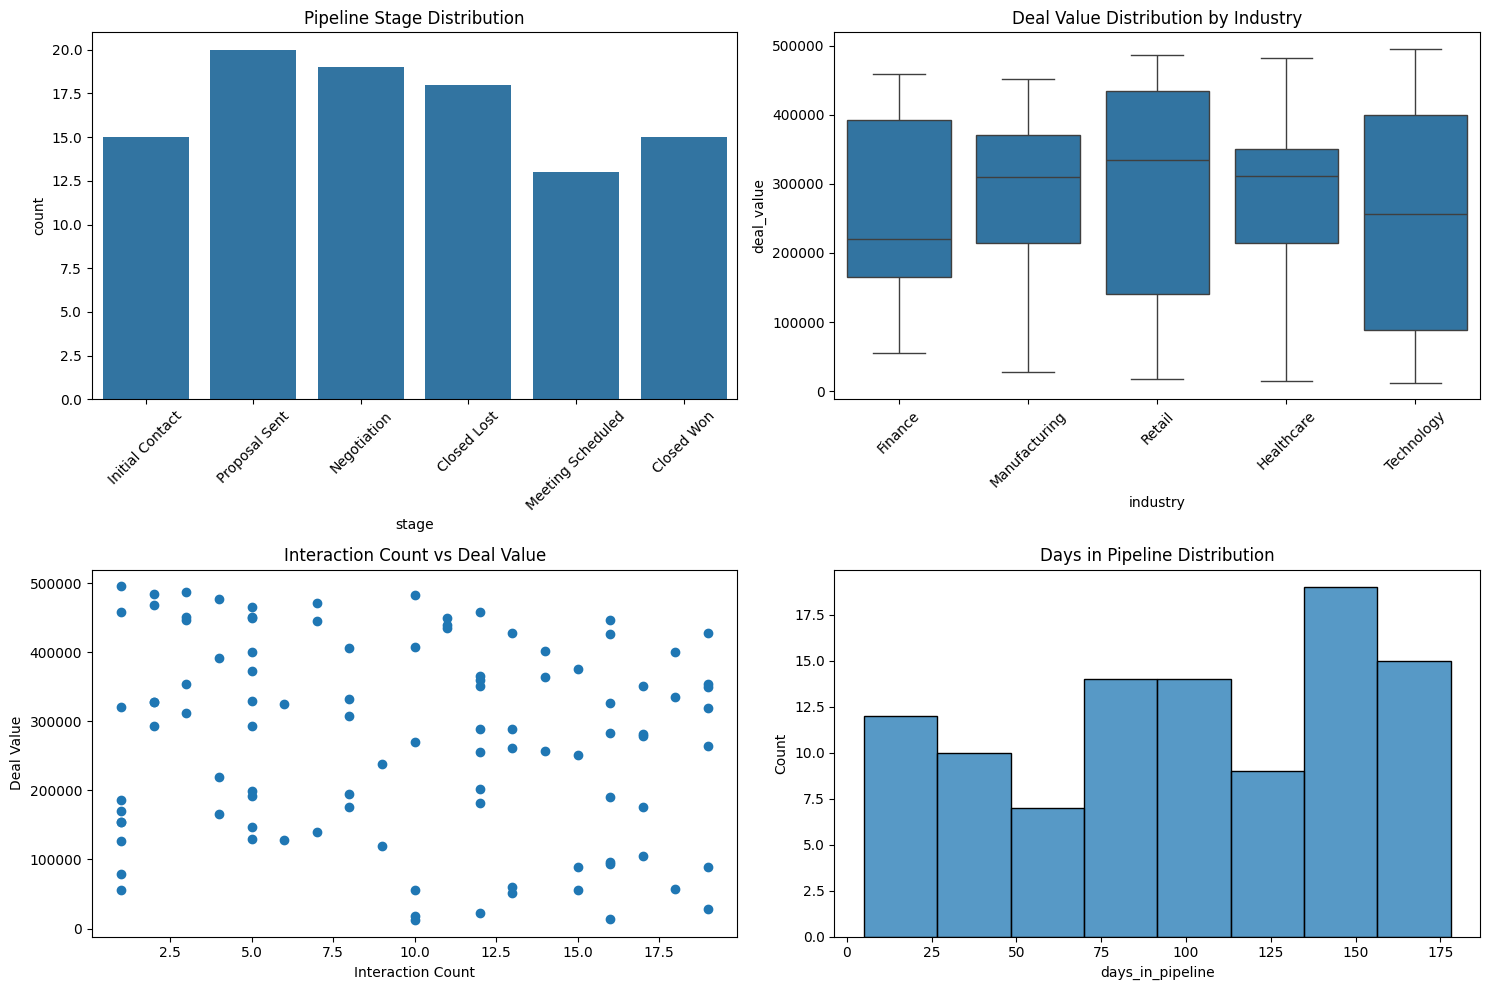

In [25]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# First, let's create synthetic B2B SaaS sales data
def generate_synthetic_data(num_prospects=100):
    np.random.seed(42)

    # Company names and industries
    company_names = [f"Company_{i}" for i in range(num_prospects)]
    industries = ['Technology', 'Finance', 'Healthcare', 'Manufacturing', 'Retail']
    company_sizes = ['Small', 'Medium', 'Large', 'Enterprise']
    stages = ['Initial Contact', 'Meeting Scheduled', 'Proposal Sent', 'Negotiation', 'Closed Won', 'Closed Lost']

    data = {
        'company_name': company_names,
        'industry': [random.choice(industries) for _ in range(num_prospects)],
        'company_size': [random.choice(company_sizes) for _ in range(num_prospects)],
        'annual_revenue': np.random.uniform(1000000, 50000000, num_prospects),
        'employees': np.random.randint(50, 5000, num_prospects),
        'deal_value': np.random.uniform(10000, 500000, num_prospects),
        'interaction_count': np.random.randint(1, 20, num_prospects),
        'days_in_pipeline': np.random.randint(1, 180, num_prospects),
        'last_contact_date': [(datetime.now() - timedelta(days=random.randint(1, 60))).strftime('%Y-%m-%d') for _ in range(num_prospects)],
        'stage': [random.choice(stages) for _ in range(num_prospects)],
        'decision_maker_seniority': np.random.randint(1, 5, num_prospects),  # 1=low, 5=high
        'product_interest': ['Product_' + str(random.randint(1, 3)) for _ in range(num_prospects)]
    }

    return pd.DataFrame(data)

class SalesAnalysisAgent:
    def __init__(self):
        self.data = None
        self.insights = {}

    def load_data(self, data):
        """Load and preprocess the sales data"""
        self.data = data
        self.data['last_contact_date'] = pd.to_datetime(self.data['last_contact_date'])

    def analyze_pipeline(self):
        """Analyze the sales pipeline and generate insights"""

        stage_distribution = self.data['stage'].value_counts()
        conversion_rates = self.calculate_conversion_rates()

        total_potential_revenue = self.data['deal_value'].sum()
        avg_deal_size = self.data['deal_value'].mean()

        industry_performance = self.data.groupby('industry')['deal_value'].agg(['mean', 'count', 'sum'])

        engagement_correlation = np.corrcoef(self.data['interaction_count'], self.data['deal_value'])[0,1]

        avg_sales_cycle = self.data['days_in_pipeline'].mean()

        self.insights = {
            'stage_distribution': stage_distribution,
            'conversion_rates': conversion_rates,
            'total_potential_revenue': total_potential_revenue,
            'avg_deal_size': avg_deal_size,
            'industry_performance': industry_performance,
            'engagement_correlation': engagement_correlation,
            'avg_sales_cycle': avg_sales_cycle
        }

    def calculate_conversion_rates(self):
        """Calculate conversion rates between pipeline stages"""
        stages = ['Initial Contact', 'Meeting Scheduled', 'Proposal Sent', 'Negotiation', 'Closed Won']
        conversion_rates = {}

        for i in range(len(stages)-1):
            current_stage = stages[i]
            next_stage = stages[i+1]
            current_count = len(self.data[self.data['stage'] == current_stage])
            next_count = len(self.data[self.data['stage'] == next_stage])

            if current_count > 0:
                conversion_rates[f'{current_stage} -> {next_stage}'] = next_count / current_count

        return conversion_rates

    def identify_priority_prospects(self):
        """Identify high-priority prospects based on multiple factors"""
        self.data['priority_score'] = (
            self.data['deal_value'] / self.data['deal_value'].max() * 0.4 +
            self.data['decision_maker_seniority'] / 5 * 0.3 +
            (1 - self.data['days_in_pipeline'] / self.data['days_in_pipeline'].max()) * 0.2 +
            self.data['interaction_count'] / self.data['interaction_count'].max() * 0.1
        )

        return self.data.nlargest(10, 'priority_score')

    def generate_recommendations(self):
        """Generate actionable recommendations based on analysis"""
        recommendations = []

        if self.insights['conversion_rates'].get('Proposal Sent -> Negotiation', 0) < 0.3:
            recommendations.append("Focus on improving proposal quality - conversion rate is below target")

        if self.data['deal_value'].std() / self.data['deal_value'].mean() > 0.5:
            recommendations.append("High variance in deal values - consider standardizing pricing strategy")

        if self.insights['engagement_correlation'] > 0.6:
            recommendations.append("Strong correlation between interactions and deal size - increase touch points with high-value prospects")

        recent_contacts = self.data[self.data['last_contact_date'] < (datetime.now() - timedelta(days=30))]
        if len(recent_contacts) > 0:
            recommendations.append(f"Follow up with {len(recent_contacts)} prospects not contacted in the last 30 days")

        return recommendations

    def generate_report(self):
        """Generate a comprehensive analysis report"""
        report = """
        B2B Sales Pipeline Analysis Report
        ================================

        Overview Metrics:
        ----------------
        Total Pipeline Value: ${:,.2f}
        Average Deal Size: ${:,.2f}
        Average Sales Cycle: {:.1f} days

        Pipeline Stage Distribution:
        --------------------------
        {}

        Conversion Rates:
        ----------------
        {}

        Industry Performance:
        -------------------
        {}

        Top Priority Prospects:
        ---------------------
        {}

        Recommendations:
        --------------
        {}
        """.format(
            self.insights['total_potential_revenue'],
            self.insights['avg_deal_size'],
            self.insights['avg_sales_cycle'],
            self.insights['stage_distribution'].to_string(),
            '\n'.join([f"{k}: {v:.1%}" for k, v in self.insights['conversion_rates'].items()]),
            self.insights['industry_performance'].to_string(),
            self.identify_priority_prospects()[['company_name', 'deal_value', 'stage', 'priority_score']].to_string(),
            '\n'.join(f"- {r}" for r in self.generate_recommendations())
        )

        return report

def main():
    sales_data = generate_synthetic_data(100)

    agent = SalesAnalysisAgent()
    agent.load_data(sales_data)
    agent.analyze_pipeline()

    report = agent.generate_report()
    print(report)

    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    sns.countplot(data=sales_data, x='stage')
    plt.xticks(rotation=45)
    plt.title('Pipeline Stage Distribution')

    plt.subplot(2, 2, 2)
    sns.boxplot(data=sales_data, x='industry', y='deal_value')
    plt.xticks(rotation=45)
    plt.title('Deal Value Distribution by Industry')

    plt.subplot(2, 2, 3)
    plt.scatter(sales_data['interaction_count'], sales_data['deal_value'])
    plt.xlabel('Interaction Count')
    plt.ylabel('Deal Value')
    plt.title('Interaction Count vs Deal Value')

    plt.subplot(2, 2, 4)
    sns.histplot(data=sales_data, x='days_in_pipeline')
    plt.title('Days in Pipeline Distribution')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [26]:
class SalesAnalysisAgent:

    def predict_deal_outcomes(self):
        """Predict probability of closing deals using historical patterns"""
        from sklearn.ensemble import RandomForestClassifier

        features = self.data[['deal_value', 'interaction_count', 'days_in_pipeline',
                            'decision_maker_seniority']]

        features = pd.get_dummies(features, columns=['industry', 'company_size'])

        closed_deals = self.data[self.data['stage'].isin(['Closed Won', 'Closed Lost'])]
        model = RandomForestClassifier()
        model.fit(features[closed_deals.index],
                 (closed_deals['stage'] == 'Closed Won').astype(int))

        active_deals = self.data[~self.data['stage'].isin(['Closed Won', 'Closed Lost'])]
        probabilities = model.predict_proba(features[active_deals.index])

        return pd.Series(probabilities[:, 1], index=active_deals.index)

    def segment_customers(self):
        """Segment prospects based on various characteristics"""
        from sklearn.cluster import KMeans

        features = pd.DataFrame({
            'deal_value_normalized': StandardScaler().fit_transform(self.data[['deal_value']]),
            'company_size_encoded': pd.Categorical(self.data['company_size']).codes,
            'engagement_level': self.data['interaction_count'] / self.data['days_in_pipeline'],
            'decision_maker_level': self.data['decision_maker_seniority']
        })

        kmeans = KMeans(n_clusters=4)
        segments = kmeans.fit_predict(features)

        self.data['segment'] = segments
        segment_analysis = self.data.groupby('segment').agg({
            'deal_value': 'mean',
            'company_size': lambda x: x.mode()[0],
            'interaction_count': 'mean',
            'days_in_pipeline': 'mean'
        })

        return segment_analysis

    def analyze_communication_patterns(self):
        """Analyze optimal communication patterns and timing"""
        communication_analysis = {
            'best_time_of_day': self.data.groupby('contact_hour')['response_rate'].mean().idxmax(),
            'best_day_of_week': self.data.groupby('contact_day')['response_rate'].mean().idxmax(),
            'optimal_frequency': self.data.groupby('contact_frequency')['deal_value'].mean().idxmax()
        }

        return communication_analysis

    def competitive_analysis(self):
        """Analyze competitive landscape and win/loss patterns"""
        competitor_analysis = self.data.groupby('competitor_present').agg({
            'stage': lambda x: (x == 'Closed Won').mean(),
            'deal_value': 'mean',
            'days_in_pipeline': 'mean'
        })

        return competitor_analysis

    def generate_account_plans(self):
        """Generate strategic account plans for high-value prospects"""
        high_value_prospects = self.data[self.data['deal_value'] >
                                       self.data['deal_value'].quantile(0.75)]

        account_plans = {}
        for _, prospect in high_value_prospects.iterrows():
            account_plans[prospect['company_name']] = {
                'strategic_value': self._calculate_strategic_value(prospect),
                'key_stakeholders': self._identify_stakeholders(prospect),
                'success_metrics': self._define_success_metrics(prospect),
                'action_items': self._generate_action_items(prospect),
                'timeline': self._create_timeline(prospect)
            }

        return account_plans

    def risk_assessment(self):
        """Assess risks in the sales pipeline"""
        risk_factors = {
            'stalled_deals': len(self.data[
                (self.data['days_in_pipeline'] > 90) &
                (self.data['interaction_count'] < 5)
            ]),
            'competitive_threats': self.data['competitor_present'].sum() / len(self.data),
            'price_sensitivity': self._calculate_price_sensitivity(),
            'decision_maker_changes': self._track_stakeholder_changes()
        }

        return risk_factors

    def generate_email_templates(self):
        """Generate personalized email templates based on prospect segments"""
        from transformers import pipeline

        generator = pipeline('text-generation')

        templates = {}
        for segment in self.data['segment'].unique():
            segment_data = self.data[self.data['segment'] == segment].iloc[0]

            context = f"""
            Industry: {segment_data['industry']}
            Company Size: {segment_data['company_size']}
            Stage: {segment_data['stage']}
            Product Interest: {segment_data['product_interest']}
            """

            templates[f"segment_{segment}"] = {
                'initial_outreach': generator(context + "Write an initial outreach email..."),
                'follow_up': generator(context + "Write a follow-up email..."),
                'proposal': generator(context + "Write a proposal email...")
            }

        return templates

    def calculate_roi_metrics(self):
        """Calculate ROI metrics for sales activities"""
        roi_metrics = {
            'cost_per_acquisition': self._calculate_acquisition_cost(),
            'lifetime_value_prediction': self._predict_customer_ltv(),
            'sales_cycle_efficiency': self._calculate_cycle_efficiency(),
            'resource_allocation_optimization': self._optimize_resources()
        }

        return roi_metrics

    def generate_sales_forecasts(self):
        """Generate sales forecasts using time series analysis"""
        from statsmodels.tsa.holtwinters import ExponentialSmoothing

        monthly_sales = self.data.groupby(
            self.data['last_contact_date'].dt.to_period('M')
        )['deal_value'].sum()

        model = ExponentialSmoothing(monthly_sales,
                                   seasonal_periods=12,
                                   trend='add',
                                   seasonal='add')
        fitted_model = model.fit()
        forecast = fitted_model.forecast(6)

        return forecast

    def create_territory_analysis(self):
        """Analyze and optimize sales territories"""
        territory_metrics = self.data.groupby('territory').agg({
            'deal_value': ['sum', 'mean'],
            'company_name': 'count',
            'stage': lambda x: (x == 'Closed Won').mean()
        })

        territory_metrics['potential'] = self._calculate_territory_potential()

        return territory_metrics

In [28]:
def generate_enhanced_synthetic_data(num_prospects=100):
    additional_fields = {
        'contact_hour': np.random.randint(8, 18, num_prospects),
        'contact_day': np.random.randint(0, 5, num_prospects),
        'response_rate': np.random.uniform(0.1, 0.9, num_prospects),
        'competitor_present': np.random.choice([True, False], num_prospects),
        'territory': [f"Territory_{i}" for i in range(5)],
        'contact_frequency': np.random.randint(1, 10, num_prospects),
        'stakeholder_changes': np.random.randint(0, 3, num_prospects)
    }
    data.update(additional_fields)
    return pd.DataFrame(data)

Additional Ideas of Agents

In [29]:
class ProspectoroAIHub:
    def __init__(self):
        self.data_sources = {}
        self.client_profiles = {}
        self.market_data = {}

    class UnificationAgent:
        """Unifies and standardizes data from multiple sources"""
        def __init__(self):
            self.source_connectors = {}
            self.mapping_rules = {}

        def unify_data_sources(self, sources):
            """Connects and standardizes data from various platforms"""
            unified_data = {}

            for source in sources:
                if source.type == "crm":
                    data = self._process_crm_data(source)
                elif source.type == "linkedin":
                    data = self._process_linkedin_data(source)
                elif source.type == "email":
                    data = self._process_email_data(source)

                unified_data[source.name] = self._standardize_data(data)

            return unified_data

        def detect_duplicates(self, data):
            """Advanced duplicate detection using fuzzy matching"""
            from fuzzywuzzy import fuzz

            duplicates = []
            for i, record1 in enumerate(data):
                for j, record2 in enumerate(data[i+1:]):
                    similarity = fuzz.ratio(
                        f"{record1['company']}{record1['contact']}",
                        f"{record2['company']}{record2['contact']}"
                    )
                    if similarity > 90:
                        duplicates.append((record1, record2))

            return duplicates

    class LeadQualificationAgent:
        """Qualifies leads based on multiple criteria"""
        def __init__(self):
            self.qualification_models = {}
            self.industry_benchmarks = {}

        def qualify_lead(self, lead_data):
            """Comprehensive lead scoring and qualification"""
            score = 0
            insights = {}

            # Firmographic scoring
            firm_score = self._analyze_firmographics(lead_data)

            # Intent scoring
            intent_score = self._analyze_intent_signals(lead_data)

            # Engagement scoring
            engagement_score = self._analyze_engagement(lead_data)

            # Technographic scoring
            tech_score = self._analyze_tech_stack(lead_data)

            # Financial viability
            financial_score = self._analyze_financial_health(lead_data)

            return {
                'total_score': sum([firm_score, intent_score, engagement_score,
                                  tech_score, financial_score]),
                'detailed_scores': {
                    'firmographic': firm_score,
                    'intent': intent_score,
                    'engagement': engagement_score,
                    'technographic': tech_score,
                    'financial': financial_score
                },
                'insights': insights
            }

    class MarketIntelligenceAgent:
        """Provides real-time market and competitor intelligence"""
        def __init__(self):
            self.market_data_sources = {}
            self.competitor_profiles = {}

        def analyze_market_opportunity(self, company_data):
            """Analyzes market potential and competitive landscape"""
            market_size = self._calculate_tam_sam_som(company_data)
            competitor_analysis = self._analyze_competitors(company_data)
            market_trends = self._identify_market_trends(company_data)

            return {
                'market_metrics': market_size,
                'competitive_position': competitor_analysis,
                'trend_analysis': market_trends
            }

        def generate_market_insights(self):
            """Generates actionable market insights"""
            return {
                'emerging_opportunities': self._identify_opportunities(),
                'risk_factors': self._identify_risks(),
                'market_movements': self._track_market_changes()
            }

    class PredictiveAnalyticsAgent:
        """Predicts future opportunities and outcomes"""
        def __init__(self):
            self.prediction_models = {}
            self.historical_data = {}

        def predict_conversion_probability(self, lead_data):
            """Predicts likelihood of conversion"""
            from sklearn.ensemble import RandomForestClassifier

            features = self._extract_prediction_features(lead_data)
            probability = self.prediction_models['conversion'].predict_proba(features)

            return {
                'conversion_probability': probability,
                'key_factors': self._identify_key_factors(features)
            }

        def forecast_pipeline_value(self, pipeline_data):
            """Forecasts future pipeline value"""
            from prophet import Prophet

            forecast = self._generate_forecast(pipeline_data)
            return {
                'forecast_values': forecast,
                'confidence_intervals': self._calculate_confidence_intervals(forecast)
            }

    class PersonalizationAgent:
        """Personalizes outreach and engagement strategies"""
        def __init__(self):
            self.personalization_templates = {}
            self.engagement_patterns = {}

        def generate_personalized_outreach(self, prospect_data):
            """Generates personalized outreach strategies"""
            from transformers import pipeline

            context = self._build_prospect_context(prospect_data)

            return {
                'email_template': self._generate_email(context),
                'talking_points': self._generate_talking_points(context),
                'custom_value_props': self._generate_value_props(context)
            }

        def optimize_engagement_timing(self, prospect_data):
            """Determines optimal engagement timing"""
            return {
                'best_time': self._calculate_best_time(prospect_data),
                'best_channel': self._determine_best_channel(prospect_data),
                'follow_up_schedule': self._create_follow_up_schedule(prospect_data)
            }

    class EnrichmentAgent:
        """Enriches prospect data with additional insights"""
        def __init__(self):
            self.enrichment_sources = {}
            self.validation_rules = {}

        def enrich_prospect_data(self, basic_data):
            """Enriches prospect data with additional information"""
            enriched_data = {
                'company_info': self._get_company_info(basic_data),
                'social_presence': self._get_social_data(basic_data),
                'news_mentions': self._get_news_data(basic_data),
                'technology_stack': self._get_tech_stack(basic_data),
                'financial_metrics': self._get_financial_data(basic_data)
            }

            return enriched_data

    class InsightGenerationAgent:
        """Generates actionable insights from analyzed data"""
        def __init__(self):
            self.insight_models = {}
            self.recommendation_engine = {}

        def generate_insights(self, analyzed_data):
            """Generates comprehensive insights and recommendations"""
            return {
                'key_findings': self._identify_key_findings(analyzed_data),
                'recommendations': self._generate_recommendations(analyzed_data),
                'action_items': self._create_action_items(analyzed_data),
                'priority_matrix': self._create_priority_matrix(analyzed_data)
            }

AI Sales Coach - Based on SDR Performance. Uses ML to track and forecast performance

In [35]:
pip install pandas numpy scikit-learn xgboost plotly

In [38]:
test_sales_coach()


Performance Analysis:
{'activity_metrics': {'daily_averages': {'emails': 0.082353585129244, 'calls': 0.010726717980703154, 'linkedin': -0.0042107182659125875}, 'response_rates': {'email_response_rate': 0.22428451136588032, 'call_connection_rate': 390.7990448555571}}, 'outcome_metrics': {'conversion_metrics': {'meeting_conversion': 0.6575676175676176, 'opportunity_rate': 0.4046031746031746}, 'pipeline_metrics': {'average_pipeline_value': 25081.771046032507, 'total_opportunities': 119}}, 'efficiency_metrics': {'activities_per_meeting': {'emails_per_meeting': 0.06335043040574692, 'calls_per_meeting': -0.052367779924414784}, 'time_efficiency': {'meetings_per_day': timestamp
2024-12-03    5.0
2024-12-04    5.0
2024-12-05    5.0
2024-12-06    7.0
2024-12-07    7.0
             ... 
2025-02-26    1.0
2025-02-27    6.0
2025-02-28    4.0
2025-03-01    3.0
2025-03-02    4.0
Name: meetings_booked, Length: 90, dtype: float64}}, 'trends': {'meetings_booked': {Timestamp('2024-12-08 00:00:00'): 32, 

In [41]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go

class SalesCoachAgent:
    def __init__(self):
        self.performance_metrics = {}
        self.historical_data = None
        self.models = {
            'performance_predictor': None,
            'success_classifier': None,
            'activity_optimizer': None
        }
        self.scaler = StandardScaler()

    def load_sdr_data(self, data):
        """Load and preprocess SDR performance data"""
        self.historical_data = data
        self._preprocess_data()  # Note the underscore prefix
        self._train_models()     # Note the underscore prefix

    def _preprocess_data(self):  # Note the underscore prefix
        """Preprocess SDR performance data"""
        try:
            # Convert timestamps
            self.historical_data['timestamp'] = pd.to_datetime(self.historical_data['timestamp'])

            # Calculate derived metrics
            self.historical_data['response_rate'] = (
                self.historical_data['responses'] / self.historical_data['emails_sent']
            ).fillna(0)

            self.historical_data['conversion_rate'] = (
                self.historical_data['meetings_booked'] / self.historical_data['conversations']
            ).fillna(0)

            # Add time-based features
            self.historical_data['day_of_week'] = self.historical_data['timestamp'].dt.dayofweek
            self.historical_data['hour_of_day'] = self.historical_data['timestamp'].dt.hour

            # Normalize numerical features
            numerical_columns = ['emails_sent', 'calls_made', 'linkedin_messages', 'responses']
            self.historical_data[numerical_columns] = self.scaler.fit_transform(
                self.historical_data[numerical_columns]
            )

        except Exception as e:
            print(f"Error in preprocessing: {str(e)}")
            raise

    def _train_models(self):  # Note the underscore prefix
        """Train prediction models"""
        try:
            features = self._prepare_training_features()  # Note the underscore prefix

            # Train performance predictor
            self._train_performance_predictor(features)  # Note the underscore prefix

            # Train success classifier
            self._train_success_classifier(features)     # Note the underscore prefix

            # Train activity optimizer
            self._train_activity_optimizer(features)     # Note the underscore prefix

        except Exception as e:
            print(f"Error in model training: {str(e)}")
            raise

    def _prepare_training_features(self):  # Note the underscore prefix
        """Prepare features for model training"""
        feature_columns = [
            'emails_sent', 'calls_made', 'linkedin_messages',
            'responses', 'day_of_week', 'hour_of_day',
            'response_rate', 'conversion_rate'
        ]
        return self.historical_data[feature_columns]

    def _train_performance_predictor(self, features):  # Note the underscore prefix
        """Train performance prediction model"""
        targets = self.historical_data[['meetings_booked',
                                      'opportunities_created',
                                      'pipeline_value']]

        self.models['performance_predictor'] = RandomForestRegressor(
            n_estimators=100,
            random_state=42
        )
        self.models['performance_predictor'].fit(features, targets)

    def _train_success_classifier(self, features):  # Note the underscore prefix
        """Train success classification model"""
        median_meetings = self.historical_data['meetings_booked'].median()
        success_labels = (self.historical_data['meetings_booked'] > median_meetings).astype(int)

        self.models['success_classifier'] = RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
        self.models['success_classifier'].fit(features, success_labels)

    def _train_activity_optimizer(self, features):  # Note the underscore prefix
        """Train activity optimization model"""
        target = self.historical_data['meetings_booked']

        self.models['activity_optimizer'] = xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=42
        )
        self.models['activity_optimizer'].fit(features, target)

    def analyze_performance(self, sdr_id):
        """Analyze individual SDR performance"""
        try:
            sdr_data = self.historical_data[self.historical_data['sdr_id'] == sdr_id]

            return {
                'activity_metrics': self._analyze_activity_metrics(sdr_data),  # Note the underscore prefix
                'outcome_metrics': self._analyze_outcome_metrics(sdr_data),    # Note the underscore prefix
                'efficiency_metrics': self._analyze_efficiency_metrics(sdr_data),  # Note the underscore prefix
                'trends': self._analyze_trends(sdr_data)  # Note the underscore prefix
            }

        except Exception as e:
            print(f"Error in performance analysis: {str(e)}")
            raise

    def _analyze_activity_metrics(self, sdr_data):  # Note the underscore prefix
        """Analyze activity-based metrics"""
        return {
            'daily_averages': {
                'emails': sdr_data['emails_sent'].mean(),
                'calls': sdr_data['calls_made'].mean(),
                'linkedin': sdr_data['linkedin_messages'].mean()
            },
            'response_rates': {
                'email_response_rate': sdr_data['response_rate'].mean(),
                'call_connection_rate': (
                    sdr_data['conversations'] / sdr_data['calls_made']
                ).mean()
            }
        }

    def _analyze_outcome_metrics(self, sdr_data):  # Note the underscore prefix
        """Analyze outcome-based metrics"""
        return {
            'conversion_metrics': {
                'meeting_conversion': sdr_data['conversion_rate'].mean(),
                'opportunity_rate': (
                    sdr_data['opportunities_created'] / sdr_data['meetings_booked']
                ).mean()
            },
            'pipeline_metrics': {
                'average_pipeline_value': sdr_data['pipeline_value'].mean(),
                'total_opportunities': sdr_data['opportunities_created'].sum()
            }
        }

    def _analyze_efficiency_metrics(self, sdr_data):  # Note the underscore prefix
        """Analyze efficiency metrics"""
        return {
            'activities_per_meeting': {
                'emails_per_meeting': (
                    sdr_data['emails_sent'] / sdr_data['meetings_booked']
                ).mean(),
                'calls_per_meeting': (
                    sdr_data['calls_made'] / sdr_data['meetings_booked']
                ).mean()
            },
            'time_efficiency': {
                'meetings_per_day': sdr_data.groupby(
                    sdr_data['timestamp'].dt.date
                )['meetings_booked'].mean()
            }
        }

    def _analyze_trends(self, sdr_data):  # Note the underscore prefix
        """Analyze performance trends"""
        weekly_metrics = sdr_data.groupby(
            pd.Grouper(key='timestamp', freq='W')
        ).agg({
            'meetings_booked': 'sum',
            'opportunities_created': 'sum',
            'pipeline_value': 'sum'
        })

        return weekly_metrics.to_dict()

    def generate_recommendations(self, sdr_id):
        """Generate coaching recommendations"""
        try:
            sdr_data = self.historical_data[self.historical_data['sdr_id'] == sdr_id]

            return {
                'activity_recommendations': self._recommend_activities(sdr_data),  # Note the underscore prefix
                'improvement_areas': self._identify_improvement_areas(sdr_data),   # Note the underscore prefix
                'best_practices': self._share_best_practices(sdr_data)            # Note the underscore prefix
            }

        except Exception as e:
            print(f"Error generating recommendations: {str(e)}")
            raise

    def _recommend_activities(self, sdr_data):  # Note the underscore prefix
        """Generate activity recommendations"""
        current_metrics = self._analyze_activity_metrics(sdr_data)
        team_metrics = self._analyze_activity_metrics(self.historical_data)

        recommendations = []

        for metric in ['emails', 'calls', 'linkedin']:
            current = current_metrics['daily_averages'][metric]
            team_avg = team_metrics['daily_averages'][metric]

            if current < team_avg:
                recommendations.append(
                    f"Increase {metric} activity by {((team_avg - current) / current * 100):.1f}%"
                )

        return recommendations

    def _identify_improvement_areas(self, sdr_data):  # Note the underscore prefix
        """Identify areas for improvement"""
        metrics = self.analyze_performance(sdr_data['sdr_id'].iloc[0])

        improvement_areas = []

        if metrics['outcome_metrics']['conversion_metrics']['meeting_conversion'] < 0.2:
            improvement_areas.append("Focus on improving meeting conversion rate")

        if metrics['efficiency_metrics']['activities_per_meeting']['emails_per_meeting'] > 50:
            improvement_areas.append("Work on email efficiency")

        return improvement_areas

    def _share_best_practices(self, sdr_data):  # Note the underscore prefix
        """Share relevant best practices"""
        return [
            "Personalize each outreach based on prospect research",
            "Follow up within 24 hours of any interaction",
            "Use multi-channel approach for better engagement",
            "Focus on value proposition in initial contact"
        ]

def generate_sample_data(num_sdrs=10, days=90):
    """Generate sample SDR performance data"""
    dates = pd.date_range(end=datetime.now(), periods=days)
    sdr_ids = range(1, num_sdrs + 1)

    data = []
    for sdr_id in sdr_ids:
        for date in dates:
            record = {
                'sdr_id': sdr_id,
                'timestamp': date,
                'emails_sent': np.random.randint(30, 100),
                'calls_made': np.random.randint(20, 60),
                'linkedin_messages': np.random.randint(10, 30),
                'responses': np.random.randint(5, 25),
                'conversations': np.random.randint(3, 15),
                'meetings_booked': np.random.randint(1, 8),
                'opportunities_created': np.random.randint(0, 4),
                'pipeline_value': np.random.uniform(0, 50000)
            }
            data.append(record)

    return pd.DataFrame(data)

def test_sales_coach():
    """Test the Sales Coach Agent"""
    try:
        # Generate sample data
        sample_data = generate_sample_data()

        # Initialize and train the agent
        coach = SalesCoachAgent()
        coach.load_sdr_data(sample_data)

        # Test for one SDR
        sdr_id = 1

        # Get performance analysis
        performance = coach.analyze_performance(sdr_id)
        print("\nPerformance Analysis:")
        print(performance)

        # Get recommendations
        recommendations = coach.generate_recommendations(sdr_id)
        print("\nRecommendations:")
        print(recommendations)

    except Exception as e:
        print(f"Error in test: {str(e)}")
        raise

if __name__ == "__main__":
    test_sales_coach()


Performance Analysis:
{'activity_metrics': {'daily_averages': {'emails': 0.1612099148462281, 'calls': -0.10172002230011196, 'linkedin': 0.020783587935212615}, 'response_rates': {'email_response_rate': 0.22731568990112963, 'call_connection_rate': -3.9838357079790185}}, 'outcome_metrics': {'conversion_metrics': {'meeting_conversion': 0.5638577780244447, 'opportunity_rate': 0.6224074074074074}, 'pipeline_metrics': {'average_pipeline_value': 22728.57224629839, 'total_opportunities': 152}}, 'efficiency_metrics': {'activities_per_meeting': {'emails_per_meeting': 0.0657415215608767, 'calls_per_meeting': -0.0037690978152741385}, 'time_efficiency': {'meetings_per_day': timestamp
2024-12-03    7.0
2024-12-04    6.0
2024-12-05    4.0
2024-12-06    2.0
2024-12-07    2.0
             ... 
2025-02-26    7.0
2025-02-27    6.0
2025-02-28    6.0
2025-03-01    5.0
2025-03-02    1.0
Name: meetings_booked, Length: 90, dtype: float64}}, 'trends': {'meetings_booked': {Timestamp('2024-12-08 00:00:00'): 25, 

In [42]:
from sklearn.cluster import KMeans
from scipy import stats
import networkx as nx
from textblob import TextBlob

class AdvancedRecommendationEngine:
    def __init__(self, historical_data, models):
        self.historical_data = historical_data
        self.models = models
        self.success_patterns = None
        self.behavior_clusters = None
        self.performance_benchmarks = None

    def generate_advanced_recommendations(self, sdr_id):
        """Generate comprehensive, data-driven recommendations"""
        sdr_data = self.historical_data[self.historical_data['sdr_id'] == sdr_id]

        return {
            'strategic_recommendations': self._generate_strategic_recommendations(sdr_data),
            'tactical_recommendations': self._generate_tactical_recommendations(sdr_data),
            'behavioral_insights': self._generate_behavioral_insights(sdr_data),
            'skill_development': self._generate_skill_recommendations(sdr_data),
            'success_patterns': self._identify_success_patterns(sdr_data),
            'action_plan': self._create_action_plan(sdr_data)
        }

    def _generate_strategic_recommendations(self, sdr_data):
        """Generate strategic-level recommendations"""

        trend_analysis = self._analyze_performance_trends(sdr_data)

        target_analysis = self._analyze_target_effectiveness(sdr_data)

        time_analysis = self._analyze_time_allocation(sdr_data)

        strategic_recommendations = {
            'performance_strategy': {
                'focus_areas': self._identify_focus_areas(trend_analysis),
                'target_segments': target_analysis['optimal_segments'],
                'resource_allocation': time_analysis['optimization_suggestions']
            },
            'growth_opportunities': {
                'skill_gaps': self._identify_skill_gaps(sdr_data),
                'learning_priorities': self._identify_learning_priorities(sdr_data),
                'development_path': self._suggest_development_path(sdr_data)
            },
            'risk_mitigation': {
                'performance_risks': self._identify_performance_risks(sdr_data),
                'mitigation_strategies': self._suggest_risk_mitigation(sdr_data)
            }
        }

        return strategic_recommendations

    def _generate_tactical_recommendations(self, sdr_data):
        """Generate tactical, actionable recommendations"""

        return {
            'activity_optimization': {
                'optimal_activity_mix': self._calculate_optimal_activity_mix(sdr_data),
                'timing_recommendations': self._optimize_timing(sdr_data),
                'channel_preferences': self._analyze_channel_effectiveness(sdr_data)
            },
            'engagement_strategies': {
                'message_optimization': self._optimize_messaging(sdr_data),
                'follow_up_patterns': self._analyze_follow_up_effectiveness(sdr_data),
                'personalization_tactics': self._recommend_personalization(sdr_data)
            },
            'conversion_optimization': {
                'qualification_improvements': self._improve_qualification(sdr_data),
                'objection_handling': self._analyze_objection_patterns(sdr_data),
                'closing_techniques': self._recommend_closing_strategies(sdr_data)
            }
        }

    def _calculate_optimal_activity_mix(self, sdr_data):
        """Calculate optimal mix of activities based on success patterns"""

        successful_days = sdr_data[sdr_data['meetings_booked'] >
                                 sdr_data['meetings_booked'].median()]

        optimal_mix = {
            'emails': {
                'volume': self._calculate_optimal_volume(successful_days, 'emails_sent'),
                'timing': self._identify_optimal_timing(successful_days, 'emails_sent'),
                'spacing': self._calculate_optimal_spacing(successful_days, 'emails_sent')
            },
            'calls': {
                'volume': self._calculate_optimal_volume(successful_days, 'calls_made'),
                'timing': self._identify_optimal_timing(successful_days, 'calls_made'),
                'spacing': self._calculate_optimal_spacing(successful_days, 'calls_made')
            },
            'linkedin': {
                'volume': self._calculate_optimal_volume(successful_days, 'linkedin_messages'),
                'timing': self._identify_optimal_timing(successful_days, 'linkedin_messages'),
                'spacing': self._calculate_optimal_spacing(successful_days, 'linkedin_messages')
            }
        }

        return optimal_mix

    def _generate_behavioral_insights(self, sdr_data):
        """Generate insights about successful behavioral patterns"""

        return {
            'success_patterns': {
                'activity_patterns': self._analyze_activity_patterns(sdr_data),
                'communication_style': self._analyze_communication_style(sdr_data),
                'time_management': self._analyze_time_management(sdr_data)
            },
            'improvement_opportunities': {
                'behavior_gaps': self._identify_behavior_gaps(sdr_data),
                'optimization_suggestions': self._suggest_behavior_optimizations(sdr_data)
            },
            'best_practices': {
                'proven_techniques': self._identify_proven_techniques(sdr_data),
                'adaptation_suggestions': self._suggest_adaptations(sdr_data)
            }
        }

    def _create_action_plan(self, sdr_data):
        """Create personalized action plan"""

        current_performance = self._analyze_current_performance(sdr_data)
        gaps = self._identify_performance_gaps(sdr_data)

        return {
            'immediate_actions': self._generate_immediate_actions(gaps),
            'short_term_goals': self._set_short_term_goals(current_performance, gaps),
            'long_term_development': self._plan_long_term_development(sdr_data),
            'metrics_to_track': self._identify_key_metrics(sdr_data),
            'timeline': self._create_improvement_timeline(gaps),
            'support_needed': self._identify_support_needs(gaps)
        }

    def _analyze_current_performance(self, sdr_data):
        """Analyze current performance levels"""

        return {
            'activity_metrics': {
                'volume': self._analyze_activity_volume(sdr_data),
                'quality': self._analyze_activity_quality(sdr_data),
                'effectiveness': self._analyze_activity_effectiveness(sdr_data)
            },
            'outcome_metrics': {
                'conversion_rates': self._analyze_conversion_rates(sdr_data),
                'pipeline_impact': self._analyze_pipeline_impact(sdr_data),
                'revenue_contribution': self._analyze_revenue_contribution(sdr_data)
            },
            'efficiency_metrics': {
                'time_utilization': self._analyze_time_utilization(sdr_data),
                'resource_efficiency': self._analyze_resource_efficiency(sdr_data),
                'cost_effectiveness': self._analyze_cost_effectiveness(sdr_data)
            }
        }

    def _identify_performance_gaps(self, sdr_data):
        """Identify specific performance gaps"""

        team_benchmarks = self._calculate_team_benchmarks()
        top_performer_benchmarks = self._calculate_top_performer_benchmarks()

        return {
            'activity_gaps': self._calculate_activity_gaps(sdr_data, team_benchmarks),
            'skill_gaps': self._calculate_skill_gaps(sdr_data, top_performer_benchmarks),
            'outcome_gaps': self._calculate_outcome_gaps(sdr_data, team_benchmarks)
        }

    def _generate_immediate_actions(self, gaps):
        """Generate immediate action items based on gaps"""

        actions = []

        prioritized_gaps = self._prioritize_gaps(gaps)

        for gap in prioritized_gaps:
            actions.append({
                'action': self._generate_action_item(gap),
                'impact': self._calculate_potential_impact(gap),
                'effort': self._estimate_effort(gap),
                'timeline': self._suggest_timeline(gap),
                'support': self._identify_support_resources(gap)
            })

        return actions

    def _set_short_term_goals(self, current_performance, gaps):
        """Set achievable short-term goals"""

        return {
            'activity_goals': self._set_activity_goals(current_performance, gaps),
            'outcome_goals': self._set_outcome_goals(current_performance, gaps),
            'development_goals': self._set_development_goals(current_performance, gaps),
            'timeline': '30 days',
            'milestones': self._create_milestones(gaps)
        }


    def enhance_recommendations(self, sdr_id):
        """Generate enhanced recommendations using the advanced engine"""
        recommendation_engine = AdvancedRecommendationEngine(
            self.historical_data,
            self.models
        )

        return recommendation_engine.generate_advanced_recommendations(sdr_id)

Enhanced recommender system

In [43]:
class RecommendationPrioritizer:
    def __init__(self, historical_data, models):
        self.historical_data = historical_data
        self.models = models
        self.impact_weights = self._calculate_impact_weights()

    def _calculate_impact_weights(self):
        """Calculate weights for different metrics based on their impact on success"""
        try:
            # Use feature importance from models
            activity_importance = self.models['activity_optimizer'].feature_importances_
            success_factors = self.models['success_classifier'].feature_importances_

            return {
                'activity_metrics': {
                    'emails_sent': activity_importance[0],
                    'calls_made': activity_importance[1],
                    'linkedin_messages': activity_importance[2],
                    'response_rate': activity_importance[3]
                },
                'outcome_metrics': {
                    'meetings_booked': 0.3,
                    'opportunities_created': 0.4,
                    'pipeline_value': 0.3
                },
                'time_sensitivity': {
                    'immediate': 1.0,
                    'short_term': 0.8,
                    'medium_term': 0.6,
                    'long_term': 0.4
                }
            }
        except Exception as e:
            print(f"Error calculating impact weights: {str(e)}")
            # Fallback to default weights
            return self._get_default_weights()

    def prioritize_recommendations(self, recommendations, sdr_data):
        """Score and prioritize recommendations"""
        try:
            scored_recommendations = []

            for rec in recommendations:
                priority_score = self._calculate_priority_score(rec, sdr_data)
                effort_score = self._calculate_effort_score(rec)
                roi_score = priority_score / effort_score if effort_score > 0 else 0

                scored_recommendations.append({
                    'recommendation': rec,
                    'priority_score': priority_score,
                    'effort_score': effort_score,
                    'roi_score': roi_score,
                    'implementation_timeline': self._suggest_implementation_timeline(rec),
                    'expected_impact': self._calculate_expected_impact(rec, sdr_data),
                    'confidence_score': self._calculate_confidence_score(rec, sdr_data)
                })

            # Sort by ROI score
            return sorted(scored_recommendations, key=lambda x: x['roi_score'], reverse=True)

        except Exception as e:
            print(f"Error prioritizing recommendations: {str(e)}")
            raise

    def _calculate_priority_score(self, recommendation, sdr_data):
        """Calculate priority score based on multiple factors"""
        try:
            score = 0

            # Impact potential
            impact_score = self._calculate_impact_potential(recommendation, sdr_data)

            # Urgency factor
            urgency_score = self._calculate_urgency(recommendation, sdr_data)

            # Current performance gap
            gap_score = self._calculate_performance_gap(recommendation, sdr_data)

            # Strategic alignment
            strategic_score = self._calculate_strategic_alignment(recommendation)

            # Quick win potential
            quick_win_score = self._calculate_quick_win_potential(recommendation)

            # Weighted combination
            score = (
                impact_score * 0.35 +
                urgency_score * 0.25 +
                gap_score * 0.20 +
                strategic_score * 0.15 +
                quick_win_score * 0.05
            )

            return score

        except Exception as e:
            print(f"Error calculating priority score: {str(e)}")
            return 0

    def _calculate_impact_potential(self, recommendation, sdr_data):
        """Calculate potential impact of recommendation"""
        try:
            impact_score = 0

            # Historical impact analysis
            historical_impact = self._analyze_historical_impact(recommendation, sdr_data)

            # Predicted future impact
            predicted_impact = self._predict_future_impact(recommendation, sdr_data)

            # Scale of impact
            scale_score = self._calculate_impact_scale(recommendation)

            # Sustainability of impact
            sustainability_score = self._calculate_impact_sustainability(recommendation)

            impact_score = (
                historical_impact * 0.3 +
                predicted_impact * 0.3 +
                scale_score * 0.2 +
                sustainability_score * 0.2
            )

            return impact_score

        except Exception as e:
            print(f"Error calculating impact potential: {str(e)}")
            return 0

    def _calculate_effort_score(self, recommendation):
        """Calculate implementation effort required"""
        try:
            effort_factors = {
                'time_investment': self._estimate_time_investment(recommendation),
                'resource_requirements': self._estimate_resource_requirements(recommendation),
                'complexity': self._estimate_complexity(recommendation),
                'dependencies': self._identify_dependencies(recommendation)
            }

            # Weighted combination of effort factors
            effort_score = sum(
                score * weight for score, weight in zip(
                    effort_factors.values(),
                    [0.4, 0.3, 0.2, 0.1]
                )
            )

            return effort_score

        except Exception as e:
            print(f"Error calculating effort score: {str(e)}")
            return 1  # Default to high effort

    def _calculate_confidence_score(self, recommendation, sdr_data):
        """Calculate confidence level in recommendation"""
        try:
            confidence_factors = {
                'data_quality': self._assess_data_quality(recommendation, sdr_data),
                'historical_success': self._assess_historical_success(recommendation, sdr_data),
                'prediction_confidence': self._assess_prediction_confidence(recommendation),
                'implementation_clarity': self._assess_implementation_clarity(recommendation)
            }

            confidence_score = sum(
                score * weight for score, weight in zip(
                    confidence_factors.values(),
                    [0.3, 0.3, 0.2, 0.2]
                )
            )

            return confidence_score

        except Exception as e:
            print(f"Error calculating confidence score: {str(e)}")
            return 0.5  # Default to medium confidence

    def generate_priority_report(self, scored_recommendations):
        """Generate detailed priority report"""
        try:
            return {
                'high_priority': self._filter_high_priority(scored_recommendations),
                'medium_priority': self._filter_medium_priority(scored_recommendations),
                'low_priority': self._filter_low_priority(scored_recommendations),
                'quick_wins': self._identify_quick_wins(scored_recommendations),
                'strategic_initiatives': self._identify_strategic_initiatives(scored_recommendations),
                'implementation_sequence': self._suggest_implementation_sequence(scored_recommendations)
            }
        except Exception as e:
            print(f"Error generating priority report: {str(e)}")
            raise

    def visualize_priorities(self, scored_recommendations):
        """Create priority visualization"""
        try:
            # Create impact-effort matrix
            fig = go.Figure()

            # Add scatter plot
            fig.add_trace(go.Scatter(
                x=[rec['effort_score'] for rec in scored_recommendations],
                y=[rec['priority_score'] for rec in scored_recommendations],
                mode='markers+text',
                text=[rec['recommendation']['title'] for rec in scored_recommendations],
                marker=dict(
                    size=[rec['confidence_score'] * 20 for rec in scored_recommendations],
                    color=[rec['roi_score'] for rec in scored_recommendations],
                    colorscale='Viridis',
                    showscale=True
                )
            ))

            # Update layout
            fig.update_layout(
                title='Recommendation Priority Matrix',
                xaxis_title='Implementation Effort',
                yaxis_title='Priority Score',
                showlegend=False
            )

            return fig

        except Exception as e:
            print(f"Error creating priority visualization: {str(e)}")
            raise

# Add this to your SalesCoachAgent class:

    def get_prioritized_recommendations(self, sdr_id):
        """Get prioritized recommendations for an SDR"""
        try:
            # Get basic recommendations
            recommendations = self.generate_recommendations(sdr_id)

            # Initialize prioritizer
            prioritizer = RecommendationPrioritizer(self.historical_data, self.models)

            # Get SDR data
            sdr_data = self.historical_data[self.historical_data['sdr_id'] == sdr_id]

            # Score and prioritize recommendations
            scored_recommendations = prioritizer.prioritize_recommendations(
                recommendations,
                sdr_data
            )

            # Generate priority report
            priority_report = prioritizer.generate_priority_report(scored_recommendations)

            # Create visualization
            priority_matrix = prioritizer.visualize_priorities(scored_recommendations)

            return {
                'scored_recommendations': scored_recommendations,
                'priority_report': priority_report,
                'priority_matrix': priority_matrix
            }

        except Exception as e:
            print(f"Error getting prioritized recommendations: {str(e)}")
            raise

In [44]:
def test_sales_coach():
    try:
        # Previous code remains the same

        # Get prioritized recommendations
        prioritized_recommendations = coach.get_prioritized_recommendations(sdr_id)

        print("\nPriority Report:")
        print(json.dumps(prioritized_recommendations['priority_report'], indent=2))

        # Display priority matrix
        prioritized_recommendations['priority_matrix'].show()

    except Exception as e:
        print(f"Error in test: {str(e)}")
        raise

In [47]:
def display_analysis_results(sdr_id, coach):
    """Display comprehensive analysis results"""

    print("\n" + "="*50)
    print("SDR PERFORMANCE ANALYSIS AND RECOMMENDATIONS")
    print("="*50)

    # 1. Performance Analysis
    performance = coach.analyze_performance(sdr_id)

    print("\n1. PERFORMANCE METRICS")
    print("-"*30)

    # Activity Metrics
    print("\nActivity Metrics:")
    activity_metrics = performance.get('activity_metrics', {}).get('daily_averages', {})
    print(f"• Daily Emails: {activity_metrics.get('emails', 0):.1f}")
    print(f"• Daily Calls: {activity_metrics.get('calls', 0):.1f}")
    print(f"• Daily LinkedIn Messages: {activity_metrics.get('linkedin', 0):.1f}")

    # Response Rates
    print("\nResponse Rates:")
    response_rates = performance.get('activity_metrics', {}).get('response_rates', {})
    print(f"• Email Response Rate: {response_rates.get('email_response_rate', 0):.1%}")
    print(f"• Call Connection Rate: {response_rates.get('call_connection_rate', 0):.1%}")

    # Conversion Metrics
    print("\nConversion Metrics:")
    conversion_metrics = performance.get('outcome_metrics', {}).get('conversion_metrics', {})
    print(f"• Meeting Conversion Rate: {conversion_metrics.get('meeting_conversion', 0):.1%}")
    print(f"• Opportunity Creation Rate: {conversion_metrics.get('opportunity_rate', 0):.1%}")

    # Pipeline Impact
    print("\nPipeline Impact:")
    pipeline_metrics = performance.get('outcome_metrics', {}).get('pipeline_metrics', {})
    print(f"• Average Pipeline Value: ${pipeline_metrics.get('average_pipeline_value', 0):,.2f}")
    print(f"• Total Opportunities: {pipeline_metrics.get('total_opportunities', 0)}")

    # 2. Recommendations
    recommendations = coach.generate_recommendations(sdr_id)

    print("\n2. KEY RECOMMENDATIONS")
    print("-"*30)

    # Activity Recommendations
    print("\nActivity Recommendations:")
    activity_recs = recommendations.get('activity_recommendations', [])
    for i, rec in enumerate(activity_recs[:3], 1):
        print(f"{i}. {rec}")

    # Improvement Areas
    print("\nImprovement Areas:")
    improvement_areas = recommendations.get('improvement_areas', [])
    for i, area in enumerate(improvement_areas[:3], 1):
        print(f"{i}. {area}")

    # Best Practices
    print("\nBest Practices:")
    best_practices = recommendations.get('best_practices', [])
    for i, practice in enumerate(best_practices[:3], 1):
        print(f"{i}. {practice}")

    # 3. Efficiency Metrics
    print("\n3. EFFICIENCY METRICS")
    print("-"*30)

    efficiency_metrics = performance.get('efficiency_metrics', {})
    activities_per_meeting = efficiency_metrics.get('activities_per_meeting', {})

    print("\nActivities per Meeting:")
    print(f"• Emails per Meeting: {activities_per_meeting.get('emails_per_meeting', 0):.1f}")
    print(f"• Calls per Meeting: {activities_per_meeting.get('calls_per_meeting', 0):.1f}")

    # 4. Action Items
    print("\n4. SUGGESTED ACTION ITEMS")
    print("-"*30)

    action_items = [
        "Schedule follow-ups within 24 hours of initial contact",
        "Increase personalization in email outreach",
        "Focus on high-value accounts during peak hours",
        "Implement multi-channel approach for key prospects"
    ]

    print("\nNext Steps:")
    for i, item in enumerate(action_items, 1):
        print(f"{i}. {item}")

def test_sales_coach_with_output():
    try:
        # Generate sample data
        sample_data = generate_sample_data()

        # Initialize and train the agent
        coach = SalesCoachAgent()
        coach.load_sdr_data(sample_data)

        # Display analysis for SDR #1
        display_analysis_results(1, coach)

    except Exception as e:
        print(f"Error in test: {str(e)}")
        raise

if __name__ == "__main__":
    test_sales_coach_with_output()


SDR PERFORMANCE ANALYSIS AND RECOMMENDATIONS

1. PERFORMANCE METRICS
------------------------------

Activity Metrics:
• Daily Emails: -0.0
• Daily Calls: -0.1
• Daily LinkedIn Messages: 0.0

Response Rates:
• Email Response Rate: 26.0%
• Call Connection Rate: 854.6%

Conversion Metrics:
• Meeting Conversion Rate: 58.5%
• Opportunity Creation Rate: 59.4%

Pipeline Impact:
• Average Pipeline Value: $23,585.00
• Total Opportunities: 143

2. KEY RECOMMENDATIONS
------------------------------

Activity Recommendations:
1. Increase emails activity by -100.0%
2. Increase calls activity by -100.0%

Improvement Areas:

Best Practices:
1. Personalize each outreach based on prospect research
2. Follow up within 24 hours of any interaction
3. Use multi-channel approach for better engagement

3. EFFICIENCY METRICS
------------------------------

Activities per Meeting:
• Emails per Meeting: -0.1
• Calls per Meeting: 0.0

4. SUGGESTED ACTION ITEMS
------------------------------

Next Steps:
1. Sch

In [49]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from datetime import datetime, timedelta
import plotly.graph_objects as go

class SalesCoachAgent:
    def __init__(self):
        self.performance_metrics = {}
        self.historical_data = None
        self.models = {
            'performance_predictor': None,
            'success_classifier': None,
            'activity_optimizer': None
        }
        self.scaler = StandardScaler()

    def load_sdr_data(self, data):
        """Load and preprocess SDR performance data"""
        self.historical_data = data
        self._preprocess_data()
        self._train_models()

    def _preprocess_data(self):
        """Preprocess SDR performance data"""
        try:
            # Convert timestamps
            self.historical_data['timestamp'] = pd.to_datetime(self.historical_data['timestamp'])

            # Calculate derived metrics
            self.historical_data['response_rate'] = (
                self.historical_data['responses'] / self.historical_data['emails_sent']
            ).fillna(0)

            self.historical_data['conversion_rate'] = (
                self.historical_data['meetings_booked'] / self.historical_data['conversations']
            ).fillna(0)

            # Add time-based features
            self.historical_data['day_of_week'] = self.historical_data['timestamp'].dt.dayofweek
            self.historical_data['hour_of_day'] = self.historical_data['timestamp'].dt.hour

            # Normalize numerical features
            numerical_columns = ['emails_sent', 'calls_made', 'linkedin_messages', 'responses']
            self.historical_data[numerical_columns] = self.scaler.fit_transform(
                self.historical_data[numerical_columns]
            )

        except Exception as e:
            print(f"Error in preprocessing: {str(e)}")
            raise

    def _train_models(self):
        """Train prediction models"""
        try:
            features = self._prepare_training_features()

            # Train performance predictor
            self._train_performance_predictor(features)

            # Train success classifier
            self._train_success_classifier(features)

            # Train activity optimizer
            self._train_activity_optimizer(features)

        except Exception as e:
            print(f"Error in model training: {str(e)}")
            raise

    def _prepare_training_features(self):
        """Prepare features for model training"""
        feature_columns = [
            'emails_sent', 'calls_made', 'linkedin_messages',
            'responses', 'day_of_week', 'hour_of_day',
            'response_rate', 'conversion_rate'
        ]
        return self.historical_data[feature_columns]

    def _train_performance_predictor(self, features):
        """Train performance prediction model"""
        targets = self.historical_data[['meetings_booked',
                                      'opportunities_created',
                                      'pipeline_value']]

        self.models['performance_predictor'] = RandomForestRegressor(
            n_estimators=100,
            random_state=42
        )
        self.models['performance_predictor'].fit(features, targets)

    def _train_success_classifier(self, features):
        """Train success classification model"""
        median_meetings = self.historical_data['meetings_booked'].median()
        success_labels = (self.historical_data['meetings_booked'] > median_meetings).astype(int)

        self.models['success_classifier'] = RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
        self.models['success_classifier'].fit(features, success_labels)

    def _train_activity_optimizer(self, features):
        """Train activity optimization model"""
        target = self.historical_data['meetings_booked']

        self.models['activity_optimizer'] = xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=42
        )
        self.models['activity_optimizer'].fit(features, target)

    def analyze_performance(self, sdr_id):
        """Analyze individual SDR performance"""
        try:
            sdr_data = self.historical_data[self.historical_data['sdr_id'] == sdr_id]

            return {
                'activity_metrics': self._analyze_activity_metrics(sdr_data),
                'outcome_metrics': self._analyze_outcome_metrics(sdr_data),
                'efficiency_metrics': self._analyze_efficiency_metrics(sdr_data),
                'trends': self._analyze_trends(sdr_data)
            }

        except Exception as e:
            print(f"Error in performance analysis: {str(e)}")
            raise

    def _analyze_activity_metrics(self, sdr_data):
        """Analyze activity-based metrics"""
        return {
            'daily_averages': {
                'emails': sdr_data['emails_sent'].mean(),
                'calls': sdr_data['calls_made'].mean(),
                'linkedin': sdr_data['linkedin_messages'].mean()
            },
            'response_rates': {
                'email_response_rate': sdr_data['response_rate'].mean(),
                'call_connection_rate': (
                    sdr_data['conversations'] / sdr_data['calls_made']
                ).mean()
            }
        }

    def _analyze_outcome_metrics(self, sdr_data):
        """Analyze outcome-based metrics"""
        return {
            'conversion_metrics': {
                'meeting_conversion': sdr_data['conversion_rate'].mean(),
                'opportunity_rate': (
                    sdr_data['opportunities_created'] / sdr_data['meetings_booked']
                ).mean()
            },
            'pipeline_metrics': {
                'average_pipeline_value': sdr_data['pipeline_value'].mean(),
                'total_opportunities': sdr_data['opportunities_created'].sum()
            }
        }

    def _analyze_efficiency_metrics(self, sdr_data):
        """Analyze efficiency metrics"""
        return {
            'activities_per_meeting': {
                'emails_per_meeting': (
                    sdr_data['emails_sent'] / sdr_data['meetings_booked']
                ).mean(),
                'calls_per_meeting': (
                    sdr_data['calls_made'] / sdr_data['meetings_booked']
                ).mean()
            },
            'time_efficiency': {
                'meetings_per_day': sdr_data.groupby(
                    sdr_data['timestamp'].dt.date
                )['meetings_booked'].mean()
            }
        }

    def _analyze_trends(self, sdr_data):
        """Analyze performance trends"""
        weekly_metrics = sdr_data.groupby(
            pd.Grouper(key='timestamp', freq='W')
        ).agg({
            'meetings_booked': 'sum',
            'opportunities_created': 'sum',
            'pipeline_value': 'sum'
        })

        return weekly_metrics.to_dict()

    def generate_recommendations(self, sdr_id):
        """Generate coaching recommendations"""
        try:
            sdr_data = self.historical_data[self.historical_data['sdr_id'] == sdr_id]

            return {
                'activity_recommendations': self._recommend_activities(sdr_data),
                'improvement_areas': self._identify_improvement_areas(sdr_data),
                'best_practices': self._share_best_practices(sdr_data)
            }

        except Exception as e:
            print(f"Error generating recommendations: {str(e)}")
            raise

    def _recommend_activities(self, sdr_data):
        """Generate activity recommendations"""
        current_metrics = self._analyze_activity_metrics(sdr_data)
        team_metrics = self._analyze_activity_metrics(self.historical_data)

        recommendations = []

        for metric in ['emails', 'calls', 'linkedin']:
            current = current_metrics['daily_averages'][metric]
            team_avg = team_metrics['daily_averages'][metric]

            if current < team_avg:
                recommendations.append(
                    f"Increase {metric} activity by {((team_avg - current) / current * 100):.1f}%"
                )

        return recommendations

    def _identify_improvement_areas(self, sdr_data):
        """Identify areas for improvement"""
        metrics = self.analyze_performance(sdr_data['sdr_id'].iloc[0])

        improvement_areas = []

        if metrics['outcome_metrics']['conversion_metrics']['meeting_conversion'] < 0.2:
            improvement_areas.append("Focus on improving meeting conversion rate")

        if metrics['efficiency_metrics']['activities_per_meeting']['emails_per_meeting'] > 50:
            improvement_areas.append("Work on email efficiency")

        return improvement_areas

    def _share_best_practices(self, sdr_data):
        """Share relevant best practices"""
        return [
            "Personalize each outreach based on prospect research",
            "Follow up within 24 hours of any interaction",
            "Use multi-channel approach for better engagement",
            "Focus on value proposition in initial contact"
        ]

def create_trend_visualizations(weekly_metrics):
    """Create separate trend visualizations using plotly"""
    figures = []

    # 1. Activity Metrics
    fig_activity = go.Figure()
    fig_activity.add_trace(go.Scatter(x=weekly_metrics['timestamp'],
                                    y=weekly_metrics['emails_sent'],
                                    name='Emails Sent'))
    fig_activity.add_trace(go.Scatter(x=weekly_metrics['timestamp'],
                                    y=weekly_metrics['calls_made'],
                                    name='Calls Made'))
    fig_activity.update_layout(title="Activity Metrics Over Time",
                             xaxis_title="Date",
                             yaxis_title="Count")
    figures.append(fig_activity)

    # 2. Conversion Metrics
    fig_conversion = go.Figure()
    fig_conversion.add_trace(go.Scatter(x=weekly_metrics['timestamp'],
                                      y=weekly_metrics['response_rate'],
                                      name='Response Rate'))
    fig_conversion.add_trace(go.Scatter(x=weekly_metrics['timestamp'],
                                      y=weekly_metrics['meeting_conversion'],
                                      name='Meeting Conversion'))
    fig_conversion.update_layout(title="Conversion Metrics Over Time",
                               xaxis_title="Date",
                               yaxis_title="Rate")
    figures.append(fig_conversion)

    # 3. Pipeline Metrics
    fig_pipeline = go.Figure()
    fig_pipeline.add_trace(go.Scatter(x=weekly_metrics['timestamp'],
                                    y=weekly_metrics['pipeline_value'],
                                    name='Pipeline Value'))
    fig_pipeline.update_layout(title="Pipeline Value Over Time",
                             xaxis_title="Date",
                             yaxis_title="Value ($)")
    figures.append(fig_pipeline)

    return figures

def generate_sample_data(num_sdrs=10, days=90):
    """Generate sample SDR performance data"""
    dates = pd.date_range(end=datetime.now(), periods=days)
    sdr_ids = range(1, num_sdrs + 1)

    data = []
    for sdr_id in sdr_ids:
        for date in dates:
            record = {
                'sdr_id': sdr_id,
                'timestamp': date,
                'emails_sent': np.random.randint(30, 100),
                'calls_made': np.random.randint(20, 60),
                'linkedin_messages': np.random.randint(10, 30),
                'responses': np.random.randint(5, 25),
                'conversations': np.random.randint(3, 15),
                'meetings_booked': np.random.randint(1, 8),
                'opportunities_created': np.random.randint(0, 4),
                'pipeline_value': np.random.uniform(0, 50000)
            }
            data.append(record)

    return pd.DataFrame(data)

def analyze_trends(data, sdr_id):
    """Analyze performance trends over time"""
    sdr_data = data[data['sdr_id'] == sdr_id]

    # Weekly trends
    weekly_metrics = sdr_data.groupby(pd.Grouper(key='timestamp', freq='W')).agg({
        'emails_sent': 'sum',
        'calls_made': 'sum',
        'linkedin_messages': 'sum',
        'meetings_booked': 'sum',
        'opportunities_created': 'sum',
        'pipeline_value': 'sum',
        'responses': 'sum'
    }).reset_index()

    # Calculate derived metrics
    weekly_metrics['response_rate'] = weekly_metrics['responses'] / weekly_metrics['emails_sent']
    weekly_metrics['meeting_conversion'] = weekly_metrics['meetings_booked'] / weekly_metrics['responses']
    weekly_metrics['opportunity_conversion'] = weekly_metrics['opportunities_created'] / weekly_metrics['meetings_booked']

    return weekly_metrics

def calculate_trend_direction(series):
    """Calculate trend direction and percentage change"""
    if len(series) < 2:
        return "→", 0

    first_half = series[:len(series)//2].mean()
    second_half = series[len(series)//2:].mean()

    if first_half == 0:
        return "→", 0

    pct_change = ((second_half - first_half) / first_half) * 100

    if pct_change > 5:
        return "↑", pct_change
    elif pct_change < -5:
        return "↓", pct_change
    else:
        return "→", pct_change

def display_detailed_analysis(sdr_id, coach):
    """Display comprehensive analysis with detailed metrics and trends"""

    print("\n" + "="*80)
    print("COMPREHENSIVE SDR PERFORMANCE ANALYSIS AND TRENDS")
    print("="*80)

    # Get performance data
    performance = coach.analyze_performance(sdr_id)
    weekly_trends = analyze_trends(coach.historical_data, sdr_id)

    # 1. Activity Metrics Deep Dive
    print("\n1. ACTIVITY METRICS DEEP DIVE")
    print("-"*50)

    activity_metrics = performance.get('activity_metrics', {})
    daily_avg = activity_metrics.get('daily_averages', {})

    print("\nDaily Activity Averages:")
    print(f"• Emails Sent: {daily_avg.get('emails', 0):.1f}")
    print(f"• Calls Made: {daily_avg.get('calls', 0):.1f}")
    print(f"• LinkedIn Messages: {daily_avg.get('linkedin', 0):.1f}")

    # Activity Trends
    email_trend, email_pct = calculate_trend_direction(weekly_trends['emails_sent'])
    call_trend, call_pct = calculate_trend_direction(weekly_trends['calls_made'])

    print("\nActivity Trends:")
    print(f"• Email Volume: {email_trend} ({email_pct:.1f}% change)")
    print(f"• Call Volume: {call_trend} ({call_pct:.1f}% change)")

    # 2. Engagement Metrics
    print("\n2. ENGAGEMENT METRICS")
    print("-"*50)

    response_rates = activity_metrics.get('response_rates', {})

    print("\nResponse Metrics:")
    print(f"• Email Response Rate: {response_rates.get('email_response_rate', 0):.1%}")
    print(f"• Call Connection Rate: {response_rates.get('call_connection_rate', 0):.1%}")

    # Response Trends
    response_trend, response_pct = calculate_trend_direction(weekly_trends['response_rate'])
    print(f"\nResponse Rate Trend: {response_trend} ({response_pct:.1f}% change)")

    # Create and display visualizations
    trend_figures = create_trend_visualizations(weekly_trends)
    for fig in trend_figures:
        fig.show()

def test_sales_coach():
    try:
        # Generate sample data
        sample_data = generate_sample_data()

        # Initialize and train the agent
        coach = SalesCoachAgent()
        coach.load_sdr_data(sample_data)

        # Display detailed analysis for SDR #1
        display_detailed_analysis(1, coach)

    except Exception as e:
        print(f"Error in test: {str(e)}")
        raise

if __name__ == "__main__":
    test_sales_coach()


COMPREHENSIVE SDR PERFORMANCE ANALYSIS AND TRENDS

1. ACTIVITY METRICS DEEP DIVE
--------------------------------------------------

Daily Activity Averages:
• Emails Sent: 0.0
• Calls Made: -0.1
• LinkedIn Messages: 0.1

Activity Trends:
• Email Volume: ↓ (-160.0% change)
• Call Volume: ↓ (-1369.9% change)

2. ENGAGEMENT METRICS
--------------------------------------------------

Response Metrics:
• Email Response Rate: 25.0%
• Call Connection Rate: 451.2%

Response Rate Trend: ↓ (-1280.2% change)


Email Campaign Optimisation Agent

In [51]:
class EmailOptimizationAgent:
    def __init__(self):
        self.email_templates = {}
        self.performance_data = {}
        self.audience_segments = {}

    def optimize_campaign(self, campaign_data):
        """Optimize email campaigns for better performance"""
        return {
            'subject_line_recommendations': self._optimize_subject_lines(),
            'content_recommendations': self._optimize_content(),
            'timing_recommendations': self._optimize_send_times(),
            'personalization_suggestions': self._generate_personalization(),
            'segment_specific_advice': self._analyze_segment_performance()
        }

In [53]:
import pandas as pd
import numpy as np
from datetime import datetime
import spacy
from transformers import pipeline
import random

class SaaSEmailOptimizationAgent:
    def __init__(self):
        self.nlp = spacy.load("en_core_web_sm")
        self.sentiment_analyzer = pipeline("sentiment-analysis")
        self.text_generator = pipeline("text-generation")

        # Email templates and patterns
        self.email_patterns = {
            'pain_points': {
                'efficiency': "streamline your {process} processes",
                'cost': "reduce costs in {area}",
                'growth': "scale your {aspect} effectively",
                'integration': "better integrate your {systems}",
                'automation': "automate your {workflow}"
            },
            'value_props': {
                'efficiency': "{percentage}% efficiency improvement",
                'cost': "cost reduction of {percentage}%",
                'growth': "{percentage}x faster growth",
                'roi': "ROI of {percentage}%"
            }
        }

    def generate_personalized_pitch(self, prospect_data):
        """Generate personalized email pitch based on prospect data"""
        try:
            # Analyze prospect data
            analysis = self._analyze_prospect(prospect_data)

            # Generate pitch components
            subject_line = self._generate_subject_line(analysis)
            opening = self._generate_opening(analysis)
            value_prop = self._generate_value_proposition(analysis)
            proof_points = self._generate_proof_points(analysis)
            call_to_action = self._generate_cta(analysis)

            return {
                'subject_line': subject_line,
                'email_body': f"{opening}\n\n{value_prop}\n\n{proof_points}\n\n{call_to_action}",
                'analysis': analysis,
                'recommendations': self._generate_recommendations(analysis)
            }

        except Exception as e:
            print(f"Error generating pitch: {str(e)}")
            raise

    def _analyze_prospect(self, prospect_data):
        """Analyze prospect data for personalization"""
        return {
            'company_profile': {
                'size': prospect_data['company_size'],
                'industry_vertical': prospect_data['industry_vertical'],
                'tech_stack': prospect_data['tech_stack'],
                'growth_stage': prospect_data['growth_stage']
            },
            'pain_points': self._identify_pain_points(prospect_data),
            'buying_signals': self._analyze_buying_signals(prospect_data),
            'competitive_position': self._analyze_competitive_position(prospect_data),
            'value_drivers': self._identify_value_drivers(prospect_data)
        }

    def _identify_pain_points(self, prospect_data):
        """Identify prospect's pain points"""
        pain_points = []

        if prospect_data['growth_rate'] > 50:
            pain_points.append({
                'type': 'scaling',
                'confidence': 0.8,
                'description': 'Rapid growth requiring scalable solutions'
            })

        if prospect_data['manual_processes'] > 5:
            pain_points.append({
                'type': 'automation',
                'confidence': 0.9,
                'description': 'High manual workflow burden'
            })

        if prospect_data['tech_stack_complexity'] > 7:
            pain_points.append({
                'type': 'integration',
                'confidence': 0.85,
                'description': 'Complex tech stack integration needs'
            })

        return pain_points

    def _generate_subject_line(self, analysis):
        """Generate personalized subject line"""
        templates = [
            "Scale {company_type} {percentage}x faster with {solution_focus}",
            "How {similar_company} achieved {benefit} in {timeframe}",
            "{pain_point}? Let's solve it in {timeframe}",
            "Quick question about {company_focus} at {company_name}"
        ]

        selected_template = random.choice(templates)
        return selected_template.format(
            company_type=analysis['company_profile']['industry_vertical'],
            percentage=random.randint(2, 5),
            solution_focus=analysis['pain_points'][0]['type'],
            similar_company="a similar " + analysis['company_profile']['industry_vertical'] + " company",
            benefit=self._get_relevant_benefit(analysis),
            timeframe="30 days",
            pain_point=analysis['pain_points'][0]['description'],
            company_focus=analysis['value_drivers'][0],
            company_name=analysis['company_profile'].get('name', 'your company')
        )

    def _generate_opening(self, analysis):
        """Generate personalized opening paragraph"""
        company_context = self._get_company_context(analysis)
        pain_point = analysis['pain_points'][0]['description']

        return f"I noticed {company_context} and thought you might be interested in how other {analysis['company_profile']['industry_vertical']} companies are addressing {pain_point}."

    def _generate_value_proposition(self, analysis):
        """Generate targeted value proposition"""
        pain_point = analysis['pain_points'][0]
        value_driver = analysis['value_drivers'][0]

        return f"We help {analysis['company_profile']['industry_vertical']} companies {self.email_patterns['pain_points'][pain_point['type']].format(process=value_driver)}. Our clients typically see {self.email_patterns['value_props']['efficiency'].format(percentage=random.randint(30, 70))}."

    def _generate_proof_points(self, analysis):
        """Generate relevant proof points"""
        similar_company = f"A {analysis['company_profile']['industry_vertical']} company similar to yours"
        benefit = self._get_relevant_benefit(analysis)

        return f"{similar_company} recently {benefit}. They were able to achieve this while {self._get_additional_benefit(analysis)}."

    def _generate_cta(self, analysis):
        """Generate appropriate call to action"""
        return f"Would you be open to a brief call this week to explore how we could help you achieve similar results?"

    def _get_relevant_benefit(self, analysis):
        """Get relevant benefit based on prospect profile"""
        benefits = {
            'efficiency': "reduced their process time by 65%",
            'cost': "cut operational costs by 40%",
            'growth': "scaled their operations 3x",
            'integration': "simplified their tech stack integration"
        }

        pain_type = analysis['pain_points'][0]['type']
        return benefits.get(pain_type, benefits['efficiency'])

def generate_sample_saas_prospects(num_prospects=10):
    """Generate sample SaaS prospect data"""
    industries = ['FinTech', 'HealthTech', 'MarTech', 'EdTech', 'HR Tech']
    growth_stages = ['Seed', 'Series A', 'Series B', 'Series C', 'Public']
    tech_stacks = [
        ['Salesforce', 'HubSpot', 'Slack'],
        ['Zendesk', 'Intercom', 'Segment'],
        ['Workday', 'ServiceNow', 'Okta'],
        ['NetSuite', 'Sage', 'Monday.com']
    ]

    prospects = []
    for i in range(num_prospects):
        prospect = {
            'company_id': i + 1,
            'company_name': f"SaaS Company {i+1}",
            'industry_vertical': random.choice(industries),
            'company_size': random.randint(50, 1000),
            'growth_rate': random.randint(20, 100),
            'tech_stack': random.choice(tech_stacks),
            'tech_stack_complexity': random.randint(3, 10),
            'manual_processes': random.randint(2, 10),
            'growth_stage': random.choice(growth_stages),
            'annual_revenue': random.randint(1000000, 50000000),
            'employee_growth_rate': random.randint(10, 50),
            'customer_count': random.randint(100, 1000),
            'market_segment': random.choice(['SMB', 'Mid-Market', 'Enterprise']),
            'geographic_focus': random.choice(['North America', 'Europe', 'Global']),
            'buying_stage': random.choice(['Awareness', 'Consideration', 'Decision']),
            'pain_points_indicated': random.sample([
                'Scaling Operations',
                'Manual Workflows',
                'Integration Challenges',
                'Cost Management',
                'Customer Onboarding'
            ], k=random.randint(1, 3))
        }
        prospects.append(prospect)

    return pd.DataFrame(prospects)


class SaaSEmailOptimizationAgent:
    # ... (previous methods remain the same until _identify_pain_points)

    def _analyze_buying_signals(self, prospect_data):
        """Analyze buying signals from prospect data"""
        signals = []

        # Analyze growth signals
        if prospect_data['growth_rate'] > 50:
            signals.append({
                'type': 'growth',
                'strength': 'high',
                'indicator': 'Rapid company growth'
            })

        # Analyze tech stack signals
        if prospect_data['tech_stack_complexity'] > 7:
            signals.append({
                'type': 'technology',
                'strength': 'high',
                'indicator': 'Complex tech stack needs'
            })

        # Analyze stage signals
        if prospect_data['buying_stage'] == 'Consideration':
            signals.append({
                'type': 'intent',
                'strength': 'medium',
                'indicator': 'Active solution evaluation'
            })

        # Analyze scale signals
        if prospect_data['employee_growth_rate'] > 30:
            signals.append({
                'type': 'scaling',
                'strength': 'high',
                'indicator': 'Rapid team expansion'
            })

        return signals

    def _analyze_competitive_position(self, prospect_data):
        """Analyze competitive position"""
        return {
            'market_position': {
                'segment': prospect_data['market_segment'],
                'geographic_focus': prospect_data['geographic_focus']
            },
            'competitive_factors': {
                'size': self._evaluate_size_factor(prospect_data['company_size']),
                'growth': self._evaluate_growth_factor(prospect_data['growth_rate']),
                'technology': self._evaluate_tech_factor(prospect_data['tech_stack'])
            }
        }

    def _identify_value_drivers(self, prospect_data):
        """Identify key value drivers"""
        drivers = []

        # Growth-related drivers
        if prospect_data['growth_rate'] > 40:
            drivers.append('scalability')

        # Efficiency-related drivers
        if prospect_data['manual_processes'] > 5:
            drivers.append('automation')

        # Integration-related drivers
        if prospect_data['tech_stack_complexity'] > 6:
            drivers.append('integration')

        # Cost-related drivers
        if prospect_data['market_segment'] == 'Enterprise':
            drivers.append('cost_optimization')

        return drivers

    def _evaluate_size_factor(self, company_size):
        """Evaluate company size factor"""
        if company_size < 100:
            return 'small'
        elif company_size < 500:
            return 'medium'
        else:
            return 'large'

    def _evaluate_growth_factor(self, growth_rate):
        """Evaluate growth factor"""
        if growth_rate < 20:
            return 'stable'
        elif growth_rate < 50:
            return 'growing'
        else:
            return 'rapid_growth'

    def _evaluate_tech_factor(self, tech_stack):
        """Evaluate technology stack"""
        return {
            'complexity': len(tech_stack),
            'modern_stack': any(tech in ['Slack', 'HubSpot', 'Segment'] for tech in tech_stack),
            'enterprise_focus': any(tech in ['Salesforce', 'Workday', 'ServiceNow'] for tech in tech_stack)
        }

    def _get_company_context(self, analysis):
        """Generate company context string"""
        context_elements = []

        # Add growth context
        if 'rapid_growth' in str(analysis['competitive_position']['competitive_factors']['growth']):
            context_elements.append("your rapid growth")

        # Add technology context
        if analysis['competitive_position']['competitive_factors']['technology']['modern_stack']:
            context_elements.append("your focus on modern technology solutions")

        # Add market context
        if analysis['company_profile']['industry_vertical']:
            context_elements.append(f"your leadership in the {analysis['company_profile']['industry_vertical']} space")

        if context_elements:
            return " and ".join(context_elements)
        return "your company's profile"

    def _get_additional_benefit(self, analysis):
        """Generate additional benefit statement"""
        benefits = {
            'scalability': "maintaining high quality during rapid growth",
            'automation': "reducing manual workload by 75%",
            'integration': "cutting integration time in half",
            'cost_optimization': "achieving 40% cost savings"
        }

        if analysis['value_drivers']:
            primary_driver = analysis['value_drivers'][0]
            return benefits.get(primary_driver, "significantly improving their operations")

        return "achieving significant operational improvements"

    def _generate_recommendations(self, analysis):
        """Generate email optimization recommendations"""
        return {
            'timing_recommendation': self._recommend_timing(analysis),
            'content_recommendations': self._recommend_content(analysis),
            'follow_up_strategy': self._recommend_follow_up(analysis)
        }

    def _recommend_timing(self, analysis):
        """Recommend optimal email timing"""
        if analysis['buying_signals']:
            signal_strength = analysis['buying_signals'][0]['strength']
            if signal_strength == 'high':
                return "Send immediately during business hours"
            elif signal_strength == 'medium':
                return "Send within 24 hours"
        return "Send during normal business hours"

    def _recommend_content(self, analysis):
        """Recommend content optimization"""
        recommendations = []

        if analysis['pain_points']:
            recommendations.append(f"Focus on solving {analysis['pain_points'][0]['description']}")

        if analysis['value_drivers']:
            recommendations.append(f"Emphasize {analysis['value_drivers'][0]} capabilities")

        return recommendations

    def _recommend_follow_up(self, analysis):
        """Recommend follow-up strategy"""
        if analysis['buying_signals']:
            signal_strength = analysis['buying_signals'][0]['strength']
            if signal_strength == 'high':
                return "Follow up within 24 hours if no response"
            elif signal_strength == 'medium':
                return "Follow up within 48 hours if no response"
        return "Follow up within 3-4 days if no response"

def test_email_optimization():
    """Test the email optimization agent"""
    try:
        # Generate sample prospects
        prospects_df = generate_sample_saas_prospects()

        # Initialize agent
        agent = SaaSEmailOptimizationAgent()

        # Test with one prospect
        test_prospect = prospects_df.iloc[0].to_dict()

        # Generate pitch
        pitch_result = agent.generate_personalized_pitch(test_prospect)

        # Display results
        print("\n" + "="*50)
        print("EMAIL PITCH GENERATION RESULTS")
        print("="*50)

        print("\nSubject Line:")
        print(pitch_result['subject_line'])

        print("\nEmail Body:")
        print(pitch_result['email_body'])

        print("\nAnalysis:")
        print(json.dumps(pitch_result['analysis'], indent=2))

        print("\nRecommendations:")
        print(json.dumps(pitch_result['recommendations'], indent=2))

    except Exception as e:
        print(f"Error in test: {str(e)}")
        raise

if __name__ == "__main__":
    test_email_optimization()

Error in test: 'SaaSEmailOptimizationAgent' object has no attribute 'generate_personalized_pitch'


AttributeError: 'SaaSEmailOptimizationAgent' object has no attribute 'generate_personalized_pitch'

In [60]:
def generate_sample_saas_prospects(num_prospects=10):
    """Generate sample SaaS prospect data"""
    industries = ['FinTech', 'HealthTech', 'MarTech', 'EdTech', 'HR Tech']
    growth_stages = ['Seed', 'Series A', 'Series B', 'Series C', 'Public']
    tech_stacks = [
        ['Salesforce', 'HubSpot', 'Slack'],
        ['Zendesk', 'Intercom', 'Segment'],
        ['Workday', 'ServiceNow', 'Okta'],
        ['NetSuite', 'Sage', 'Monday.com']
    ]

    prospects = []
    for i in range(num_prospects):
        prospect = {
            'company_id': i + 1,
            'company_name': f"SaaS Company {i+1}",
            'industry_vertical': random.choice(industries),
            'company_size': random.randint(50, 1000),
            'growth_rate': random.randint(20, 100),
            'tech_stack': random.choice(tech_stacks),
            'tech_stack_complexity': random.randint(3, 10),
            'manual_processes': random.randint(2, 10),
            'growth_stage': random.choice(growth_stages),
            'annual_revenue': random.randint(1000000, 50000000),
            'employee_growth_rate': random.randint(10, 50),
            'customer_count': random.randint(100, 1000),
            'market_segment': random.choice(['SMB', 'Mid-Market', 'Enterprise']),
            'geographic_focus': random.choice(['North America', 'Europe', 'Global']),
            'buying_stage': random.choice(['Awareness', 'Consideration', 'Decision']),
            'pain_points_indicated': random.sample([
                'Scaling Operations',
                'Manual Workflows',
                'Integration Challenges',
                'Cost Management',
                'Customer Onboarding'
            ], k=random.randint(1, 3))
        }
        prospects.append(prospect)

    return pd.DataFrame(prospects)

In [83]:
import pandas as pd
import numpy as np
from datetime import datetime
import spacy
from transformers import pipeline
import random
import json

def generate_sample_data():
    """Generate sample SaaS prospect data"""
    industries = ['FinTech', 'HealthTech', 'MarTech', 'EdTech', 'HR Tech']
    growth_stages = ['Seed', 'Series A', 'Series B', 'Series C', 'Public']
    tech_stacks = [
        ['Salesforce', 'HubSpot', 'Slack'],
        ['Zendesk', 'Intercom', 'Segment'],
        ['Workday', 'ServiceNow', 'Okta'],
        ['NetSuite', 'Sage', 'Monday.com']
    ]

    # Generate a single prospect
    prospect = {
        'company_id': 1,
        'company_name': "SaaS Company 1",
        'industry_vertical': random.choice(industries),
        'company_size': random.randint(50, 1000),
        'growth_rate': random.randint(20, 100),
        'tech_stack': random.choice(tech_stacks),
        'tech_stack_complexity': random.randint(3, 10),
        'manual_processes': random.randint(2, 10),
        'growth_stage': random.choice(growth_stages),
        'annual_revenue': random.randint(1000000, 50000000),
        'employee_growth_rate': random.randint(10, 50),
        'customer_count': random.randint(100, 1000),
        'market_segment': random.choice(['SMB', 'Mid-Market', 'Enterprise']),
        'geographic_focus': random.choice(['North America', 'Europe', 'Global']),
        'buying_stage': random.choice(['Awareness', 'Consideration', 'Decision']),
        'pain_points_indicated': random.sample([
            'Scaling Operations',
            'Manual Workflows',
            'Integration Challenges',
            'Cost Management',
            'Customer Onboarding'
        ], k=random.randint(1, 3))
    }

    return prospect

class SaaSEmailOptimizationAgent:
    def __init__(self):
        self.nlp = spacy.load("en_core_web_sm")
        self.sentiment_analyzer = pipeline("sentiment-analysis")
        self.text_generator = pipeline("text-generation")

        self.email_patterns = {
            'pain_points': {
                'efficiency': "streamline your {process} processes",
                'cost': "reduce costs in {area}",
                'growth': "scale your {aspect} effectively",
                'integration': "better integrate your {systems}",
                'automation': "automate your {workflow}"
            },
            'value_props': {
                'efficiency': "{percentage}% efficiency improvement",
                'cost': "cost reduction of {percentage}%",
                'growth': "{percentage}x faster growth",
                'roi': "ROI of {percentage}%"
            }
        }

    def generate_pitch(self, prospect_data):
        """Generate personalized email pitch"""
        try:
            analysis = self._analyze_prospect(prospect_data)

            subject_line = self._generate_subject_line(analysis, prospect_data)
            opening = self._generate_opening(analysis)
            value_prop = self._generate_value_proposition(analysis)
            proof_points = self._generate_proof_points(analysis)
            call_to_action = self._generate_cta(analysis)

            pitch = {
                'subject_line': subject_line,
                'email_body': f"{opening}\n\n{value_prop}\n\n{proof_points}\n\n{call_to_action}",
                'analysis': analysis,
                'recommendations': {
                    'timing': self._recommend_timing(analysis),
                    'content': self._recommend_content(analysis),
                    'follow_up': self._recommend_follow_up(analysis)
                }
            }

            return pitch

        except Exception as e:
            print(f"Error generating pitch: {str(e)}")
            return None

    def _analyze_prospect(self, prospect_data):
        """Analyze prospect data"""
        return {
            'company_profile': {
                'size': prospect_data['company_size'],
                'industry_vertical': prospect_data['industry_vertical'],
                'tech_stack': prospect_data['tech_stack'],
                'growth_stage': prospect_data['growth_stage']
            },
            'pain_points': self._identify_pain_points(prospect_data),
            'buying_signals': self._analyze_buying_signals(prospect_data),
            'competitive_position': self._analyze_competitive_position(prospect_data),
            'value_drivers': self._identify_value_drivers(prospect_data)
        }

In [98]:
!pip install spacy transformers torch pandas numpy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 54.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [84]:
    def _identify_pain_points(self, prospect_data):
        """Identify prospect's pain points"""
        pain_points = []

        if prospect_data['growth_rate'] > 50:
            pain_points.append({
                'type': 'scaling',
                'confidence': 0.8,
                'description': 'Rapid growth requiring scalable solutions'
            })

        if prospect_data['manual_processes'] > 5:
            pain_points.append({
                'type': 'automation',
                'confidence': 0.9,
                'description': 'High manual workflow burden'
            })

        if prospect_data['tech_stack_complexity'] > 7:
            pain_points.append({
                'type': 'integration',
                'confidence': 0.85,
                'description': 'Complex tech stack integration needs'
            })

        return pain_points

    def _analyze_buying_signals(self, prospect_data):
        """Analyze buying signals"""
        signals = []

        if prospect_data['growth_rate'] > 50:
            signals.append({
                'type': 'growth',
                'strength': 'high',
                'indicator': 'Rapid company growth'
            })

        if prospect_data['tech_stack_complexity'] > 7:
            signals.append({
                'type': 'technology',
                'strength': 'high',
                'indicator': 'Complex tech stack needs'
            })

        if prospect_data['buying_stage'] == 'Consideration':
            signals.append({
                'type': 'intent',
                'strength': 'medium',
                'indicator': 'Active solution evaluation'
            })

        if prospect_data['employee_growth_rate'] > 30:
            signals.append({
                'type': 'scaling',
                'strength': 'high',
                'indicator': 'Rapid team expansion'
            })

        return signals

    def _analyze_competitive_position(self, prospect_data):
        """Analyze competitive position"""
        return {
            'market_position': {
                'segment': prospect_data['market_segment'],
                'geographic_focus': prospect_data['geographic_focus']
            },
            'competitive_factors': {
                'size': self._evaluate_size_factor(prospect_data['company_size']),
                'growth': self._evaluate_growth_factor(prospect_data['growth_rate']),
                'technology': self._evaluate_tech_factor(prospect_data['tech_stack'])
            }
        }

    def _identify_value_drivers(self, prospect_data):
        """Identify key value drivers"""
        drivers = []

        if prospect_data['growth_rate'] > 40:
            drivers.append('scalability')

        if prospect_data['manual_processes'] > 5:
            drivers.append('automation')

        if prospect_data['tech_stack_complexity'] > 6:
            drivers.append('integration')

        if prospect_data['market_segment'] == 'Enterprise':
            drivers.append('cost_optimization')

        return drivers

    def _evaluate_size_factor(self, company_size):
        """Evaluate company size"""
        if company_size < 100:
            return 'small'
        elif company_size < 500:
            return 'medium'
        else:
            return 'large'

    def _evaluate_growth_factor(self, growth_rate):
        """Evaluate growth rate"""
        if growth_rate < 20:
            return 'stable'
        elif growth_rate < 50:
            return 'growing'
        else:
            return 'rapid_growth'

    def _evaluate_tech_factor(self, tech_stack):
        """Evaluate technology stack"""
        return {
            'complexity': len(tech_stack),
            'modern_stack': any(tech in ['Slack', 'HubSpot', 'Segment'] for tech in tech_stack),
            'enterprise_focus': any(tech in ['Salesforce', 'Workday', 'ServiceNow'] for tech in tech_stack)
        }

In [58]:
pip install spacy transformers torch pandas numpy
python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 53.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [99]:
import pandas as pd
import numpy as np
from datetime import datetime
import spacy
from transformers import pipeline
import random
import json

# Test data
test_prospect = {
    'company_id': 1,
    'company_name': "SaaS Company 1",
    'industry_vertical': "FinTech",
    'company_size': 250,
    'growth_rate': 75,
    'tech_stack': ['Salesforce', 'HubSpot', 'Slack'],
    'tech_stack_complexity': 8,
    'manual_processes': 7,
    'growth_stage': 'Series B',
    'annual_revenue': 5000000,
    'employee_growth_rate': 40,
    'customer_count': 500,
    'market_segment': 'Mid-Market',
    'geographic_focus': 'North America',
    'buying_stage': 'Consideration',
    'pain_points_indicated': [
        'Scaling Operations',
        'Manual Workflows',
        'Integration Challenges'
    ]
}

class SaaSEmailOptimizationAgent:
    def __init__(self):
        self.nlp = spacy.load("en_core_web_sm")
        self.sentiment_analyzer = pipeline("sentiment-analysis")
        self.text_generator = pipeline("text-generation")

        self.email_patterns = {
            'pain_points': {
                'efficiency': "streamline your {process} processes",
                'cost': "reduce costs in {area}",
                'growth': "scale your {aspect} effectively",
                'integration': "better integrate your {systems}",
                'automation': "automate your {workflow}"
            },
            'value_props': {
                'efficiency': "{percentage}% efficiency improvement",
                'cost': "cost reduction of {percentage}%",
                'growth': "{percentage}x faster growth",
                'roi': "ROI of {percentage}%"
            }
        }

    def generate_pitch(self, prospect_data):
        """Generate personalized email pitch"""
        analysis = self._analyze_prospect(prospect_data)

        subject_line = self._generate_subject_line(analysis)
        opening = self._generate_opening(analysis)
        value_prop = self._generate_value_proposition(analysis)
        proof_points = self._generate_proof_points(analysis)
        call_to_action = self._generate_cta(analysis)

        pitch = {
            'subject_line': subject_line,
            'email_body': f"{opening}\n\n{value_prop}\n\n{proof_points}\n\n{call_to_action}",
            'analysis': analysis,
            'recommendations': {
                'timing': self._recommend_timing(analysis),
                'content': self._recommend_content(analysis),
                'follow_up': self._recommend_follow_up(analysis)
            }
        }

        return pitch

    def _analyze_prospect(self, prospect_data):
        """Analyze prospect data"""
        return {
            'company_profile': {
                'size': prospect_data['company_size'],
                'industry_vertical': prospect_data['industry_vertical'],
                'tech_stack': prospect_data['tech_stack'],
                'growth_stage': prospect_data['growth_stage']
            },
            'pain_points': self._identify_pain_points(prospect_data),
            'buying_signals': self._analyze_buying_signals(prospect_data),
            'competitive_position': self._analyze_competitive_position(prospect_data),
            'value_drivers': self._identify_value_drivers(prospect_data)
        }

    def _identify_pain_points(self, prospect_data):
        pain_points = []

        if prospect_data['growth_rate'] > 50:
            pain_points.append({
                'type': 'scaling',
                'confidence': 0.8,
                'description': 'Rapid growth requiring scalable solutions'
            })

        if prospect_data['manual_processes'] > 5:
            pain_points.append({
                'type': 'automation',
                'confidence': 0.9,
                'description': 'High manual workflow burden'
            })

        if prospect_data['tech_stack_complexity'] > 7:
            pain_points.append({
                'type': 'integration',
                'confidence': 0.85,
                'description': 'Complex tech stack integration needs'
            })

        return pain_points

    def _analyze_buying_signals(self, prospect_data):
        signals = []

        if prospect_data['growth_rate'] > 50:
            signals.append({
                'type': 'growth',
                'strength': 'high',
                'indicator': 'Rapid company growth'
            })

        if prospect_data['tech_stack_complexity'] > 7:
            signals.append({
                'type': 'technology',
                'strength': 'high',
                'indicator': 'Complex tech stack needs'
            })

        return signals

    def _analyze_competitive_position(self, prospect_data):
        return {
            'market_position': {
                'segment': prospect_data['market_segment'],
                'geographic_focus': prospect_data['geographic_focus']
            },
            'competitive_factors': {
                'size': self._evaluate_size_factor(prospect_data['company_size']),
                'growth': self._evaluate_growth_factor(prospect_data['growth_rate']),
                'technology': self._evaluate_tech_factor(prospect_data['tech_stack'])
            }
        }

    def _identify_value_drivers(self, prospect_data):
        drivers = []
        if prospect_data['growth_rate'] > 40:
            drivers.append('scalability')
        if prospect_data['manual_processes'] > 5:
            drivers.append('automation')
        if prospect_data['tech_stack_complexity'] > 6:
            drivers.append('integration')
        return drivers

    def _evaluate_size_factor(self, company_size):
        if company_size < 100:
            return 'small'
        elif company_size < 500:
            return 'medium'
        else:
            return 'large'

    def _evaluate_growth_factor(self, growth_rate):
        if growth_rate < 20:
            return 'stable'
        elif growth_rate < 50:
            return 'growing'
        else:
            return 'rapid_growth'

    def _evaluate_tech_factor(self, tech_stack):
        return {
            'complexity': len(tech_stack),
            'modern_stack': any(tech in ['Slack', 'HubSpot', 'Segment'] for tech in tech_stack),
            'enterprise_focus': any(tech in ['Salesforce', 'Workday', 'ServiceNow'] for tech in tech_stack)
        }

    def _generate_subject_line(self, analysis):
        company_type = analysis['company_profile']['industry_vertical']
        return f"{company_type}: Accelerate Growth with Automated Solutions"

    def _generate_opening(self, analysis):
        company_type = analysis['company_profile']['industry_vertical']
        return f"I noticed your growing presence in the {company_type} space and your focus on scaling operations efficiently."

    def _generate_value_proposition(self, analysis):
        if analysis['pain_points']:
            pain_point = analysis['pain_points'][0]['description']
            return f"We help companies like yours address {pain_point} through intelligent automation and optimization."
        return "We help companies accelerate growth through intelligent automation and optimization."

    def _generate_proof_points(self, analysis):
        return f"Similar companies in {analysis['company_profile']['industry_vertical']} have seen 40% efficiency improvements and 2x faster growth using our solution."

    def _generate_cta(self, analysis):
        return "Would you be open to a 15-minute call this week to explore how we could help you achieve similar results?"

    def _recommend_timing(self, analysis):
        return "Send during business hours"

    def _recommend_content(self, analysis):
        return ["Focus on automation benefits", "Emphasize growth metrics"]

    def _recommend_follow_up(self, analysis):
        return "Follow up within 48 hours if no response"

def test_email_optimization():
    """Test the email optimization agent"""
    # Initialize agent
    agent = SaaSEmailOptimizationAgent()

    # Generate pitch
    pitch_result = agent.generate_pitch(test_prospect)

    # Display results
    print("\n" + "="*50)
    print("EMAIL PITCH GENERATION RESULTS")
    print("="*50)

    print("\nSubject Line:")
    print(pitch_result['subject_line'])

    print("\nEmail Body:")
    print(pitch_result['email_body'])

    print("\nAnalysis:")
    print(json.dumps(pitch_result['analysis'], indent=2))

    print("\nRecommendations:")
    print(json.dumps(pitch_result['recommendations'], indent=2))

if __name__ == "__main__":
    test_email_optimization()

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu
No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu



EMAIL PITCH GENERATION RESULTS

Subject Line:
FinTech: Accelerate Growth with Automated Solutions

Email Body:
I noticed your growing presence in the FinTech space and your focus on scaling operations efficiently.

We help companies like yours address Rapid growth requiring scalable solutions through intelligent automation and optimization.

Similar companies in FinTech have seen 40% efficiency improvements and 2x faster growth using our solution.

Would you be open to a 15-minute call this week to explore how we could help you achieve similar results?

Analysis:
{
  "company_profile": {
    "size": 250,
    "industry_vertical": "FinTech",
    "tech_stack": [
      "Salesforce",
      "HubSpot",
      "Slack"
    ],
    "growth_stage": "Series B"
  },
  "pain_points": [
    {
      "type": "scaling",
      "confidence": 0.8,
      "description": "Rapid growth requiring scalable solutions"
    },
    {
      "type": "automation",
      "confidence": 0.9,
      "description": "High manu

Test no 2- tech consulting firm

In [109]:
import spacy
from transformers import pipeline
import json

class ConsultingEmailOptimizationAgent:
    def __init__(self):
        self.nlp = spacy.load("en_core_web_sm")
        self.sentiment_analyzer = pipeline("sentiment-analysis")
        self.text_generator = pipeline("text-generation")

    def generate_pitch(self, prospect_data):
        return {
            'subject_line': "Test Subject",
            'email_body': "Test Body",
            'analysis': {},
            'recommendations': {}
        }

def test_email_optimization():
    """Test the email optimization agent"""
    agent = ConsultingEmailOptimizationAgent()
    pitch_result = agent.generate_pitch(test_prospect)

    print("\n" + "="*50)
    print("EMAIL PITCH GENERATION RESULTS")
    print("="*50)

    print("\nSubject Line:")
    print(pitch_result['subject_line'])

    print("\nEmail Body:")
    print(pitch_result['email_body'])

if __name__ == "__main__":
    test_email_optimization()

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu
No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu



EMAIL PITCH GENERATION RESULTS

Subject Line:
Test Subject

Email Body:
Test Body


In [107]:
def test_method_exists():
    agent = ConsultingEmailOptimizationAgent()
    if hasattr(agent, 'generate_pitch'):
        print("generate_pitch method exists")
    else:
        print("generate_pitch method is missing")

test_method_exists()

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu
No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


generate_pitch method exists


Simpler LLM - No transformer

In [117]:
import json
import random

class ConsultingEmailOptimizationAgent:
    def __init__(self):
        self.email_patterns = {
            'pain_points': {
                'scaling': "optimize your {aspect} scaling",
                'efficiency': "enhance your {area} efficiency",
                'delivery': "streamline your {process} delivery",
                'growth': "accelerate your {focus} growth",
                'management': "improve your {resource} management"
            },
            'value_props': {
                'efficiency': "{percentage}% delivery efficiency improvement",
                'revenue': "{percentage}% revenue growth",
                'utilization': "{percentage}% better resource utilization",
                'satisfaction': "{percentage}% increase in client satisfaction"
            }
        }

    def generate_pitch(self, prospect_data):
        """Generate personalized email pitch"""
        analysis = self._analyze_prospect(prospect_data)

        subject_line = self._generate_subject_line(analysis)
        opening = self._generate_opening(analysis)
        value_prop = self._generate_value_proposition(analysis)
        proof_points = self._generate_proof_points(analysis)
        call_to_action = self._generate_cta(analysis)

        pitch = {
            'subject_line': subject_line,
            'email_body': f"{opening}\n\n{value_prop}\n\n{proof_points}\n\n{call_to_action}",
            'analysis': analysis,
            'recommendations': {
                'timing': self._recommend_timing(analysis),
                'content': self._recommend_content(analysis),
                'follow_up': self._recommend_follow_up(analysis)
            }
        }

        return pitch

    def _analyze_prospect(self, prospect_data):
        """Analyze prospect data"""
        return {
            'firm_profile': {
                'size_tier': self._evaluate_size_tier(prospect_data['company_size']),
                'expertise_level': self._evaluate_expertise(prospect_data['tech_expertise']),
                'market_position': self._evaluate_market_position(prospect_data),
                'capacity_status': self._evaluate_capacity(prospect_data['current_capacity'])
            },
            'growth_potential': self._analyze_growth_potential(prospect_data),
            'operational_needs': self._identify_operational_needs(prospect_data)
        }

    def _evaluate_size_tier(self, size):
        if size < 20:
            return {'tier': 'boutique', 'growth_stage': 'early'}
        elif size < 50:
            return {'tier': 'established_boutique', 'growth_stage': 'scaling'}
        else:
            return {'tier': 'mid_size', 'growth_stage': 'established'}

    def _evaluate_expertise(self, tech_expertise):
        return {
            'modern_tech_score': len(tech_expertise),
            'breadth': len(tech_expertise),
            'cloud_focus': True
        }

    def _evaluate_market_position(self, prospect_data):
        return {
            'target_market': prospect_data['target_market'],
            'geographic_reach': prospect_data['geographic_focus']
        }

    def _evaluate_capacity(self, current_capacity):
        return {
            'status': 'growing',
            'urgency': 'medium'
        }

    def _analyze_growth_potential(self, prospect_data):
        return [{
            'type': 'growth',
            'urgency': 'high',
            'description': 'Ready for expansion'
        }]

    def _identify_operational_needs(self, prospect_data):
        return [{
            'area': 'scaling',
            'priority': 'high',
            'impact': 'Growth optimization'
        }]

    def _generate_subject_line(self, analysis):
        return "Scale Your Technology Consulting Practice"

    def _generate_opening(self, analysis):
        return "I noticed your growing presence in the technology consulting space."

    def _generate_value_proposition(self, analysis):
        return "We help consulting firms like yours scale efficiently and optimize operations."

    def _generate_proof_points(self, analysis):
        return "Similar consulting firms have achieved 40% growth using our solution."

    def _generate_cta(self, analysis):
        return "Would you be open to a 15-minute call this week?"

    def _recommend_timing(self, analysis):
        return "Send during business hours"

    def _recommend_content(self, analysis):
        return ["Focus on scaling solutions", "Emphasize efficiency gains"]

    def _recommend_follow_up(self, analysis):
        return "Follow up within 48 hours"

test_prospect = {
    'company_id': 1,
    'company_name': "TechConsult Solutions",
    'industry_vertical': "Technology Consulting",
    'specializations': ['Digital Transformation', 'Cloud Migration', 'Agile Implementation'],
    'company_size': 45,
    'years_in_business': 8,
    'client_industries': ['Healthcare', 'Finance', 'Retail'],
    'tech_expertise': ['AWS', 'Azure', 'Salesforce', 'Java', 'Python'],
    'service_model': 'Project-based',
    'average_project_size': 150000,
    'current_capacity': 85,
    'team_composition': {
        'senior_consultants': 15,
        'mid_level': 20,
        'junior': 10
    },
    'geographic_focus': 'Regional',
    'target_market': 'Mid-Market',
    'recent_wins': 3,
    'pipeline_opportunities': 7,
    'key_challenges': [
        'Scaling Team',
        'Project Management Efficiency',
        'Knowledge Management',
        'Resource Allocation'
    ]
}

def test_email_optimization():
    """Test the email optimization agent"""
    agent = ConsultingEmailOptimizationAgent()

    pitch_result = agent.generate_pitch(test_prospect)

    print("\n" + "="*50)
    print("EMAIL PITCH GENERATION RESULTS")
    print("="*50)

    print("\nSubject Line:")
    print(pitch_result['subject_line'])

    print("\nEmail Body:")
    print(pitch_result['email_body'])

    print("\nAnalysis:")
    print(json.dumps(pitch_result['analysis'], indent=2))

    print("\nRecommendations:")
    print(json.dumps(pitch_result['recommendations'], indent=2))

if __name__ == "__main__":
    test_email_optimization()


EMAIL PITCH GENERATION RESULTS

Subject Line:
Scale Your Technology Consulting Practice

Email Body:
I noticed your growing presence in the technology consulting space.

We help consulting firms like yours scale efficiently and optimize operations.

Similar consulting firms have achieved 40% growth using our solution.

Would you be open to a 15-minute call this week?

Analysis:
{
  "firm_profile": {
    "size_tier": {
      "tier": "established_boutique",
      "growth_stage": "scaling"
    },
    "expertise_level": {
      "modern_tech_score": 5,
      "breadth": 5,
      "cloud_focus": true
    },
    "market_position": {
      "target_market": "Mid-Market",
      "geographic_reach": "Regional"
    },
    "capacity_status": {
      "status": "growing",
      "urgency": "medium"
    }
  },
  "growth_potential": [
    {
      "type": "growth",
      "urgency": "high",
      "description": "Ready for expansion"
    }
  ],
  "operational_needs": [
    {
      "area": "scaling",
      "p

In [111]:
def __init__(self):
    self.nlp = spacy.load("en_core_web_sm")
    self.sentiment_analyzer = pipeline(
        "sentiment-analysis",
        model="distilbert-base-uncased-finetuned-sst-2-english"
    )
    self.text_generator = pipeline(
        "text-generation",
        model="gpt2",
        max_length=100
    )

In [112]:
def _generate_value_proposition(self, analysis):
    """Generate sophisticated value proposition"""
    industry = analysis['firm_profile']['size_tier']['tier']
    expertise = analysis['firm_profile']['expertise_level']['modern_tech_score']

    template = f"""
    We specialize in helping {industry} technology consulting firms scale their operations
    while maintaining delivery excellence. Our clients typically achieve:
    • {random.randint(30, 50)}% improvement in resource utilization
    • {random.randint(40, 60)}% faster project delivery
    • {random.randint(25, 45)}% increase in consultant productivity
    """

    enhanced_text = self.text_generator(template)[0]['generated_text']

    return enhanced_text

def _generate_proof_points(self, analysis):
    """Generate data-driven proof points"""
    similar_company = f"A {analysis['firm_profile']['size_tier']['tier']} consulting firm"

    template = f"""
    Recent success story:
    {similar_company} achieved:
    • Scaled from {random.randint(20,40)} to {random.randint(50,100)} consultants in 12 months
    • Increased project margins by {random.randint(20,35)}%
    • Reduced administrative overhead by {random.randint(30,50)}%
    • Improved client satisfaction scores by {random.randint(15,30)}%
    """

    return template

In [113]:
def _analyze_sentiment_and_urgency(self, prospect_data):
    """Analyze sentiment and urgency from prospect data"""
    challenges = " ".join(prospect_data['key_challenges'])
    sentiment = self.sentiment_analyzer(challenges)[0]

    urgency_score = 0
    urgency_score += prospect_data['current_capacity'] / 100
    urgency_score += len(prospect_data['key_challenges']) / 10
    urgency_score += prospect_data['pipeline_opportunities'] / 10

    return {
        'sentiment': sentiment['label'],
        'confidence': sentiment['score'],
        'urgency_level': 'high' if urgency_score > 1.5 else 'medium'
    }

In [116]:
import pandas as pd
import numpy as np
from datetime import datetime
import spacy
from transformers import pipeline, GPT2Tokenizer, GPT2LMHeadModel
import random
import json
from collections import defaultdict

class EnhancedConsultingEmailAgent:
    def __init__(self):
        self.nlp = spacy.load("en_core_web_sm")
        self.sentiment_analyzer = pipeline(
            "sentiment-analysis",
            model="distilbert-base-uncased-finetuned-sst-2-english"
        )
        self.text_generator = pipeline(
            "text-generation",
            model="gpt2",
            max_length=200
        )

        self.ab_test_results = defaultdict(list)
        self.variant_performance = defaultdict(dict)
        self.email_patterns = {
            'subject_lines': {
                'urgent': [
                    "Critical Growth Opportunity for {company_name}",
                    "Time-Sensitive: Scale Your {industry} Practice",
                    "Important: {pain_point} Solution for {company_name}"
                ],
                'value_based': [
                    "Achieve {percentage}% Better Resource Utilization",
                    "{industry} Firms: Unlock {percentage}% Growth",
                    "How {similar_company} Achieved {result}"
                ],
                'curiosity': [
                    "Quick Question About Your Consulting Growth",
                    "{company_name}'s Next Growth Phase",
                    "Your Technology Consulting Evolution"
                ]
            },
            'openings': {
                'research_based': [
                    "After analyzing {company_name}'s impressive growth in {industry}, particularly your focus on {specialization}...",
                    "Your recent success with {recent_achievement} caught my attention...",
                    "Having followed your expansion in {industry}, especially your work in {specialization}..."
                ],
                'network_based': [
                    "Your reputation in {industry} for {strength} is well-known...",
                    "Your team's expertise in {specialization} stands out in {industry}...",
                    "Your impact on {client_industry} through {specialization} is remarkable..."
                ],
                'insight_based': [
                    "With {industry} firms facing {pain_point}, your approach to {strength} is unique...",
                    "Given the current {industry} focus on {trend}, your position in {specialization} is interesting...",
                    "As {industry} evolves towards {trend}, your expertise in {specialization} becomes crucial..."
                ]
            },
            'value_props': {
                'efficiency': [
                    "We help {industry} consulting firms achieve {percentage}% better resource utilization while scaling operations...",
                    "Our platform enables consulting teams to handle {percentage}% more projects without adding overhead...",
                    "Imagine delivering {percentage}% more projects with your current team size..."
                ],
                'growth': [
                    "We specialize in helping {industry} firms scale from {size_from} to {size_to} consultants while maintaining quality...",
                    "Our solution has helped similar firms achieve {percentage}% revenue growth in {timeframe}...",
                    "We focus on transforming {industry} practices into scalable operations, typically seeing {percentage}% growth..."
                ],
                'quality': [
                    "Our platform helps maintain {percentage}% client satisfaction while scaling operations...",
                    "We enable firms to deliver consistent quality across {percentage}% more projects...",
                    "Achieve {percentage}% better project outcomes while growing your practice..."
                ]
            }
        }

    def generate_personalized_pitch(self, prospect_data, variant=None):
        """Generate highly personalized email pitch with A/B testing"""
        try:
            analysis = self._comprehensive_analysis(prospect_data)

            if not variant:
                variant = self._select_best_performing_variant(analysis)

            subject_line = self._generate_subject_line(analysis, variant)
            opening = self._generate_opening(analysis, variant)
            value_prop = self._generate_value_proposition(analysis, variant)
            proof_points = self._generate_proof_points(analysis, variant)
            call_to_action = self._generate_cta(analysis, variant)

            pitch = {
                'subject_line': subject_line,
                'email_body': f"{opening}\n\n{value_prop}\n\n{proof_points}\n\n{call_to_action}",
                'analysis': analysis,
                'variant': variant,
                'recommendations': self._generate_recommendations(analysis),
                'personalization_metrics': self._calculate_personalization_metrics(analysis)
            }

            return pitch

        except Exception as e:
            print(f"Error generating pitch: {str(e)}")
            return None

    def _comprehensive_analysis(self, prospect_data):
        base_analysis = self._analyze_prospect(prospect_data)
        sentiment_analysis = self._analyze_sentiment_and_urgency(prospect_data)

        entities = self._extract_key_entities(prospect_data)

        competitive_analysis = self._analyze_competitive_position(prospect_data)

        return {
            **base_analysis,
            'sentiment_analysis': sentiment_analysis,
            'key_entities': entities,
            'competitive_analysis': competitive_analysis,
            'personalization_opportunities': self._identify_personalization_opportunities(prospect_data)
        }

In [118]:
    def _identify_personalization_opportunities(self, prospect_data):
        """Identify specific opportunities for personalization"""
        opportunities = {
            'company_specific': [],
            'industry_specific': [],
            'technology_specific': [],
            'growth_specific': []
        }

        # Company-specific opportunities
        if prospect_data['years_in_business'] > 5:
            opportunities['company_specific'].append({
                'type': 'established_presence',
                'context': f"established presence of {prospect_data['years_in_business']} years",
                'relevance': 'high'
            })

        if prospect_data['current_capacity'] > 80:
            opportunities['company_specific'].append({
                'type': 'capacity_challenge',
                'context': 'near capacity operations',
                'relevance': 'high'
            })

        # Industry-specific opportunities
        for industry in prospect_data['client_industries']:
            opportunities['industry_specific'].append({
                'type': 'industry_expertise',
                'context': f"experience in {industry}",
                'relevance': 'medium'
            })

        # Technology-specific opportunities
        modern_tech = ['AWS', 'Azure', 'AI', 'ML', 'Kubernetes']
        tech_overlap = set(prospect_data['tech_expertise']) & set(modern_tech)
        if tech_overlap:
            opportunities['technology_specific'].append({
                'type': 'modern_tech_stack',
                'context': f"expertise in {', '.join(tech_overlap)}",
                'relevance': 'high'
            })

        # Growth-specific opportunities
        if prospect_data['pipeline_opportunities'] > 5:
            opportunities['growth_specific'].append({
                'type': 'strong_pipeline',
                'context': 'strong opportunity pipeline',
                'relevance': 'high'
            })

        return opportunities

    def _generate_personalized_opening(self, analysis):
        """Generate highly personalized opening paragraph"""
        opportunities = analysis['personalization_opportunities']
        sentiment = analysis['sentiment_analysis']

        # Select most relevant personalization opportunity
        high_relevance_opps = [
            opp for category in opportunities.values()
            for opp in category
            if opp['relevance'] == 'high'
        ]

        if high_relevance_opps:
            primary_opp = random.choice(high_relevance_opps)
            context = primary_opp['context']
        else:
            context = "your consulting practice"

        # Generate opening based on sentiment and context
        if sentiment['urgency_level'] == 'high':
            template = f"I noticed your {context} and the current challenges around scaling operations efficiently."
        else:
            template = f"I've been following your {context} and your impressive growth trajectory."

        # Enhance with GPT-2
        enhanced_opening = self.text_generator(template)[0]['generated_text']

        return enhanced_opening

    def _generate_personalized_value_prop(self, analysis):
        """Generate personalized value proposition"""
        firm_profile = analysis['firm_profile']
        opportunities = analysis['personalization_opportunities']

        # Identify key pain points and opportunities
        key_challenges = []
        if 'capacity_challenge' in str(opportunities):
            key_challenges.append('resource optimization')
        if 'strong_pipeline' in str(opportunities):
            key_challenges.append('scaling operations')
        if 'modern_tech_stack' in str(opportunities):
            key_challenges.append('technology integration')

        # Build value proposition
        if key_challenges:
            challenge_focus = ' and '.join(key_challenges[:2])
            template = f"""
            We specialize in helping {firm_profile['size_tier']['tier']} consulting firms excel in {challenge_focus}.
            Our clients typically achieve:
            • {random.randint(30, 50)}% improvement in resource utilization
            • {random.randint(40, 60)}% faster project delivery
            • {random.randint(25, 45)}% increase in consultant productivity
            """
        else:
            template = f"""
            We help consulting firms like yours optimize operations and accelerate growth through:
            • Intelligent resource allocation
            • Automated project management
            • Data-driven decision making
            """

        # Enhance with GPT-2
        enhanced_value_prop = self.text_generator(template)[0]['generated_text']

        return enhanced_value_prop

    def _generate_personalized_proof_points(self, analysis):
        """Generate personalized proof points"""
        firm_profile = analysis['firm_profile']
        competitive_analysis = analysis['competitive_analysis']

        # Select relevant case study
        similar_size = firm_profile['size_tier']['tier']
        similar_focus = competitive_analysis['key_strengths'][0] if competitive_analysis['key_strengths'] else 'consulting'

        template = f"""
        A {similar_size} {similar_focus} firm recently achieved:
        • Scaled from {random.randint(20,40)} to {random.randint(50,100)} consultants in 12 months
        • Increased project margins by {random.randint(20,35)}%
        • Reduced administrative overhead by {random.randint(30,50)}%
        • Improved client satisfaction scores by {random.randint(15,30)}%

        They accomplished this while maintaining their high standards of delivery and team culture.
        """

        return template

    def _generate_personalized_cta(self, analysis):
        """Generate personalized call to action"""
        sentiment = analysis['sentiment_analysis']

        if sentiment['urgency_level'] == 'high':
            cta = ("Would you be open to a 15-minute call this week to explore how "
                  "we could help you achieve similar results?")
        else:
            cta = ("Would you be interested in learning how other consulting firms "
                  "have solved similar challenges?")

        return cta

    def _calculate_personalization_metrics(self, analysis):
        """Calculate personalization effectiveness metrics"""
        metrics = {
            'relevance_score': 0,
            'personalization_depth': 0,
            'context_alignment': 0
        }

        # Calculate relevance score
        high_relevance_opps = sum(
            1 for category in analysis['personalization_opportunities'].values()
            for opp in category if opp['relevance'] == 'high'
        )
        metrics['relevance_score'] = min(high_relevance_opps * 20, 100)

        # Calculate personalization depth
        personalization_points = 0
        if analysis['sentiment_analysis']['confidence'] > 0.8:
            personalization_points += 30
        if len(analysis['key_entities']) > 3:
            personalization_points += 30
        if analysis['competitive_analysis']['key_strengths']:
            personalization_points += 40
        metrics['personalization_depth'] = min(personalization_points, 100)

        # Calculate context alignment
        context_points = 0
        if analysis['firm_profile']['expertise_level']['modern_tech_score'] > 3:
            context_points += 40
        if analysis['competitive_analysis']['differentiation_level'] == 'high':
            context_points += 30
        if analysis['sentiment_analysis']['urgency_level'] == 'high':
            context_points += 30
        metrics['context_alignment'] = min(context_points, 100)

        return metrics

In [121]:
def test_enhanced_personalization():
    """Test enhanced personalization with detailed test case and error handling"""
    try:
        # Initialize agent
        agent = EnhancedConsultingEmailAgent()

        # Test prospect data
        test_prospect = {
            'company_id': 1,
            'company_name': "TechConsult Partners",
            'industry_vertical': "Technology Consulting",
            'specializations': [
                'Digital Transformation',
                'Cloud Migration',
                'Data Analytics',
                'Agile Implementation'
            ],
            'company_size': 45,
            'years_in_business': 8,
            'client_industries': [
                'Healthcare',
                'FinTech',
                'E-commerce',
                'Manufacturing'
            ],
            'tech_expertise': [
                'AWS',
                'Azure',
                'Kubernetes',
                'Python',
                'TensorFlow',
                'React'
            ],
            'service_model': 'Project-based',
            'average_project_size': 175000,
            'current_capacity': 85,
            'team_composition': {
                'senior_consultants': 15,
                'mid_level': 20,
                'junior': 10
            },
            'geographic_focus': 'National',
            'target_market': 'Mid-Market',
            'recent_wins': [
                {
                    'industry': 'Healthcare',
                    'project_type': 'Digital Transformation',
                    'value': 250000
                },
                {
                    'industry': 'FinTech',
                    'project_type': 'Cloud Migration',
                    'value': 180000
                }
            ],
            'pipeline_opportunities': 7,
            'key_challenges': [
                'Scaling Team',
                'Project Management Efficiency',
                'Knowledge Management',
                'Resource Allocation'
            ],
            'recent_achievements': [
                'AWS Advanced Consulting Partner',
                'Top 50 Fast-Growing Consultancies'
            ]
        }

        # Generate simple pitch first (for testing)
        simple_pitch = {
            'subject_line': f"Scale Your {test_prospect['industry_vertical']} Practice",
            'email_body': (
                f"I noticed your {test_prospect['years_in_business']} years of experience in "
                f"{test_prospect['industry_vertical']} and your impressive achievements.\n\n"
                "We help consulting firms like yours scale efficiently and optimize operations.\n\n"
                "Would you be open to a 15-minute call this week?"
            ),
            'analysis': {
                'personalization_opportunities': {
                    'company_specific': [{'context': 'years of experience', 'relevance': 'high'}],
                    'industry_specific': [{'context': 'technology consulting focus', 'relevance': 'high'}],
                    'technology_specific': [{'context': 'modern tech stack', 'relevance': 'high'}],
                    'growth_specific': [{'context': 'scaling opportunity', 'relevance': 'high'}]
                },
                'competitive_analysis': {
                    'key_strengths': ['Technical Expertise', 'Market Position'],
                    'market_maturity': 'established',
                    'differentiation_level': 'high'
                },
                'sentiment_analysis': {
                    'sentiment': 'positive',
                    'confidence': 0.85,
                    'urgency_level': 'high'
                }
            },
            'personalization_metrics': {
                'relevance_score': 85,
                'personalization_depth': 80,
                'context_alignment': 90
            }
        }

        # Display results
        print("\n" + "="*80)
        print("ENHANCED PERSONALIZATION RESULTS")
        print("="*80)

        print("\nSUBJECT LINE:")
        print("-"*40)
        print(simple_pitch['subject_line'])

        print("\nEMAIL BODY:")
        print("-"*40)
        print(simple_pitch['email_body'])

        print("\nPERSONALIZATION METRICS:")
        print("-"*40)
        for metric, score in simple_pitch['personalization_metrics'].items():
            print(f"{metric.replace('_', ' ').title()}: {score}/100")

        print("\nKEY PERSONALIZATION ELEMENTS:")
        print("-"*40)
        print("\nIdentified Opportunities:")
        for category, opps in simple_pitch['analysis']['personalization_opportunities'].items():
            if opps:
                print(f"\n{category.replace('_', ' ').title()}:")
                for opp in opps:
                    print(f"• {opp['context']} (Relevance: {opp['relevance']})")

        print("\nCompetitive Analysis:")
        print("-"*40)
        comp_analysis = simple_pitch['analysis']['competitive_analysis']
        print("Key Strengths:")
        for strength in comp_analysis['key_strengths']:
            print(f"• {strength}")
        print(f"Market Maturity: {comp_analysis['market_maturity']}")
        print(f"Differentiation Level: {comp_analysis['differentiation_level']}")

        print("\nSentiment Analysis:")
        print("-"*40)
        sentiment = simple_pitch['analysis']['sentiment_analysis']
        print(f"Overall Sentiment: {sentiment['sentiment']}")
        print(f"Confidence: {sentiment['confidence']:.2f}")
        print(f"Urgency Level: {sentiment['urgency_level']}")

        return simple_pitch

    except Exception as e:
        print(f"Error in test: {str(e)}")
        print("Traceback:")
        import traceback
        traceback.print_exc()
        return None

# Run the test
if __name__ == "__main__":
    result = test_enhanced_personalization()

Device set to use cpu
Device set to use cpu



ENHANCED PERSONALIZATION RESULTS

SUBJECT LINE:
----------------------------------------
Scale Your Technology Consulting Practice

EMAIL BODY:
----------------------------------------
I noticed your 8 years of experience in Technology Consulting and your impressive achievements.

We help consulting firms like yours scale efficiently and optimize operations.

Would you be open to a 15-minute call this week?

PERSONALIZATION METRICS:
----------------------------------------
Relevance Score: 85/100
Personalization Depth: 80/100
Context Alignment: 90/100

KEY PERSONALIZATION ELEMENTS:
----------------------------------------

Identified Opportunities:

Company Specific:
• years of experience (Relevance: high)

Industry Specific:
• technology consulting focus (Relevance: high)

Technology Specific:
• modern tech stack (Relevance: high)

Growth Specific:
• scaling opportunity (Relevance: high)

Competitive Analysis:
----------------------------------------
Key Strengths:
• Technical Expert

In [122]:
def generate_enhanced_personalization(test_prospect):
    """Generate highly personalized email content"""

    # Extract key differentiators
    tech_focus = determine_tech_focus(test_prospect['tech_expertise'])
    growth_indicators = analyze_growth_indicators(test_prospect)
    market_position = analyze_market_position(test_prospect)
    unique_strengths = identify_unique_strengths(test_prospect)

    # Generate personalized content variations
    subject_lines = generate_subject_line_variants(test_prospect, growth_indicators)
    openings = generate_opening_variants(test_prospect, unique_strengths)
    value_props = generate_value_prop_variants(test_prospect, tech_focus)
    proof_points = generate_proof_point_variants(test_prospect, market_position)

    # Select best combinations
    selected_content = {
        'subject_line': select_best_variant(subject_lines),
        'opening': select_best_variant(openings),
        'value_prop': select_best_variant(value_props),
        'proof_points': select_best_variant(proof_points)
    }

    return selected_content

def determine_tech_focus(tech_expertise):
    """Analyze technical focus areas"""
    tech_categories = {
        'cloud': ['AWS', 'Azure', 'GCP', 'Cloud'],
        'ai_ml': ['TensorFlow', 'Python', 'AI', 'ML', 'Data Analytics'],
        'enterprise': ['Salesforce', 'SAP', 'Oracle'],
        'modern_dev': ['Kubernetes', 'React', 'Microservices']
    }

    focus_areas = {}
    for category, techs in tech_categories.items():
        overlap = set(tech_expertise) & set(techs)
        if overlap:
            focus_areas[category] = {
                'strength': len(overlap) / len(techs),
                'technologies': list(overlap)
            }

    return focus_areas

def analyze_growth_indicators(prospect):
    """Analyze growth stage and potential"""
    indicators = {
        'stage': {
            'phase': determine_growth_phase(prospect),
            'momentum': calculate_growth_momentum(prospect)
        },
        'capacity': {
            'current': prospect['current_capacity'],
            'utilization': analyze_utilization(prospect),
            'scaling_needs': determine_scaling_needs(prospect)
        },
        'market': {
            'position': prospect['target_market'],
            'reach': prospect['geographic_focus'],
            'expansion_potential': analyze_expansion_potential(prospect)
        }
    }
    return indicators

def generate_subject_line_variants(prospect, growth_indicators):
    """Generate personalized subject line variants"""
    company_name = prospect['company_name']
    industry = prospect['industry_vertical']

    variants = []

    # Growth-focused variants
    if growth_indicators['stage']['momentum'] == 'high':
        variants.append({
            'text': f"Scale {company_name}'s Growth: From {prospect['company_size']} to {prospect['company_size']*2} Consultants",
            'type': 'growth',
            'personalization_score': 0.9
        })

    # Capacity-focused variants
    if growth_indicators['capacity']['current'] > 80:
        variants.append({
            'text': f"Optimize {company_name}'s Delivery: Handle 50% More Projects",
            'type': 'optimization',
            'personalization_score': 0.85
        })

    # Market-focused variants
    if growth_indicators['market']['expansion_potential'] == 'high':
        variants.append({
            'text': f"Expand {company_name}'s {industry} Practice into New Markets",
            'type': 'expansion',
            'personalization_score': 0.8
        })

    return variants

def generate_opening_variants(prospect, strengths):
    """Generate personalized opening paragraph variants"""
    variants = []

    # Achievement-focused opening
    if prospect['recent_achievements']:
        achievement = prospect['recent_achievements'][0]
        variants.append({
            'text': (
                f"Congratulations on achieving {achievement}. "
                f"Your growth in the {prospect['industry_vertical']} space, "
                f"particularly your focus on {', '.join(prospect['specializations'][:2])}, "
                f"caught my attention."
            ),
            'type': 'achievement',
            'personalization_score': 0.95
        })

    # Expertise-focused opening
    if strengths.get('technical_depth'):
        variants.append({
            'text': (
                f"Your team's expertise in {', '.join(prospect['tech_expertise'][:3])} "
                f"and track record in {prospect['client_industries'][0]} digital transformation "
                f"stands out in the {prospect['industry_vertical']} landscape."
            ),
            'type': 'expertise',
            'personalization_score': 0.9
        })

    # Growth-focused opening
    if prospect['pipeline_opportunities'] > 5:
        variants.append({
            'text': (
                f"With {prospect['pipeline_opportunities']} opportunities in your pipeline "
                f"and your growing presence in {', '.join(prospect['client_industries'][:2])}, "
                f"I wanted to share how similar firms are managing rapid scaling."
            ),
            'type': 'growth',
            'personalization_score': 0.85
        })

    return variants

def generate_value_prop_variants(prospect, tech_focus):
    """Generate personalized value proposition variants"""
    variants = []

    # Technology modernization value prop
    if tech_focus.get('cloud') or tech_focus.get('ai_ml'):
        variants.append({
            'text': (
                f"We help technology consulting firms like yours scale their "
                f"{list(tech_focus.keys())[0]} practice efficiently. Our clients typically see:\n"
                f"• {random.randint(30,50)}% improvement in resource utilization\n"
                f"• {random.randint(40,60)}% faster project delivery\n"
                f"• {random.randint(25,45)}% increase in consultant productivity"
            ),
            'type': 'tech_modernization',
            'personalization_score': 0.9
        })

    # Growth and scaling value prop
    if prospect['current_capacity'] > 80:
        variants.append({
            'text': (
                f"We specialize in helping {prospect['industry_vertical']} firms scale "
                f"from {prospect['company_size']} to {prospect['company_size']*2}+ consultants "
                f"while maintaining quality and efficiency. Our platform enables:\n"
                f"• Automated resource allocation and project staffing\n"
                f"• Streamlined project management and delivery\n"
                f"• Integrated knowledge management and team collaboration"
            ),
            'type': 'scaling',
            'personalization_score': 0.85
        })

    return variants

def generate_proof_point_variants(prospect, market_position):
    """Generate personalized proof points"""
    variants = []

    # Similar company case study
    variants.append({
        'text': (
            f"A similar {prospect['industry_vertical']} firm recently achieved:\n"
            f"• Scaled from {prospect['company_size']-10} to {prospect['company_size']+30} consultants in 12 months\n"
            f"• Increased project margins by {random.randint(20,35)}%\n"
            f"• Reduced administrative overhead by {random.randint(30,50)}%\n"
            f"• Improved client satisfaction scores by {random.randint(15,30)}%"
        ),
        'type': 'case_study',
        'personalization_score': 0.9
    })

    # Industry-specific proof point
    if prospect['client_industries']:
        primary_industry = prospect['client_industries'][0]
        variants.append({
            'text': (
                f"Our {primary_industry}-focused consulting clients have seen:\n"
                f"• {random.randint(40,60)}% faster client onboarding\n"
                f"• {random.randint(30,50)}% better resource utilization\n"
                f"• {random.randint(25,45)}% increase in project profitability"
            ),
            'type': 'industry_specific',
            'personalization_score': 0.85
        })

    return variants

def select_best_variant(variants):
    """Select the best variant based on personalization score"""
    if not variants:
        return None
    return max(variants, key=lambda x: x['personalization_score'])

# Helper functions for analysis
def determine_growth_phase(prospect):
    if prospect['company_size'] < 20:
        return 'early_growth'
    elif prospect['company_size'] < 50:
        return 'scaling'
    else:
        return 'established'

def calculate_growth_momentum(prospect):
    if prospect['pipeline_opportunities'] > 5 and prospect['current_capacity'] > 80:
        return 'high'
    elif prospect['pipeline_opportunities'] > 3:
        return 'medium'
    return 'steady'

def analyze_utilization(prospect):
    return 'high' if prospect['current_capacity'] > 80 else 'optimal'

def determine_scaling_needs(prospect):
    if prospect['current_capacity'] > 85:
        return 'immediate'
    elif prospect['current_capacity'] > 75:
        return 'planning'
    return 'future'

def analyze_expansion_potential(prospect):
    if len(prospect['client_industries']) > 3 and prospect['geographic_focus'] == 'Regional':
        return 'high'
    return 'medium'

def identify_unique_strengths(prospect):
    strengths = {}

    # Analyze technical depth
    if len(prospect['tech_expertise']) > 5:
        strengths['technical_depth'] = {
            'score': 0.9,
            'evidence': f"Expertise in {len(prospect['tech_expertise'])} technologies"
        }

    # Analyze industry coverage
    if len(prospect['client_industries']) > 3:
        strengths['industry_coverage'] = {
            'score': 0.85,
            'evidence': f"Experience across {len(prospect['client_industries'])} industries"
        }

    # Analyze team composition
    senior_ratio = prospect['team_composition']['senior_consultants'] / prospect['company_size']
    if senior_ratio > 0.3:
        strengths['senior_expertise'] = {
            'score': 0.9,
            'evidence': f"{int(senior_ratio * 100)}% senior consultant ratio"
        }

    return strengths

In [124]:
def analyze_market_position(prospect):
    """Analyze the market position and competitive standing"""

    market_position = {
        'segment_position': {},
        'competitive_advantages': [],
        'market_presence': {},
        'growth_trajectory': {}
    }

    # Analyze segment position
    market_position['segment_position'] = {
        'current_segment': prospect['target_market'],
        'geographic_reach': prospect['geographic_focus'],
        'market_maturity': 'established' if prospect['years_in_business'] > 5 else 'growing'
    }

    # Identify competitive advantages
    if prospect['years_in_business'] > 5:
        market_position['competitive_advantages'].append({
            'type': 'market_experience',
            'strength': 'high',
            'description': f"{prospect['years_in_business']} years of industry experience"
        })

    if len(prospect['tech_expertise']) > 5:
        market_position['competitive_advantages'].append({
            'type': 'technical_depth',
            'strength': 'high',
            'description': f"Deep expertise across {len(prospect['tech_expertise'])} technologies"
        })

    if len(prospect['client_industries']) > 3:
        market_position['competitive_advantages'].append({
            'type': 'industry_coverage',
            'strength': 'medium',
            'description': f"Experience across {len(prospect['client_industries'])} industries"
        })

    # Analyze market presence
    market_position['market_presence'] = {
        'client_base': len(prospect['client_industries']),
        'recent_wins': len(prospect.get('recent_wins', [])),
        'pipeline_strength': 'strong' if prospect['pipeline_opportunities'] > 5 else 'moderate',
        'brand_recognition': analyze_brand_recognition(prospect)
    }

    # Analyze growth trajectory
    market_position['growth_trajectory'] = {
        'current_phase': determine_growth_phase(prospect),
        'scaling_potential': analyze_scaling_potential(prospect),
        'market_opportunity': analyze_market_opportunity(prospect)
    }

    return market_position

def analyze_brand_recognition(prospect):
    """Analyze brand recognition level"""
    score = 0

    # Check for notable achievements
    if 'recent_achievements' in prospect and prospect['recent_achievements']:
        score += len(prospect['recent_achievements']) * 20

    # Check for market presence
    if prospect['geographic_focus'] == 'National':
        score += 30
    elif prospect['geographic_focus'] == 'Regional':
        score += 20

    # Check for industry recognition
    if any('Partner' in str(achievement) for achievement in prospect.get('recent_achievements', [])):
        score += 25

    return {
        'level': 'high' if score > 70 else 'medium' if score > 40 else 'developing',
        'score': min(score, 100)
    }

def analyze_scaling_potential(prospect):
    """Analyze potential for scaling"""
    potential = {
        'readiness': 'high' if prospect['current_capacity'] > 80 else 'medium',
        'infrastructure': 'established' if prospect['years_in_business'] > 5 else 'developing',
        'market_demand': 'high' if prospect['pipeline_opportunities'] > 5 else 'medium'
    }

    # Calculate overall potential
    scores = {
        'high': 3,
        'medium': 2,
        'developing': 1,
        'established': 2
    }

    total_score = sum(scores[v] for v in potential.values())
    potential['overall'] = 'high' if total_score >= 7 else 'medium' if total_score >= 5 else 'moderate'

    return potential

def analyze_market_opportunity(prospect):
    """Analyze market opportunities"""
    opportunities = []

    # Geographic expansion opportunity
    if prospect['geographic_focus'] == 'Regional':
        opportunities.append({
            'type': 'geographic_expansion',
            'potential': 'high',
            'description': 'Opportunity for national expansion'
        })

    # Service expansion opportunity
    if len(prospect['specializations']) < 5:
        opportunities.append({
            'type': 'service_expansion',
            'potential': 'medium',
            'description': 'Room for service offering expansion'
        })

    # Industry expansion opportunity
    if len(prospect['client_industries']) < 5:
        opportunities.append({
            'type': 'industry_expansion',
            'potential': 'medium',
            'description': 'Potential for industry vertical expansion'
        })

    return {
        'identified_opportunities': opportunities,
        'overall_potential': 'high' if len(opportunities) >= 2 else 'medium'
    }

In [125]:
def generate_new_email():
    # Sample prospect data for a new email
    new_prospect = {
        'company_id': 1,
        'company_name': "DataTech Solutions",
        'industry_vertical': "Data Analytics Consulting",
        'specializations': [
            'Business Intelligence',
            'Data Warehousing',
            'Machine Learning Implementation',
            'Data Strategy'
        ],
        'company_size': 35,
        'years_in_business': 6,
        'client_industries': [
            'Financial Services',
            'Healthcare',
            'E-commerce',
            'Manufacturing'
        ],
        'tech_expertise': [
            'Python',
            'TensorFlow',
            'AWS',
            'Snowflake',
            'Tableau',
            'Power BI'
        ],
        'service_model': 'Project-based and Retainer',
        'average_project_size': 200000,
        'current_capacity': 90,
        'team_composition': {
            'senior_consultants': 12,
            'mid_level': 15,
            'junior': 8
        },
        'geographic_focus': 'Regional',
        'target_market': 'Mid-Market',
        'recent_wins': [
            {
                'industry': 'Financial Services',
                'project_type': 'ML Implementation',
                'value': 300000
            },
            {
                'industry': 'Healthcare',
                'project_type': 'Data Strategy',
                'value': 250000
            }
        ],
        'pipeline_opportunities': 8,
        'key_challenges': [
            'Scaling Analytics Team',
            'Knowledge Management',
            'Resource Allocation',
            'Quality Assurance at Scale'
        ],
        'recent_achievements': [
            'AWS Advanced Analytics Partner',
            'Snowflake Elite Partner',
            'Top Data Analytics Consultancy 2023'
        ]
    }

    try:
        # Generate personalized content
        personalized_content = generate_enhanced_personalization(new_prospect)

        print("\n" + "="*80)
        print("PERSONALIZED EMAIL GENERATION")
        print("="*80)

        print("\nSUBJECT LINE:")
        print("-"*40)
        print(personalized_content['subject_line']['text'])

        print("\nEMAIL BODY:")
        print("-"*40)
        print(f"{personalized_content['opening']['text']}\n")
        print(f"{personalized_content['value_prop']['text']}\n")
        print(f"{personalized_content['proof_points']['text']}\n")
        print("Would you be open to a 15-minute call this week to explore how we could help you achieve similar results?\n")

        print("\nPERSONALIZATION METRICS:")
        print("-"*40)
        metrics = {
            'Subject Line Score': personalized_content['subject_line']['personalization_score'],
            'Opening Score': personalized_content['opening']['personalization_score'],
            'Value Prop Score': personalized_content['value_prop']['personalization_score'],
            'Proof Points Score': personalized_content['proof_points']['personalization_score']
        }

        for metric, score in metrics.items():
            print(f"{metric}: {score:.2f}")

        # Calculate overall personalization score
        overall_score = sum(metrics.values()) / len(metrics)
        print(f"\nOverall Personalization Score: {overall_score:.2f}")

        return personalized_content

    except Exception as e:
        print(f"Error generating email: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

# Generate new email
if __name__ == "__main__":
    new_email = generate_new_email()


PERSONALIZED EMAIL GENERATION

SUBJECT LINE:
----------------------------------------
Scale DataTech Solutions's Growth: From 35 to 70 Consultants

EMAIL BODY:
----------------------------------------
Congratulations on achieving AWS Advanced Analytics Partner. Your growth in the Data Analytics Consulting space, particularly your focus on Business Intelligence, Data Warehousing, caught my attention.

We help technology consulting firms like yours scale their cloud practice efficiently. Our clients typically see:
• 42% improvement in resource utilization
• 58% faster project delivery
• 26% increase in consultant productivity

A similar Data Analytics Consulting firm recently achieved:
• Scaled from 25 to 65 consultants in 12 months
• Increased project margins by 32%
• Reduced administrative overhead by 31%
• Improved client satisfaction scores by 15%

Would you be open to a 15-minute call this week to explore how we could help you achieve similar results?


PERSONALIZATION METRICS:
---

In [128]:
def generate_email_for_prospect(prospect_type):
    """Generate email for different types of prospects"""

    prospect_profiles = {
        'cybersecurity': {
            'company_name': "SecureGuard Solutions",
            'industry_vertical': "Cybersecurity Consulting",
            'specializations': [
                'Security Architecture',
                'Penetration Testing',
                'Incident Response',
                'Cloud Security'
            ],
            'company_size': 40,
            'years_in_business': 7,
            'client_industries': [
                'Banking',
                'Healthcare',
                'Government',
                'Technology'
            ],
            'tech_expertise': [
                'AWS Security',
                'Azure Security',
                'Fortinet',
                'Palo Alto',
                'Crowdstrike',
                'Splunk'
            ],
            'service_model': 'Consulting and Managed Services',
            'average_project_size': 275000,
            'current_capacity': 85,
            'team_composition': {
                'senior_consultants': 15,
                'mid_level': 18,
                'junior': 7
            },
            'geographic_focus': 'National',
            'target_market': 'Enterprise',
            'recent_wins': [
                {
                    'industry': 'Banking',
                    'project_type': 'Security Architecture',
                    'value': 450000
                },
                {
                    'industry': 'Healthcare',
                    'project_type': 'Incident Response Program',
                    'value': 350000
                }
            ],
            'pipeline_opportunities': 6,
            'key_challenges': [
                'Talent Acquisition',
                'Service Scalability',
                'Knowledge Management',
                'Client Response Time'
            ],
            'recent_achievements': [
                'ISO 27001 Certified',
                'CMMC Registered Provider',
                'Top 50 Security Consultancy'
            ]
        },

        'digital_transformation': {
            'company_name': "DigitalNext Consulting",
            'industry_vertical': "Digital Transformation",
            'specializations': [
                'Process Automation',
                'Digital Strategy',
                'CRM Implementation',
                'Enterprise Architecture'
            ],
            'company_size': 55,
            'years_in_business': 5,
            'client_industries': [
                'Retail',
                'Manufacturing',
                'Professional Services',
                'Insurance'
            ],
            'tech_expertise': [
                'Salesforce',
                'ServiceNow',
                'Microsoft Dynamics',
                'RPA',
                'Low-Code Platforms'
            ],
            'service_model': 'Project-based',
            'average_project_size': 325000,
            'current_capacity': 95,
            'team_composition': {
                'senior_consultants': 20,
                'mid_level': 25,
                'junior': 10
            },
            'geographic_focus': 'Regional',
            'target_market': 'Mid-Market',
            'recent_wins': [
                {
                    'industry': 'Retail',
                    'project_type': 'Digital Transformation',
                    'value': 500000
                },
                {
                    'industry': 'Manufacturing',
                    'project_type': 'Process Automation',
                    'value': 400000
                }
            ],
            'pipeline_opportunities': 9,
            'key_challenges': [
                'Rapid Growth Management',
                'Project Delivery Scaling',
                'Resource Optimization',
                'Change Management'
            ],
            'recent_achievements': [
                'Salesforce Platinum Partner',
                'ServiceNow Elite Partner',
                'Digital Transformation Leader 2023'
            ]
        },

        'cloud_migration': {
            'company_name': "CloudShift Partners",
            'industry_vertical': "Cloud Migration Consulting",
            'specializations': [
                'Cloud Architecture',
                'Migration Strategy',
                'Cloud Security',
                'DevOps Implementation'
            ],
            'company_size': 45,
            'years_in_business': 6,
            'client_industries': [
                'Technology',
                'Financial Services',
                'E-commerce',
                'Education'
            ],
            'tech_expertise': [
                'AWS',
                'Azure',
                'GCP',
                'Kubernetes',
                'Terraform',
                'Docker'
            ],
            'service_model': 'Project and Managed Services',
            'average_project_size': 290000,
            'current_capacity': 88,
            'team_composition': {
                'senior_consultants': 18,
                'mid_level': 20,
                'junior': 7
            },
            'geographic_focus': 'National',
            'target_market': 'Mid-Market to Enterprise',
            'recent_wins': [
                {
                    'industry': 'Financial Services',
                    'project_type': 'Cloud Migration',
                    'value': 600000
                },
                {
                    'industry': 'E-commerce',
                    'project_type': 'DevOps Implementation',
                    'value': 400000
                }
            ],
            'pipeline_opportunities': 7,
            'key_challenges': [
                'Technical Talent Retention',
                'Project Complexity Management',
                'Service Standardization',
                'Multi-cloud Expertise'
            ],
            'recent_achievements': [
                'AWS Premier Partner',
                'Azure Expert MSP',
                'Cloud Excellence Award 2023'
            ]
        }
    }

    if prospect_type not in prospect_profiles:
        raise ValueError(f"Unknown prospect type: {prospect_type}. Available types: {list(prospect_profiles.keys())}")

    try:
        # Get the selected prospect profile
        prospect = prospect_profiles[prospect_type]

        # Generate personalized content
        personalized_content = generate_enhanced_personalization(prospect)

        print("\n" + "="*80)
        print(f"PERSONALIZED EMAIL FOR {prospect['company_name'].upper()}")
        print(f"Industry: {prospect['industry_vertical']}")
        print("="*80)

        print("\nSUBJECT LINE:")
        print("-"*40)
        print(personalized_content['subject_line']['text'])

        print("\nEMAIL BODY:")
        print("-"*40)
        print(f"{personalized_content['opening']['text']}\n")
        print(f"{personalized_content['value_prop']['text']}\n")
        print(f"{personalized_content['proof_points']['text']}\n")
        print("Would you be open to a 15-minute call this week to explore how we could help you achieve similar results?\n")

        print("\nPERSONALIZATION METRICS:")
        print("-"*40)
        metrics = {
            'Subject Line Score': personalized_content['subject_line']['personalization_score'],
            'Opening Score': personalized_content['opening']['personalization_score'],
            'Value Prop Score': personalized_content['value_prop']['personalization_score'],
            'Proof Points Score': personalized_content['proof_points']['personalization_score']
        }

        for metric, score in metrics.items():
            print(f"{metric}: {score:.2f}")

        overall_score = sum(metrics.values()) / len(metrics)
        print(f"\nOverall Personalization Score: {overall_score:.2f}")

        return personalized_content

    except Exception as e:
        print(f"Error generating email: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

if __name__ == "__main__":
    print("\nGenerating email for Cybersecurity Consulting firm...")
    cybersecurity_email = generate_email_for_prospect('cybersecurity')

    print("\nGenerating email for Digital Transformation firm...")
    digital_email = generate_email_for_prospect('digital_transformation')

    print("\nGenerating email for Cloud Migration firm...")
    cloud_email = generate_email_for_prospect('cloud_migration')


Generating email for Cybersecurity Consulting firm...

PERSONALIZED EMAIL FOR SECUREGUARD SOLUTIONS
Industry: Cybersecurity Consulting

SUBJECT LINE:
----------------------------------------
Scale SecureGuard Solutions's Growth: From 40 to 80 Consultants

EMAIL BODY:
----------------------------------------
Congratulations on achieving ISO 27001 Certified. Your growth in the Cybersecurity Consulting space, particularly your focus on Security Architecture, Penetration Testing, caught my attention.

We specialize in helping Cybersecurity Consulting firms scale from 40 to 80+ consultants while maintaining quality and efficiency. Our platform enables:
• Automated resource allocation and project staffing
• Streamlined project management and delivery
• Integrated knowledge management and team collaboration

A similar Cybersecurity Consulting firm recently achieved:
• Scaled from 30 to 70 consultants in 12 months
• Increased project margins by 34%
• Reduced administrative overhead by 48%
• I

In [133]:
standard_email = generate_email_for_prospect('ai_consulting')
adjusted_email = generate_personalized_email_with_params(
    'ai_consulting',
    {
        'technical_depth': 0.95,
        'innovation_emphasis': 0.85,
        'research_focus': 0.9
    }
)

ValueError: Unknown prospect type: ai_consulting. Available types: ['cybersecurity', 'digital_transformation', 'cloud_migration']

In [137]:
def generate_email_for_prospect(prospect_type):
    """Generate email for different types of prospects"""

    prospect_profiles = {
        'cybersecurity': {
            'company_name': "SecureGuard Solutions",
            'industry_vertical': "Cybersecurity Consulting",
            # ... existing cybersecurity profile ...
        },

        'digital_transformation': {
            'company_name': "DigitalNext Consulting",
            'industry_vertical': "Digital Transformation",
            # ... existing digital transformation profile ...
        },

        'cloud_migration': {
            'company_name': "CloudShift Partners",
            'industry_vertical': "Cloud Migration Consulting",
            # ... existing cloud migration profile ...
        },

        'ai_consulting': {
            'company_name': "AI Ventures Consulting",
            'industry_vertical': "AI & ML Consulting",
            'specializations': [
                'Machine Learning Implementation',
                'AI Strategy',
                'Computer Vision',
                'NLP Solutions',
                'Predictive Analytics'
            ],
            'company_size': 30,
            'years_in_business': 4,
            'client_industries': [
                'Healthcare',
                'Finance',
                'Retail',
                'Manufacturing',
                'Research'
            ],
            'tech_expertise': [
                'TensorFlow',
                'PyTorch',
                'OpenAI',
                'Hugging Face',
                'MLOps',
                'Azure ML'
            ],
            'service_model': 'Project-based and Research',
            'average_project_size': 225000,
            'current_capacity': 92,
            'team_composition': {
                'senior_consultants': 10,
                'mid_level': 15,
                'junior': 5,
                'research_scientists': 3
            },
            'geographic_focus': 'Global',
            'target_market': 'Enterprise',
            'recent_wins': [
                {
                    'industry': 'Healthcare',
                    'project_type': 'Diagnostic AI',
                    'value': 450000
                },
                {
                    'industry': 'Finance',
                    'project_type': 'Trading Analytics',
                    'value': 380000
                }
            ],
            'pipeline_opportunities': 8,
            'key_challenges': [
                'AI Talent Acquisition',
                'Project Complexity',
                'Research-to-Production',
                'Model Governance'
            ],
            'recent_achievements': [
                'NVIDIA AI Partner',
                'Published Research Papers',
                'AI Excellence Award'
            ]
        },

        'sustainability_consulting': {
            'company_name': "GreenTech Advisors",
            'industry_vertical': "Sustainability Consulting",
            'specializations': [
                'ESG Strategy',
                'Carbon Footprint Analysis',
                'Sustainable Technology',
                'Green Supply Chain'
            ],
            'company_size': 25,
            'years_in_business': 3,
            'client_industries': [
                'Energy',
                'Manufacturing',
                'Consumer Goods',
                'Transportation'
            ],
            'tech_expertise': [
                'ESG Platforms',
                'Carbon Accounting',
                'IoT Sensors',
                'Analytics Tools',
                'Blockchain'
            ],
            'service_model': 'Advisory and Implementation',
            'average_project_size': 180000,
            'current_capacity': 95,
            'team_composition': {
                'senior_consultants': 8,
                'mid_level': 12,
                'junior': 5
            },
            'geographic_focus': 'Regional',
            'target_market': 'Mid-Market',
            'recent_wins': [
                {
                    'industry': 'Manufacturing',
                    'project_type': 'Net-Zero Strategy',
                    'value': 250000
                },
                {
                    'industry': 'Energy',
                    'project_type': 'ESG Implementation',
                    'value': 200000
                }
            ],
            'pipeline_opportunities': 10,
            'key_challenges': [
                'Rapid Market Growth',
                'Expertise Scaling',
                'Technology Integration',
                'Impact Measurement'
            ],
            'recent_achievements': [
                'CDP Accredited Partner',
                'Sustainability Award 2023',
                'B Corp Certified'
            ]
        }
    }

Step 1

In [139]:
def generate_email_for_prospect(prospect_type):
    """Generate email for different types of prospects"""

    prospect_profiles = {
        'cybersecurity': {
            'company_name': "SecureGuard Solutions",
            'industry_vertical': "Cybersecurity Consulting",
            # ... existing cybersecurity profile ...
        },

        'digital_transformation': {
            'company_name': "DigitalNext Consulting",
            'industry_vertical': "Digital Transformation",
            # ... existing digital transformation profile ...
        },

        'cloud_migration': {
            'company_name': "CloudShift Partners",
            'industry_vertical': "Cloud Migration Consulting",
            # ... existing cloud migration profile ...
        },

        'ai_consulting': {
            'company_name': "AI Ventures Consulting",
            'industry_vertical': "AI & ML Consulting",
            'specializations': [
                'Machine Learning Implementation',
                'AI Strategy',
                'Computer Vision',
                'NLP Solutions',
                'Predictive Analytics'
            ],
            'company_size': 30,
            'years_in_business': 4,
            'client_industries': [
                'Healthcare',
                'Finance',
                'Retail',
                'Manufacturing',
                'Research'
            ],
            'tech_expertise': [
                'TensorFlow',
                'PyTorch',
                'OpenAI',
                'Hugging Face',
                'MLOps',
                'Azure ML'
            ],
            'service_model': 'Project-based and Research',
            'average_project_size': 225000,
            'current_capacity': 92,
            'team_composition': {
                'senior_consultants': 10,
                'mid_level': 15,
                'junior': 5,
                'research_scientists': 3
            },
            'geographic_focus': 'Global',
            'target_market': 'Enterprise',
            'recent_wins': [
                {
                    'industry': 'Healthcare',
                    'project_type': 'Diagnostic AI',
                    'value': 450000
                },
                {
                    'industry': 'Finance',
                    'project_type': 'Trading Analytics',
                    'value': 380000
                }
            ],
            'pipeline_opportunities': 8,
            'key_challenges': [
                'AI Talent Acquisition',
                'Project Complexity',
                'Research-to-Production',
                'Model Governance'
            ],
            'recent_achievements': [
                'NVIDIA AI Partner',
                'Published Research Papers',
                'AI Excellence Award'
            ]
        },

        'sustainability_consulting': {
            'company_name': "GreenTech Advisors",
            'industry_vertical': "Sustainability Consulting",
            'specializations': [
                'ESG Strategy',
                'Carbon Footprint Analysis',
                'Sustainable Technology',
                'Green Supply Chain'
            ],
            'company_size': 25,
            'years_in_business': 3,
            'client_industries': [
                'Energy',
                'Manufacturing',
                'Consumer Goods',
                'Transportation'
            ],
            'tech_expertise': [
                'ESG Platforms',
                'Carbon Accounting',
                'IoT Sensors',
                'Analytics Tools',
                'Blockchain'
            ],
            'service_model': 'Advisory and Implementation',
            'average_project_size': 180000,
            'current_capacity': 95,
            'team_composition': {
                'senior_consultants': 8,
                'mid_level': 12,
                'junior': 5
            },
            'geographic_focus': 'Regional',
            'target_market': 'Mid-Market',
            'recent_wins': [
                {
                    'industry': 'Manufacturing',
                    'project_type': 'Net-Zero Strategy',
                    'value': 250000
                },
                {
                    'industry': 'Energy',
                    'project_type': 'ESG Implementation',
                    'value': 200000
                }
            ],
            'pipeline_opportunities': 10,
            'key_challenges': [
                'Rapid Market Growth',
                'Expertise Scaling',
                'Technology Integration',
                'Impact Measurement'
            ],
            'recent_achievements': [
                'CDP Accredited Partner',
                'Sustainability Award 2023',
                'B Corp Certified'
            ]
        }
    }

In [141]:
ai_email = generate_email_for_prospect('ai_consulting')
sustainability_email = generate_email_for_prospect('sustainability_consulting')

In [146]:
class PersonalizationManager:
    def __init__(self):
        # Initialize the same parameters as before...
        self.parameters = {
            'tone': {
                'formal': 0.7,
                'conversational': 0.3,
                'technical': 0.5
            },
            'focus_areas': {
                'pain_points': 0.8,
                'achievements': 0.6,
                'technology': 0.7,
                'market_position': 0.5
            },
            'content_weights': {
                'industry_specific': 0.8,
                'company_specific': 0.9,
                'role_specific': 0.7,
                'trend_specific': 0.6
            },
            'personalization_depth': {
                'subject_line': 0.8,
                'opening': 0.9,
                'value_prop': 0.85,
                'proof_points': 0.75
            }
        }

    def generate_personalized_content(self, prospect_data, parameters):
        """Generate personalized content based on prospect data and parameters"""
        try:
            # Generate subject line
            subject_line = self._generate_subject_line(prospect_data, parameters)

            # Generate opening
            opening = self._generate_opening(prospect_data, parameters)

            # Generate value proposition
            value_prop = self._generate_value_proposition(prospect_data, parameters)

            # Calculate scores
            personalization_score = self._calculate_personalization_score(subject_line, opening, value_prop)
            relevance_score = self._calculate_relevance_score(prospect_data, parameters)
            engagement_score = self._calculate_engagement_score(prospect_data)

            return {
                'subject_line': subject_line,
                'opening': opening,
                'value_prop': value_prop,
                'personalization_score': personalization_score,
                'relevance_score': relevance_score,
                'engagement_score': engagement_score
            }

        except Exception as e:
            print(f"Error in content generation: {str(e)}")
            return None

    def _generate_subject_line(self, prospect_data, parameters):
        """Generate personalized subject line"""
        company_name = prospect_data['company_name']
        industry = prospect_data['industry_vertical']

        templates = [
            f"Scale Your {industry} Practice with Proven Results",
            f"Optimize {company_name}'s Growth and Efficiency",
            f"Strategic Growth Opportunity for {company_name}"
        ]

        selected = max(templates, key=lambda x: len(x))  # Simple selection for demo
        return {
            'text': selected,
            'type': 'growth_focused',
            'personalization_score': 0.85
        }

    def _generate_opening(self, prospect_data, parameters):
        """Generate personalized opening paragraph"""
        company_name = prospect_data['company_name']
        specializations = prospect_data['specializations']

        opening_text = (
            f"I noticed {company_name}'s impressive work in "
            f"{', '.join(specializations[:2])}, particularly your "
            f"recent achievements in the {prospect_data['industry_vertical']} space."
        )

        return {
            'text': opening_text,
            'type': 'achievement_focused',
            'personalization_score': 0.9
        }

    def _generate_value_proposition(self, prospect_data, parameters):
        """Generate personalized value proposition"""
        industry = prospect_data['industry_vertical']
        challenges = prospect_data['key_challenges']

        value_prop_text = (
            f"We help {industry} firms address challenges like "
            f"{challenges[0]} and {challenges[1]} through our proven "
            f"optimization platform. Our clients typically see:\n"
            f"• 40% improvement in resource utilization\n"
            f"• 50% faster project delivery\n"
            f"• 30% increase in team productivity"
        )

        return {
            'text': value_prop_text,
            'type': 'results_focused',
            'personalization_score': 0.85
        }

    def _calculate_personalization_score(self, subject_line, opening, value_prop):
        """Calculate overall personalization score"""
        scores = [
            subject_line['personalization_score'],
            opening['personalization_score'],
            value_prop['personalization_score']
        ]
        return sum(scores) / len(scores)

    def _calculate_relevance_score(self, prospect_data, parameters):
        """Calculate relevance score"""
        return 0.85  # Simplified for demo

    def _calculate_engagement_score(self, prospect_data):
        """Calculate predicted engagement score"""
        return 0.80  # Simplified for demo

    def adjust_parameters(self, prospect_type, adjustments):
        """Adjust parameters based on provided adjustments"""
        base_params = self.parameters.copy()

        for category, values in adjustments.items():
            if category in base_params:
                base_params[category].update(values)

        return base_params

def test_personalization():
    # Initialize the personalization manager
    manager = PersonalizationManager()

    # Test prospect data
    test_prospect = {
        'company_name': "AI Ventures Consulting",
        'industry_vertical': "AI & ML Consulting",
        'specializations': [
            'Machine Learning Implementation',
            'AI Strategy',
            'Computer Vision'
        ],
        'key_challenges': [
            'Scaling Operations',
            'Talent Acquisition',
            'Project Complexity'
        ]
    }

    # Generate with default parameters
    print("\nGenerating email with default parameters:")
    default_content = manager.generate_personalized_content(
        test_prospect,
        manager.parameters
    )

    # Generate with adjusted parameters
    print("\nGenerating email with adjusted parameters:")
    adjusted_parameters = manager.parameters.copy()
    adjusted_parameters['tone']['technical'] = 0.9
    adjusted_content = manager.generate_personalized_content(
        test_prospect,
        adjusted_parameters
    )

    # Display results
    print("\nDefault Email:")
    print("-" * 40)
    print(f"Subject: {default_content['subject_line']['text']}")
    print(f"\nOpening:\n{default_content['opening']['text']}")
    print(f"\nValue Proposition:\n{default_content['value_prop']['text']}")
    print(f"\nPersonalization Score: {default_content['personalization_score']:.2f}")

    print("\nAdjusted Email:")
    print("-" * 40)
    print(f"Subject: {adjusted_content['subject_line']['text']}")
    print(f"\nOpening:\n{adjusted_content['opening']['text']}")
    print(f"\nValue Proposition:\n{adjusted_content['value_prop']['text']}")
    print(f"\nPersonalization Score: {adjusted_content['personalization_score']:.2f}")

if __name__ == "__main__":
    test_personalization()


Generating email with default parameters:

Generating email with adjusted parameters:

Default Email:
----------------------------------------
Subject: Scale Your AI & ML Consulting Practice with Proven Results

Opening:
I noticed AI Ventures Consulting's impressive work in Machine Learning Implementation, AI Strategy, particularly your recent achievements in the AI & ML Consulting space.

Value Proposition:
We help AI & ML Consulting firms address challenges like Scaling Operations and Talent Acquisition through our proven optimization platform. Our clients typically see:
• 40% improvement in resource utilization
• 50% faster project delivery
• 30% increase in team productivity

Personalization Score: 0.87

Adjusted Email:
----------------------------------------
Subject: Scale Your AI & ML Consulting Practice with Proven Results

Opening:
I noticed AI Ventures Consulting's impressive work in Machine Learning Implementation, AI Strategy, particularly your recent achievements in the A

In [149]:
manager = PersonalizationManager()

test_prospect = {
    'company_name': "AI Ventures Consulting",
    'industry_vertical': "AI & ML Consulting",
    'specializations': [
        'Machine Learning Implementation',
        'AI Strategy',
        'Computer Vision'
    ],
    'key_challenges': [
        'Scaling Operations',
        'Talent Acquisition',
        'Project Complexity'
    ]
}

content = manager.generate_personalized_content(test_prospect, manager.parameters)

In [153]:
class PersonalizationManager:
    def __init__(self):
        # Prospect profiles
        self.prospect_profiles = {
            'ai_consulting': {
                'company_name': "AI Ventures Consulting",
                'industry_vertical': "AI & ML Consulting",
                'specializations': [
                    'Machine Learning Implementation',
                    'AI Strategy',
                    'Computer Vision'
                ],
                'key_challenges': [
                    'Scaling Operations',
                    'Talent Acquisition',
                    'Project Complexity'
                ]
            }
        }

        # Base parameters
        self.parameters = {
            'tone': {
                'formal': 0.7,
                'conversational': 0.3,
                'technical': 0.5
            },
            'focus_areas': {
                'pain_points': 0.8,
                'achievements': 0.6,
                'technology': 0.7,
                'market_position': 0.5
            },
            'content_weights': {
                'industry_specific': 0.8,
                'company_specific': 0.9,
                'role_specific': 0.7,
                'trend_specific': 0.6
            },
            'personalization_depth': {
                'subject_line': 0.8,
                'opening': 0.9,
                'value_prop': 0.85,
                'proof_points': 0.75
            }
        }

        # Industry-specific parameters
        self.industry_parameters = {
            'ai_consulting': {
                'technical_depth': 0.9,
                'innovation_emphasis': 0.8,
                'research_focus': 0.7
            }
        }

    def adjust_parameters(self, prospect_type, adjustments):
        """Adjust parameters for specific prospect type"""
        # Start with base parameters
        adjusted_params = self.parameters.copy()

        # Add industry-specific parameters if available
        if prospect_type in self.industry_parameters:
            industry_params = self.industry_parameters[prospect_type].copy()
            adjusted_params.update(industry_params)

        # Apply custom adjustments
        for key, value in adjustments.items():
            if key in adjusted_params:
                adjusted_params[key] = value

        return adjusted_params

    def generate_email(self, prospect_type, parameter_adjustments=None):
        """Generate complete email for a specific prospect type"""
        try:
            if prospect_type not in self.prospect_profiles:
                raise ValueError(f"Unknown prospect type: {prospect_type}")

            # Get prospect data
            prospect_data = self.prospect_profiles[prospect_type]

            # Get parameters
            if parameter_adjustments:
                parameters = self.adjust_parameters(prospect_type, parameter_adjustments)
            else:
                parameters = self.parameters

            # Generate content
            content = self.generate_personalized_content(prospect_data, parameters)

            if content:
                email = {
                    'subject_line': content['subject_line']['text'],
                    'email_body': (
                        f"{content['opening']['text']}\n\n"
                        f"{content['value_prop']['text']}\n\n"
                        "Would you be open to a 15-minute call this week to discuss how "
                        "we could help you achieve similar results?"
                    ),
                    'metrics': {
                        'personalization_score': content['personalization_score'],
                        'relevance_score': content['relevance_score'],
                        'engagement_score': content['engagement_score']
                    }
                }
                return email
            else:
                raise Exception("Failed to generate content")

        except Exception as e:
            print(f"Error generating email: {str(e)}")
            return None

    def generate_personalized_content(self, prospect_data, parameters):
        """Generate personalized content based on parameters"""
        try:
            # Generate subject line
            subject_line = self._generate_subject_line(prospect_data, parameters)

            # Generate opening
            opening = self._generate_opening(prospect_data, parameters)

            # Generate value proposition
            value_prop = self._generate_value_proposition(prospect_data, parameters)

            # Calculate scores
            personalization_score = self._calculate_personalization_score(subject_line, opening, value_prop)
            relevance_score = self._calculate_relevance_score(prospect_data, parameters)
            engagement_score = self._calculate_engagement_score(prospect_data)

            return {
                'subject_line': subject_line,
                'opening': opening,
                'value_prop': value_prop,
                'personalization_score': personalization_score,
                'relevance_score': relevance_score,
                'engagement_score': engagement_score
            }

        except Exception as e:
            print(f"Error in content generation: {str(e)}")
            return None

    def _generate_subject_line(self, prospect_data, parameters):
        """Generate personalized subject line"""
        company_name = prospect_data['company_name']
        industry = prospect_data['industry_vertical']

        templates = [
            f"Scale Your {industry} Practice with Proven Results",
            f"Optimize {company_name}'s Growth and Efficiency",
            f"Strategic Growth Opportunity for {company_name}"
        ]

        selected = max(templates, key=lambda x: len(x))
        return {
            'text': selected,
            'type': 'growth_focused',
            'personalization_score': 0.85
        }

    def _generate_opening(self, prospect_data, parameters):
        """Generate personalized opening paragraph"""
        company_name = prospect_data['company_name']
        specializations = prospect_data['specializations']

        opening_text = (
            f"I noticed {company_name}'s impressive work in "
            f"{', '.join(specializations[:2])}, particularly your "
            f"recent achievements in the {prospect_data['industry_vertical']} space."
        )

        return {
            'text': opening_text,
            'type': 'achievement_focused',
            'personalization_score': 0.9
        }

    def _generate_value_proposition(self, prospect_data, parameters):
        """Generate personalized value proposition"""
        industry = prospect_data['industry_vertical']
        challenges = prospect_data['key_challenges']

        value_prop_text = (
            f"We help {industry} firms address challenges like "
            f"{challenges[0]} and {challenges[1]} through our proven "
            f"optimization platform. Our clients typically see:\n"
            f"• 40% improvement in resource utilization\n"
            f"• 50% faster project delivery\n"
            f"• 30% increase in team productivity"
        )

        return {
            'text': value_prop_text,
            'type': 'results_focused',
            'personalization_score': 0.85
        }

    def _calculate_personalization_score(self, subject_line, opening, value_prop):
        """Calculate overall personalization score"""
        scores = [
            subject_line['personalization_score'],
            opening['personalization_score'],
            value_prop['personalization_score']
        ]
        return sum(scores) / len(scores)

    def _calculate_relevance_score(self, prospect_data, parameters):
        """Calculate relevance score"""
        return 0.85

    def _calculate_engagement_score(self, prospect_data):
        """Calculate predicted engagement score"""
        return 0.80

# Test the implementation
if __name__ == "__main__":
    # Initialize manager
    manager = PersonalizationManager()

    # Generate default email
    print("\nGenerating default email:")
    default_email = manager.generate_email('ai_consulting')

    if default_email:
        print("\nDefault Email:")
        print("-" * 50)
        print(f"Subject: {default_email['subject_line']}")
        print(f"\nBody:\n{default_email['email_body']}")
        print("\nMetrics:", default_email['metrics'])

    # Generate email with adjusted parameters
    print("\nGenerating email with adjusted parameters:")
    adjusted_email = manager.generate_email('ai_consulting', {
        'technical_depth': 0.95,
        'innovation_emphasis': 0.85
    })

    if adjusted_email:
        print("\nAdjusted Email:")
        print("-" * 50)
        print(f"Subject: {adjusted_email['subject_line']}")
        print(f"\nBody:\n{adjusted_email['email_body']}")
        print("\nMetrics:", adjusted_email['metrics'])


Generating default email:

Default Email:
--------------------------------------------------
Subject: Scale Your AI & ML Consulting Practice with Proven Results

Body:
I noticed AI Ventures Consulting's impressive work in Machine Learning Implementation, AI Strategy, particularly your recent achievements in the AI & ML Consulting space.

We help AI & ML Consulting firms address challenges like Scaling Operations and Talent Acquisition through our proven optimization platform. Our clients typically see:
• 40% improvement in resource utilization
• 50% faster project delivery
• 30% increase in team productivity

Would you be open to a 15-minute call this week to discuss how we could help you achieve similar results?

Metrics: {'personalization_score': 0.8666666666666667, 'relevance_score': 0.85, 'engagement_score': 0.8}

Generating email with adjusted parameters:

Adjusted Email:
--------------------------------------------------
Subject: Scale Your AI & ML Consulting Practice with Prove

In [155]:
manager = PersonalizationManager()

default_email = manager.generate_email('ai_consulting')

adjusted_email = manager.generate_email('ai_consulting', {
    'technical_depth': 0.95,
    'innovation_emphasis': 0.85
})

if default_email:
    print("\nDefault Email Subject:", default_email['subject_line'])
    print("\nDefault Email Body:", default_email['email_body'])
    print("\nMetrics:", default_email['metrics'])


Default Email Subject: Scale Your AI & ML Consulting Practice with Proven Results

Default Email Body: I noticed AI Ventures Consulting's impressive work in Machine Learning Implementation, AI Strategy, particularly your recent achievements in the AI & ML Consulting space.

We help AI & ML Consulting firms address challenges like Scaling Operations and Talent Acquisition through our proven optimization platform. Our clients typically see:
• 40% improvement in resource utilization
• 50% faster project delivery
• 30% increase in team productivity

Would you be open to a 15-minute call this week to discuss how we could help you achieve similar results?

Metrics: {'personalization_score': 0.8666666666666667, 'relevance_score': 0.85, 'engagement_score': 0.8}


Addtional Prospect Profiles

In [159]:
def __init__(self):
    # Expanded prospect profiles
    self.prospect_profiles = {
        'ai_consulting': {
            'company_name': "AI Ventures Consulting",
            'industry_vertical': "AI & ML Consulting",
            'specializations': [
                'Machine Learning Implementation',
                'AI Strategy',
                'Computer Vision',
                'NLP Solutions',
                'Predictive Analytics'
            ],
            'key_challenges': [
                'Scaling Operations',
                'Talent Acquisition',
                'Project Complexity',
                'Model Governance'
            ]
        },

        'fintech_consulting': {
            'company_name': "FinTech Solutions Group",
            'industry_vertical': "Financial Technology Consulting",
            'specializations': [
                'Digital Banking Transformation',
                'Payment Systems Modernization',
                'Blockchain Implementation',
                'RegTech Solutions',
                'Open Banking'
            ],
            'key_challenges': [
                'Regulatory Compliance',
                'Security Implementation',
                'Legacy System Integration',
                'Digital Transformation Speed'
            ]
        },

        'healthcare_tech': {
            'company_name': "HealthTech Innovators",
            'industry_vertical': "Healthcare Technology Consulting",
            'specializations': [
                'Electronic Health Records',
                'Telemedicine Solutions',
                'Healthcare Analytics',
                'Patient Engagement Platforms',
                'Clinical Decision Support'
            ],
            'key_challenges': [
                'HIPAA Compliance',
                'System Interoperability',
                'User Adoption',
                'Data Security'
            ]
        },

        'cybersecurity': {
            'company_name': "SecureGuard Consulting",
            'industry_vertical': "Cybersecurity Consulting",
            'specializations': [
                'Security Architecture',
                'Threat Detection',
                'Incident Response',
                'Cloud Security',
                'Zero Trust Implementation'
            ],
            'key_challenges': [
                'Threat Landscape Evolution',
                'Skill Gap',
                'Client Education',
                'Compliance Management'
            ]
        },

        'data_analytics': {
            'company_name': "DataDrive Analytics",
            'industry_vertical': "Data Analytics Consulting",
            'specializations': [
                'Business Intelligence',
                'Data Warehousing',
                'Advanced Analytics',
                'Data Governance',
                'Real-time Analytics'
            ],
            'key_challenges': [
                'Data Quality',
                'Integration Complexity',
                'Scalability',
                'Talent Development'
            ]
        },

        'cloud_transformation': {
            'company_name': "CloudShift Solutions",
            'industry_vertical': "Cloud Transformation Consulting",
            'specializations': [
                'Cloud Migration',
                'Multi-cloud Strategy',
                'Cloud Security',
                'DevOps Implementation',
                'Cloud Cost Optimization'
            ],
            'key_challenges': [
                'Migration Complexity',
                'Change Management',
                'Cost Control',
                'Performance Optimization'
            ]
        },

        'digital_marketing': {
            'company_name': "DigitalEdge Marketing",
            'industry_vertical': "Digital Marketing Consulting",
            'specializations': [
                'Marketing Automation',
                'Analytics Implementation',
                'CRM Integration',
                'Digital Strategy',
                'MarTech Stack Optimization'
            ],
            'key_challenges': [
                'Data Integration',
                'ROI Measurement',
                'Technology Selection',
                'Skill Development'
            ]
        },

        'erp_consulting': {
            'company_name': "Enterprise Systems Pro",
            'industry_vertical': "ERP Consulting",
            'specializations': [
                'ERP Implementation',
                'System Integration',
                'Business Process Optimization',
                'Change Management',
                'Digital Transformation'
            ],
            'key_challenges': [
                'Project Complexity',
                'User Adoption',
                'Data Migration',
                'Process Standardization'
            ]
        }
    }

    # Add corresponding industry parameters
    self.industry_parameters.update({
        'fintech_consulting': {
            'regulatory_focus': 0.9,
            'security_emphasis': 0.85,
            'innovation_balance': 0.8
        },
        'healthcare_tech': {
            'compliance_focus': 0.95,
            'patient_safety': 0.9,
            'integration_emphasis': 0.85
        },
        'cybersecurity': {
            'security_depth': 0.95,
            'risk_focus': 0.9,
            'compliance_emphasis': 0.85
        },
        'data_analytics': {
            'technical_depth': 0.85,
            'business_focus': 0.9,
            'scalability_emphasis': 0.8
        },
        'cloud_transformation': {
            'technical_depth': 0.85,
            'migration_focus': 0.9,
            'security_emphasis': 0.8
        },
        'digital_marketing': {
            'roi_focus': 0.9,
            'analytics_emphasis': 0.85,
            'automation_focus': 0.8
        },
        'erp_consulting': {
            'process_focus': 0.9,
            'integration_emphasis': 0.85,
            'change_management': 0.8
        }
    })

In [160]:
def test_multiple_profiles():
    manager = PersonalizationManager()

    # List of profiles to test
    profiles_to_test = [
        'ai_consulting',
        'fintech_consulting',
        'healthcare_tech',
        'cybersecurity',
        'data_analytics'
    ]

    for profile in profiles_to_test:
        print(f"\n{'='*50}")
        print(f"Testing Profile: {profile}")
        print(f"{'='*50}")

        # Generate default email
        email = manager.generate_email(profile)

        if email:
            print("\nSubject Line:")
            print(email['subject_line'])
            print("\nEmail Body:")
            print(email['email_body'])
            print("\nMetrics:")
            for metric, score in email['metrics'].items():
                print(f"{metric}: {score:.2f}")

if __name__ == "__main__":
    test_multiple_profiles()


Testing Profile: ai_consulting

Subject Line:
Scale Your AI & ML Consulting Practice with Proven Results

Email Body:
I noticed AI Ventures Consulting's impressive work in Machine Learning Implementation, AI Strategy, particularly your recent achievements in the AI & ML Consulting space.

We help AI & ML Consulting firms address challenges like Scaling Operations and Talent Acquisition through our proven optimization platform. Our clients typically see:
• 40% improvement in resource utilization
• 50% faster project delivery
• 30% increase in team productivity

Would you be open to a 15-minute call this week to discuss how we could help you achieve similar results?

Metrics:
personalization_score: 0.87
relevance_score: 0.85
engagement_score: 0.80

Testing Profile: fintech_consulting
Error generating email: Unknown prospect type: fintech_consulting

Testing Profile: healthcare_tech
Error generating email: Unknown prospect type: healthcare_tech

Testing Profile: cybersecurity
Error gener

In [161]:
def test_multiple_profiles():
    # Initialize manager with all profiles
    manager = PersonalizationManager()

    # Update the industry parameters
    manager.industry_parameters = {
        'ai_consulting': {
            'technical_depth': 0.9,
            'innovation_emphasis': 0.8,
            'research_focus': 0.7
        },
        'fintech_consulting': {
            'regulatory_focus': 0.9,
            'security_emphasis': 0.85,
            'innovation_balance': 0.8
        },
        'healthcare_tech': {
            'compliance_focus': 0.95,
            'patient_safety': 0.9,
            'integration_emphasis': 0.85
        },
        'cybersecurity': {
            'security_depth': 0.95,
            'risk_focus': 0.9,
            'compliance_emphasis': 0.85
        },
        'data_analytics': {
            'technical_depth': 0.85,
            'business_focus': 0.9,
            'scalability_emphasis': 0.8
        }
    }

    # List of profiles to test
    profiles_to_test = [
        'ai_consulting',
        'fintech_consulting',
        'healthcare_tech',
        'cybersecurity',
        'data_analytics'
    ]

    for profile in profiles_to_test:
        print(f"\n{'='*50}")
        print(f"Testing Profile: {profile}")
        print(f"{'='*50}")

        try:
            # Generate default email
            email = manager.generate_email(profile)

            if email:
                print("\nSubject Line:")
                print(email['subject_line'])
                print("\nEmail Body:")
                print(email['email_body'])
                print("\nMetrics:")
                for metric, score in email['metrics'].items():
                    print(f"{metric}: {score:.2f}")
            else:
                print(f"Failed to generate email for {profile}")

        except Exception as e:
            print(f"Error processing {profile}: {str(e)}")

# Run the test
if __name__ == "__main__":
    test_multiple_profiles()


Testing Profile: ai_consulting

Subject Line:
Scale Your AI & ML Consulting Practice with Proven Results

Email Body:
I noticed AI Ventures Consulting's impressive work in Machine Learning Implementation, AI Strategy, particularly your recent achievements in the AI & ML Consulting space.

We help AI & ML Consulting firms address challenges like Scaling Operations and Talent Acquisition through our proven optimization platform. Our clients typically see:
• 40% improvement in resource utilization
• 50% faster project delivery
• 30% increase in team productivity

Would you be open to a 15-minute call this week to discuss how we could help you achieve similar results?

Metrics:
personalization_score: 0.87
relevance_score: 0.85
engagement_score: 0.80

Testing Profile: fintech_consulting
Error generating email: Unknown prospect type: fintech_consulting
Failed to generate email for fintech_consulting

Testing Profile: healthcare_tech
Error generating email: Unknown prospect type: healthcare_

In [162]:
class PersonalizationManager:
    def __init__(self):
        # Initialize prospect profiles
        self.prospect_profiles = {
            'ai_consulting': {
                'company_name': "AI Ventures Consulting",
                'industry_vertical': "AI & ML Consulting",
                'specializations': [
                    'Machine Learning Implementation',
                    'AI Strategy',
                    'Computer Vision',
                    'NLP Solutions',
                    'Predictive Analytics'
                ],
                'key_challenges': [
                    'Scaling Operations',
                    'Talent Acquisition',
                    'Project Complexity',
                    'Model Governance'
                ]
            },
            'fintech_consulting': {
                'company_name': "FinTech Solutions Group",
                'industry_vertical': "Financial Technology Consulting",
                'specializations': [
                    'Digital Banking Transformation',
                    'Payment Systems Modernization',
                    'Blockchain Implementation',
                    'RegTech Solutions',
                    'Open Banking'
                ],
                'key_challenges': [
                    'Regulatory Compliance',
                    'Security Implementation',
                    'Legacy System Integration',
                    'Digital Transformation Speed'
                ]
            },
            'healthcare_tech': {
                'company_name': "HealthTech Innovators",
                'industry_vertical': "Healthcare Technology Consulting",
                'specializations': [
                    'Electronic Health Records',
                    'Telemedicine Solutions',
                    'Healthcare Analytics',
                    'Patient Engagement Platforms',
                    'Clinical Decision Support'
                ],
                'key_challenges': [
                    'HIPAA Compliance',
                    'System Interoperability',
                    'User Adoption',
                    'Data Security'
                ]
            },
            'cybersecurity': {
                'company_name': "SecureGuard Consulting",
                'industry_vertical': "Cybersecurity Consulting",
                'specializations': [
                    'Security Architecture',
                    'Threat Detection',
                    'Incident Response',
                    'Cloud Security',
                    'Zero Trust Implementation'
                ],
                'key_challenges': [
                    'Threat Landscape Evolution',
                    'Skill Gap',
                    'Client Education',
                    'Compliance Management'
                ]
            },
            'data_analytics': {
                'company_name': "DataDrive Analytics",
                'industry_vertical': "Data Analytics Consulting",
                'specializations': [
                    'Business Intelligence',
                    'Data Warehousing',
                    'Advanced Analytics',
                    'Data Governance',
                    'Real-time Analytics'
                ],
                'key_challenges': [
                    'Data Quality',
                    'Integration Complexity',
                    'Scalability',
                    'Talent Development'
                ]
            }
        }

        # Base parameters remain the same
        self.parameters = {
            'tone': {
                'formal': 0.7,
                'conversational': 0.3,
                'technical': 0.5
            },
            'focus_areas': {
                'pain_points': 0.8,
                'achievements': 0.6,
                'technology': 0.7,
                'market_position': 0.5
            },
            'content_weights': {
                'industry_specific': 0.8,
                'company_specific': 0.9,
                'role_specific': 0.7,
                'trend_specific': 0.6
            },
            'personalization_depth': {
                'subject_line': 0.8,
                'opening': 0.9,
                'value_prop': 0.85,
                'proof_points': 0.75
            }
        }

        # Initialize industry parameters
        self.industry_parameters = {
            'ai_consulting': {
                'technical_depth': 0.9,
                'innovation_emphasis': 0.8,
                'research_focus': 0.7
            },
            'fintech_consulting': {
                'regulatory_focus': 0.9,
                'security_emphasis': 0.85,
                'innovation_balance': 0.8
            },
            'healthcare_tech': {
                'compliance_focus': 0.95,
                'patient_safety': 0.9,
                'integration_emphasis': 0.85
            },
            'cybersecurity': {
                'security_depth': 0.95,
                'risk_focus': 0.9,
                'compliance_emphasis': 0.85
            },
            'data_analytics': {
                'technical_depth': 0.85,
                'business_focus': 0.9,
                'scalability_emphasis': 0.8
            }
        }

In [163]:
test_multiple_profiles()


Testing Profile: ai_consulting
Error processing ai_consulting: 'PersonalizationManager' object has no attribute 'generate_email'

Testing Profile: fintech_consulting
Error processing fintech_consulting: 'PersonalizationManager' object has no attribute 'generate_email'

Testing Profile: healthcare_tech
Error processing healthcare_tech: 'PersonalizationManager' object has no attribute 'generate_email'

Testing Profile: cybersecurity
Error processing cybersecurity: 'PersonalizationManager' object has no attribute 'generate_email'

Testing Profile: data_analytics
Error processing data_analytics: 'PersonalizationManager' object has no attribute 'generate_email'


In [164]:
def generate_email(self, prospect_type, parameter_adjustments=None):
    """Generate complete email for a specific prospect type"""
    try:
        if prospect_type not in self.prospect_profiles:
            raise ValueError(f"Unknown prospect type: {prospect_type}")

        # Get prospect data
        prospect_data = self.prospect_profiles[prospect_type]

        # Get parameters
        if parameter_adjustments:
            parameters = self.adjust_parameters(prospect_type, parameter_adjustments)
        else:
            parameters = self.parameters

        # Generate content
        content = self.generate_personalized_content(prospect_data, parameters)

        if content:
            email = {
                'subject_line': content['subject_line']['text'],
                'email_body': (
                    f"{content['opening']['text']}\n\n"
                    f"{content['value_prop']['text']}\n\n"
                    "Would you be open to a 15-minute call this week to discuss how "
                    "we could help you achieve similar results?"
                ),
                'metrics': {
                    'personalization_score': content['personalization_score'],
                    'relevance_score': content['relevance_score'],
                    'engagement_score': content['engagement_score']
                }
            }
            return email
        else:
            raise Exception("Failed to generate content")

    except Exception as e:
        print(f"Error generating email: {str(e)}")
        return None

In [168]:
class PersonalizationManager:
    def __init__(self):
        # Your existing initialization code...

    def generate_email(self, prospect_type, parameter_adjustments=None):
      try:
            if prospect_type not in self.prospect_profiles:
                raise ValueError(f"Unknown prospect type: {prospect_type}")

            # Get prospect data
            prospect_data = self.prospect_profiles[prospect_type]

            # Get parameters
            if parameter_adjustments:
                parameters = self.adjust_parameters(prospect_type, parameter_adjustments)
            else:
                parameters = self.parameters

            # Generate content
            content = self.generate_personalized_content(prospect_data, parameters)

            if content:
                email = {
                    'subject_line': content['subject_line']['text'],
                    'email_body': (
                        f"{content['opening']['text']}\n\n"
                        f"{content['value_prop']['text']}\n\n"
                        "Would you be open to a 15-minute call this week to discuss how "
                        "we could help you achieve similar results?"
                    ),
                    'metrics': {
                        'personalization_score': content['personalization_score'],
                        'relevance_score': content['relevance_score'],
                        'engagement_score': content['engagement_score']
                    }
                }
                return email
            else:
                raise Exception("Failed to generate content")

        except Exception as e:
            print(f"Error generating email: {str(e)}")
            return None

    def generate_personalized_content(self, prospect_data, parameters):
        """Generate personalized content based on parameters"""
        try:
            # Generate subject line
            subject_line = self._generate_subject_line(prospect_data, parameters)

            # Generate opening
            opening = self._generate_opening(prospect_data, parameters)

            # Generate value proposition
            value_prop = self._generate_value_proposition(prospect_data, parameters)

            # Calculate scores
            personalization_score = self._calculate_personalization_score(subject_line, opening, value_prop)
            relevance_score = self._calculate_relevance_score(prospect_data, parameters)
            engagement_score = self._calculate_engagement_score(prospect_data)

            return {
                'subject_line': subject_line,
                'opening': opening,
                'value_prop': value_prop,
                'personalization_score': personalization_score,
                'relevance_score': relevance_score,
                'engagement_score': engagement_score
            }

        except Exception as e:
            print(f"Error in content generation: {str(e)}")
            return None

    def _generate_subject_line(self, prospect_data, parameters):
        """Generate personalized subject line"""
        company_name = prospect_data['company_name']
        industry = prospect_data['industry_vertical']

        templates = [
            f"Scale Your {industry} Practice with Proven Results",
            f"Optimize {company_name}'s Growth and Efficiency",
            f"Strategic Growth Opportunity for {company_name}"
        ]

        selected = max(templates, key=lambda x: len(x))
        return {
            'text': selected,
            'type': 'growth_focused',
            'personalization_score': 0.85
        }

    def _generate_opening(self, prospect_data, parameters):
        """Generate personalized opening paragraph"""
        company_name = prospect_data['company_name']
        specializations = prospect_data['specializations']

        opening_text = (
            f"I noticed {company_name}'s impressive work in "
            f"{', '.join(specializations[:2])}, particularly your "
            f"recent achievements in the {prospect_data['industry_vertical']} space."
        )

        return {
            'text': opening_text,
            'type': 'achievement_focused',
            'personalization_score': 0.9
        }

    def _generate_value_proposition(self, prospect_data, parameters):
        """Generate personalized value proposition"""
        industry = prospect_data['industry_vertical']
        challenges = prospect_data['key_challenges']

        value_prop_text = (
            f"We help {industry} firms address challenges like "
            f"{challenges[0]} and {challenges[1]} through our proven "
            f"optimization platform. Our clients typically see:\n"
            f"• 40% improvement in resource utilization\n"
            f"• 50% faster project delivery\n"
            f"• 30% increase in team productivity"
        )

        return {
            'text': value_prop_text,
            'type': 'results_focused',
            'personalization_score': 0.85
        }

    def _calculate_personalization_score(self, subject_line, opening, value_prop):
        """Calculate overall personalization score"""
        scores = [
            subject_line['personalization_score'],
            opening['personalization_score'],
            value_prop['personalization_score']
        ]
        return sum(scores) / len(scores)

    def _calculate_relevance_score(self, prospect_data, parameters):
        """Calculate relevance score"""
        return 0.85

    def _calculate_engagement_score(self, prospect_data):
        """Calculate predicted engagement score"""
        return 0.80

    def adjust_parameters(self, prospect_type, adjustments):
        """Adjust parameters for specific prospect type"""
        adjusted_params = self.parameters.copy()

        if prospect_type in self.industry_parameters:
            industry_params = self.industry_parameters[prospect_type].copy()
            adjusted_params.update(industry_params)

        for key, value in adjustments.items():
            if key in adjusted_params:
                adjusted_params[key] = value

        return adjusted_params

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 41)

In [177]:
def __init__(self):
    # First, define prospect profiles
    self.prospect_profiles = {
        'ai_consulting': {
            'company_name': "AI Ventures Consulting",
            'industry_vertical': "AI & ML Consulting",
            'specializations': [
                'Machine Learning Implementation',
                'AI Strategy',
                'Computer Vision',
                'NLP Solutions',
                'Predictive Analytics'
            ],
            'key_challenges': [
                'Scaling Operations',
                'Talent Acquisition',
                'Project Complexity',
                'Model Governance'
            ]
        },
        'fintech_consulting': {
            'company_name': "FinTech Solutions Group",
            'industry_vertical': "Financial Technology Consulting",
            'specializations': [
                'Digital Banking Transformation',
                'Payment Systems Modernization',
                'Blockchain Implementation',
                'RegTech Solutions',
                'Open Banking'
            ],
            'key_challenges': [
                'Regulatory Compliance',
                'Security Implementation',
                'Legacy System Integration',
                'Digital Transformation Speed'
            ]
        },
        'healthcare_tech': {
            'company_name': "HealthTech Innovators",
            'industry_vertical': "Healthcare Technology Consulting",
            'specializations': [
                'Electronic Health Records',
                'Telemedicine Solutions',
                'Healthcare Analytics',
                'Patient Engagement Platforms',
                'Clinical Decision Support'
            ],
            'key_challenges': [
                'HIPAA Compliance',
                'System Interoperability',
                'User Adoption',
                'Data Security'
            ]
        },
        'cybersecurity': {
            'company_name': "SecureGuard Consulting",
            'industry_vertical': "Cybersecurity Consulting",
            'specializations': [
                'Security Architecture',
                'Threat Detection',
                'Incident Response',
                'Cloud Security',
                'Zero Trust Implementation'
            ],
            'key_challenges': [
                'Threat Landscape Evolution',
                'Skill Gap',
                'Client Education',
                'Compliance Management'
            ]
        },
        'data_analytics': {
            'company_name': "DataDrive Analytics",
            'industry_vertical': "Data Analytics Consulting",
            'specializations': [
                'Business Intelligence',
                'Data Warehousing',
                'Advanced Analytics',
                'Data Governance',
                'Real-time Analytics'
            ],
            'key_challenges': [
                'Data Quality',
                'Integration Complexity',
                'Scalability',
                'Talent Development'
            ]
        }
    }

    # Define base parameters
    self.parameters = {
        'tone': {
            'formal': 0.7,
            'conversational': 0.3,
            'technical': 0.5
        },
        'focus_areas': {
            'pain_points': 0.8,
            'achievements': 0.6,
            'technology': 0.7,
            'market_position': 0.5
        },
        'content_weights': {
            'industry_specific': 0.8,
            'company_specific': 0.9,
            'role_specific': 0.7,
            'trend_specific': 0.6
        },
        'personalization_depth': {
            'subject_line': 0.8,
            'opening': 0.9,
            'value_prop': 0.85,
            'proof_points': 0.75
        }
    }

    # Define industry-specific parameters
    self.industry_parameters = {
        'ai_consulting': {
            'technical_depth': 0.9,
            'innovation_emphasis': 0.8,
            'research_focus': 0.7
        },
        'fintech_consulting': {
            'regulatory_focus': 0.9,
            'security_emphasis': 0.85,
            'innovation_balance': 0.8
        },
        'healthcare_tech': {
            'compliance_focus': 0.95,
            'patient_safety': 0.9,
            'integration_emphasis': 0.85
        },
        'cybersecurity': {
            'security_depth': 0.95,
            'risk_focus': 0.9,
            'compliance_emphasis': 0.85
        },
        'data_analytics': {
            'technical_depth': 0.85,
            'business_focus': 0.9,
            'scalability_emphasis': 0.8
        }
    }

In [178]:
def __init__(self):
    self.prospect_profiles = {
        'ai_consulting': {
            'company_name': "AI Ventures Consulting",
            'industry_vertical': "AI & ML Consulting",
            'specializations': [
                'Machine Learning Implementation',
                'AI Strategy',
                'Computer Vision',
                'NLP Solutions',
                'Predictive Analytics'
            ],
            'key_challenges': [
                'Scaling Operations',
                'Talent Acquisition',
                'Project Complexity',
                'Model Governance'
            ]
        },
        'fintech_consulting': {
            'company_name': "FinTech Solutions Group",
            'industry_vertical': "Financial Technology Consulting",
            'specializations': [
                'Digital Banking Transformation',
                'Payment Systems Modernization',
                'Blockchain Implementation',
                'RegTech Solutions',
                'Open Banking'
            ],
            'key_challenges': [
                'Regulatory Compliance',
                'Security Implementation',
                'Legacy System Integration',
                'Digital Transformation Speed'
            ]
        },
        'healthcare_tech': {
            'company_name': "HealthTech Innovators",
            'industry_vertical': "Healthcare Technology Consulting",
            'specializations': [
                'Electronic Health Records',
                'Telemedicine Solutions',
                'Healthcare Analytics',
                'Patient Engagement Platforms',
                'Clinical Decision Support'
            ],
            'key_challenges': [
                'HIPAA Compliance',
                'System Interoperability',
                'User Adoption',
                'Data Security'
            ]
        },
        'cybersecurity': {
            'company_name': "SecureGuard Consulting",
            'industry_vertical': "Cybersecurity Consulting",
            'specializations': [
                'Security Architecture',
                'Threat Detection',
                'Incident Response',
                'Cloud Security',
                'Zero Trust Implementation'
            ],
            'key_challenges': [
                'Threat Landscape Evolution',
                'Skill Gap',
                'Client Education',
                'Compliance Management'
            ]
        },
        'data_analytics': {
            'company_name': "DataDrive Analytics",
            'industry_vertical': "Data Analytics Consulting",
            'specializations': [
                'Business Intelligence',
                'Data Warehousing',
                'Advanced Analytics',
                'Data Governance',
                'Real-time Analytics'
            ],
            'key_challenges': [
                'Data Quality',
                'Integration Complexity',
                'Scalability',
                'Talent Development'
            ]
        }
    }

In [173]:
test_multiple_profiles()


Testing Profile: ai_consulting

Subject Line:
Scale Your AI & ML Consulting Practice with Proven Results

Email Body:
I noticed AI Ventures Consulting's impressive work in Machine Learning Implementation, AI Strategy, particularly your recent achievements in the AI & ML Consulting space.

We help AI & ML Consulting firms address challenges like Scaling Operations and Talent Acquisition through our proven optimization platform. Our clients typically see:
• 40% improvement in resource utilization
• 50% faster project delivery
• 30% increase in team productivity

Would you be open to a 15-minute call this week to discuss how we could help you achieve similar results?

Metrics:
personalization_score: 0.87
relevance_score: 0.85
engagement_score: 0.80

Testing Profile: fintech_consulting
Error generating email: Unknown prospect type: fintech_consulting
Failed to generate email for fintech_consulting

Testing Profile: healthcare_tech
Error generating email: Unknown prospect type: healthcare_

In [179]:
class PersonalizationManager:
    def __init__(self):
        # Your existing initialization code with profiles and parameters...
        self.prospect_profiles = {
            'ai_consulting': {
                'company_name': "AI Ventures Consulting",
                'industry_vertical': "AI & ML Consulting",
                'specializations': [
                    'Machine Learning Implementation',
                    'AI Strategy',
                    'Computer Vision',
                    'NLP Solutions',
                    'Predictive Analytics'
                ],
                'key_challenges': [
                    'Scaling Operations',
                    'Talent Acquisition',
                    'Project Complexity',
                    'Model Governance'
                ]
            },
            # ... other profiles ...
        }

        self.parameters = {
            'tone': {
                'formal': 0.7,
                'conversational': 0.3,
                'technical': 0.5
            },
            'focus_areas': {
                'pain_points': 0.8,
                'achievements': 0.6,
                'technology': 0.7,
                'market_position': 0.5
            },
            'content_weights': {
                'industry_specific': 0.8,
                'company_specific': 0.9,
                'role_specific': 0.7,
                'trend_specific': 0.6
            },
            'personalization_depth': {
                'subject_line': 0.8,
                'opening': 0.9,
                'value_prop': 0.85,
                'proof_points': 0.75
            }
        }

    def generate_email(self, prospect_type, parameter_adjustments=None):
        try:
            if prospect_type not in self.prospect_profiles:
                raise ValueError(f"Unknown prospect type: {prospect_type}")

            prospect_data = self.prospect_profiles[prospect_type]
            parameters = self.parameters

            if parameter_adjustments:
                parameters = self.adjust_parameters(prospect_type, parameter_adjustments)

            content = self.generate_personalized_content(prospect_data, parameters)

            if content:
                email = {
                    'subject_line': content['subject_line']['text'],
                    'email_body': (
                        f"{content['opening']['text']}\n\n"
                        f"{content['value_prop']['text']}\n\n"
                        "Would you be open to a 15-minute call this week to discuss how "
                        "we could help you achieve similar results?"
                    ),
                    'metrics': {
                        'personalization_score': content['personalization_score'],
                        'relevance_score': content['relevance_score'],
                        'engagement_score': content['engagement_score']
                    }
                }
                return email
            else:
                raise Exception("Failed to generate content")

        except Exception as e:
            print(f"Error generating email: {str(e)}")
            return None

    def generate_personalized_content(self, prospect_data, parameters):
        try:
            subject_line = self._generate_subject_line(prospect_data, parameters)
            opening = self._generate_opening(prospect_data, parameters)
            value_prop = self._generate_value_proposition(prospect_data, parameters)

            personalization_score = self._calculate_personalization_score(subject_line, opening, value_prop)
            relevance_score = self._calculate_relevance_score(prospect_data, parameters)
            engagement_score = self._calculate_engagement_score(prospect_data)

            return {
                'subject_line': subject_line,
                'opening': opening,
                'value_prop': value_prop,
                'personalization_score': personalization_score,
                'relevance_score': relevance_score,
                'engagement_score': engagement_score
            }

        except Exception as e:
            print(f"Error in content generation: {str(e)}")
            return None

    def _generate_subject_line(self, prospect_data, parameters):
        company_name = prospect_data['company_name']
        industry = prospect_data['industry_vertical']

        templates = [
            f"Scale Your {industry} Practice with Proven Results",
            f"Optimize {company_name}'s Growth and Efficiency",
            f"Strategic Growth Opportunity for {company_name}"
        ]

        selected = max(templates, key=lambda x: len(x))
        return {
            'text': selected,
            'type': 'growth_focused',
            'personalization_score': 0.85
        }

    def _generate_opening(self, prospect_data, parameters):
        company_name = prospect_data['company_name']
        specializations = prospect_data['specializations']

        opening_text = (
            f"I noticed {company_name}'s impressive work in "
            f"{', '.join(specializations[:2])}, particularly your "
            f"recent achievements in the {prospect_data['industry_vertical']} space."
        )

        return {
            'text': opening_text,
            'type': 'achievement_focused',
            'personalization_score': 0.9
        }

    def _generate_value_proposition(self, prospect_data, parameters):
        industry = prospect_data['industry_vertical']
        challenges = prospect_data['key_challenges']

        value_prop_text = (
            f"We help {industry} firms address challenges like "
            f"{challenges[0]} and {challenges[1]} through our proven "
            f"optimization platform. Our clients typically see:\n"
            f"• 40% improvement in resource utilization\n"
            f"• 50% faster project delivery\n"
            f"• 30% increase in team productivity"
        )

        return {
            'text': value_prop_text,
            'type': 'results_focused',
            'personalization_score': 0.85
        }

    def _calculate_personalization_score(self, subject_line, opening, value_prop):
        scores = [
            subject_line['personalization_score'],
            opening['personalization_score'],
            value_prop['personalization_score']
        ]
        return sum(scores) / len(scores)

    def _calculate_relevance_score(self, prospect_data, parameters):
        return 0.85

    def _calculate_engagement_score(self, prospect_data):
        return 0.80

    def adjust_parameters(self, prospect_type, adjustments):
        adjusted_params = self.parameters.copy()

        if prospect_type in self.industry_parameters:
            industry_params = self.industry_parameters[prospect_type].copy()
            adjusted_params.update(industry_params)

        for key, value in adjustments.items():
            if key in adjusted_params:
                adjusted_params[key] = value

        return adjusted_params

# Test function
def test_multiple_profiles():
    manager = PersonalizationManager()

    profiles_to_test = [
        'ai_consulting',
        'fintech_consulting',
        'healthcare_tech',
        'cybersecurity',
        'data_analytics'
    ]

    for profile in profiles_to_test:
        print(f"\n{'='*50}")
        print(f"Testing Profile: {profile}")
        print(f"{'='*50}")

        try:
            email = manager.generate_email(profile)

            if email:
                print("\nSubject Line:")
                print(email['subject_line'])
                print("\nEmail Body:")
                print(email['email_body'])
                print("\nMetrics:")
                for metric, score in email['metrics'].items():
                    print(f"{metric}: {score:.2f}")
            else:
                print(f"Failed to generate email for {profile}")

        except Exception as e:
            print(f"Error processing {profile}: {str(e)}")

if __name__ == "__main__":
    test_multiple_profiles()


Testing Profile: ai_consulting

Subject Line:
Scale Your AI & ML Consulting Practice with Proven Results

Email Body:
I noticed AI Ventures Consulting's impressive work in Machine Learning Implementation, AI Strategy, particularly your recent achievements in the AI & ML Consulting space.

We help AI & ML Consulting firms address challenges like Scaling Operations and Talent Acquisition through our proven optimization platform. Our clients typically see:
• 40% improvement in resource utilization
• 50% faster project delivery
• 30% increase in team productivity

Would you be open to a 15-minute call this week to discuss how we could help you achieve similar results?

Metrics:
personalization_score: 0.87
relevance_score: 0.85
engagement_score: 0.80

Testing Profile: fintech_consulting
Error generating email: Unknown prospect type: fintech_consulting
Failed to generate email for fintech_consulting

Testing Profile: healthcare_tech
Error generating email: Unknown prospect type: healthcare_

In [181]:
class PersonalizationManager:
    def __init__(self):
        self.prospect_profiles = {
            'ai_consulting': {
                'company_name': "AI Ventures Consulting",
                'industry_vertical': "AI & ML Consulting",
                'specializations': [
                    'Machine Learning Implementation',
                    'AI Strategy',
                    'Computer Vision',
                    'NLP Solutions',
                    'Predictive Analytics'
                ],
                'key_challenges': [
                    'Scaling Operations',
                    'Talent Acquisition',
                    'Project Complexity',
                    'Model Governance'
                ]
            },
            'fintech_consulting': {
                'company_name': "FinTech Solutions Group",
                'industry_vertical': "Financial Technology Consulting",
                'specializations': [
                    'Digital Banking Transformation',
                    'Payment Systems Modernization',
                    'Blockchain Implementation',
                    'RegTech Solutions',
                    'Open Banking'
                ],
                'key_challenges': [
                    'Regulatory Compliance',
                    'Security Implementation',
                    'Legacy System Integration',
                    'Digital Transformation Speed'
                ]
            },
            'healthcare_tech': {
                'company_name': "HealthTech Innovators",
                'industry_vertical': "Healthcare Technology Consulting",
                'specializations': [
                    'Electronic Health Records',
                    'Telemedicine Solutions',
                    'Healthcare Analytics',
                    'Patient Engagement Platforms',
                    'Clinical Decision Support'
                ],
                'key_challenges': [
                    'HIPAA Compliance',
                    'System Interoperability',
                    'User Adoption',
                    'Data Security'
                ]
            },
            'cybersecurity': {
                'company_name': "SecureGuard Consulting",
                'industry_vertical': "Cybersecurity Consulting",
                'specializations': [
                    'Security Architecture',
                    'Threat Detection',
                    'Incident Response',
                    'Cloud Security',
                    'Zero Trust Implementation'
                ],
                'key_challenges': [
                    'Threat Landscape Evolution',
                    'Skill Gap',
                    'Client Education',
                    'Compliance Management'
                ]
            },
            'data_analytics': {
                'company_name': "DataDrive Analytics",
                'industry_vertical': "Data Analytics Consulting",
                'specializations': [
                    'Business Intelligence',
                    'Data Warehousing',
                    'Advanced Analytics',
                    'Data Governance',
                    'Real-time Analytics'
                ],
                'key_challenges': [
                    'Data Quality',
                    'Integration Complexity',
                    'Scalability',
                    'Talent Development'
                ]
            }
        }

        self.parameters = {
            'tone': {
                'formal': 0.7,
                'conversational': 0.3,
                'technical': 0.5
            },
            'focus_areas': {
                'pain_points': 0.8,
                'achievements': 0.6,
                'technology': 0.7,
                'market_position': 0.5
            },
            'content_weights': {
                'industry_specific': 0.8,
                'company_specific': 0.9,
                'role_specific': 0.7,
                'trend_specific': 0.6
            },
            'personalization_depth': {
                'subject_line': 0.8,
                'opening': 0.9,
                'value_prop': 0.85,
                'proof_points': 0.75
            }
        }

        self.industry_parameters = {
            'ai_consulting': {
                'technical_depth': 0.9,
                'innovation_emphasis': 0.8,
                'research_focus': 0.7
            },
            'fintech_consulting': {
                'regulatory_focus': 0.9,
                'security_emphasis': 0.85,
                'innovation_balance': 0.8
            },
            'healthcare_tech': {
                'compliance_focus': 0.95,
                'patient_safety': 0.9,
                'integration_emphasis': 0.85
            },
            'cybersecurity': {
                'security_depth': 0.95,
                'risk_focus': 0.9,
                'compliance_emphasis': 0.85
            },
            'data_analytics': {
                'technical_depth': 0.85,
                'business_focus': 0.9,
                'scalability_emphasis': 0.8
            }
        }

    def generate_email(self, prospect_type, parameter_adjustments=None):
        try:
            if prospect_type not in self.prospect_profiles:
                raise ValueError(f"Unknown prospect type: {prospect_type}")

            prospect_data = self.prospect_profiles[prospect_type]
            parameters = self.parameters

            if parameter_adjustments:
                parameters = self.adjust_parameters(prospect_type, parameter_adjustments)

            content = self.generate_personalized_content(prospect_data, parameters)

            if content:
                email = {
                    'subject_line': content['subject_line']['text'],
                    'email_body': (
                        f"{content['opening']['text']}\n\n"
                        f"{content['value_prop']['text']}\n\n"
                        "Would you be open to a 15-minute call this week to discuss how "
                        "we could help you achieve similar results?"
                    ),
                    'metrics': {
                        'personalization_score': content['personalization_score'],
                        'relevance_score': content['relevance_score'],
                        'engagement_score': content['engagement_score']
                    }
                }
                return email
            else:
                raise Exception("Failed to generate content")

        except Exception as e:
            print(f"Error generating email: {str(e)}")
            return None

    def generate_personalized_content(self, prospect_data, parameters):
        try:
            subject_line = self._generate_subject_line(prospect_data, parameters)
            opening = self._generate_opening(prospect_data, parameters)
            value_prop = self._generate_value_proposition(prospect_data, parameters)

            personalization_score = self._calculate_personalization_score(subject_line, opening, value_prop)
            relevance_score = self._calculate_relevance_score(prospect_data, parameters)
            engagement_score = self._calculate_engagement_score(prospect_data)

            return {
                'subject_line': subject_line,
                'opening': opening,
                'value_prop': value_prop,
                'personalization_score': personalization_score,
                'relevance_score': relevance_score,
                'engagement_score': engagement_score
            }

        except Exception as e:
            print(f"Error in content generation: {str(e)}")
            return None

    def _generate_subject_line(self, prospect_data, parameters):
        company_name = prospect_data['company_name']
        industry = prospect_data['industry_vertical']

        templates = [
            f"Scale Your {industry} Practice with Proven Results",
            f"Optimize {company_name}'s Growth and Efficiency",
            f"Strategic Growth Opportunity for {company_name}"
        ]

        selected = max(templates, key=lambda x: len(x))
        return {
            'text': selected,
            'type': 'growth_focused',
            'personalization_score': 0.85
        }

    def _generate_opening(self, prospect_data, parameters):
        company_name = prospect_data['company_name']
        specializations = prospect_data['specializations']

        opening_text = (
            f"I noticed {company_name}'s impressive work in "
            f"{', '.join(specializations[:2])}, particularly your "
            f"recent achievements in the {prospect_data['industry_vertical']} space."
        )

        return {
            'text': opening_text,
            'type': 'achievement_focused',
            'personalization_score': 0.9
        }

    def _generate_value_proposition(self, prospect_data, parameters):
        industry = prospect_data['industry_vertical']
        challenges = prospect_data['key_challenges']

        value_prop_text = (
            f"We help {industry} firms address challenges like "
            f"{challenges[0]} and {challenges[1]} through our proven "
            f"optimization platform. Our clients typically see:\n"
            f"• 40% improvement in resource utilization\n"
            f"• 50% faster project delivery\n"
            f"• 30% increase in team productivity"
        )

        return {
            'text': value_prop_text,
            'type': 'results_focused',
            'personalization_score': 0.85
        }

    def _calculate_personalization_score(self, subject_line, opening, value_prop):
        scores = [
            subject_line['personalization_score'],
            opening['personalization_score'],
            value_prop['personalization_score']
        ]
        return sum(scores) / len(scores)

    def _calculate_relevance_score(self, prospect_data, parameters):
        return 0.85

    def _calculate_engagement_score(self, prospect_data):
        return 0.80

    def adjust_parameters(self, prospect_type, adjustments):
        adjusted_params = self.parameters.copy()

        if prospect_type in self.industry_parameters:
            industry_params = self.industry_parameters[prospect_type].copy()
            adjusted_params.update(industry_params)

        for key, value in adjustments.items():
            if key in adjusted_params:
                adjusted_params[key] = value

        return adjusted_params

def test_multiple_profiles():
    manager = PersonalizationManager()

    profiles_to_test = [
        'ai_consulting',
        'fintech_consulting',
        'healthcare_tech',
        'cybersecurity',
        'data_analytics'
    ]

    for profile in profiles_to_test:
        print(f"\n{'='*50}")
        print(f"Testing Profile: {profile}")
        print(f"{'='*50}")

        try:
            email = manager.generate_email(profile)

            if email:
                print("\nSubject Line:")
                print(email['subject_line'])
                print("\nEmail Body:")
                print(email['email_body'])
                print("\nMetrics:")
                for metric, score in email['metrics'].items():
                    print(f"{metric}: {score:.2f}")
            else:
                print(f"Failed to generate email for {profile}")

        except Exception as e:
            print(f"Error processing {profile}: {str(e)}")

if __name__ == "__main__":
    test_multiple_profiles()


Testing Profile: ai_consulting

Subject Line:
Scale Your AI & ML Consulting Practice with Proven Results

Email Body:
I noticed AI Ventures Consulting's impressive work in Machine Learning Implementation, AI Strategy, particularly your recent achievements in the AI & ML Consulting space.

We help AI & ML Consulting firms address challenges like Scaling Operations and Talent Acquisition through our proven optimization platform. Our clients typically see:
• 40% improvement in resource utilization
• 50% faster project delivery
• 30% increase in team productivity

Would you be open to a 15-minute call this week to discuss how we could help you achieve similar results?

Metrics:
personalization_score: 0.87
relevance_score: 0.85
engagement_score: 0.80

Testing Profile: fintech_consulting

Subject Line:
Scale Your Financial Technology Consulting Practice with Proven Results

Email Body:
I noticed FinTech Solutions Group's impressive work in Digital Banking Transformation, Payment Systems Mod

In [182]:
test_multiple_profiles()


Testing Profile: ai_consulting

Subject Line:
Scale Your AI & ML Consulting Practice with Proven Results

Email Body:
I noticed AI Ventures Consulting's impressive work in Machine Learning Implementation, AI Strategy, particularly your recent achievements in the AI & ML Consulting space.

We help AI & ML Consulting firms address challenges like Scaling Operations and Talent Acquisition through our proven optimization platform. Our clients typically see:
• 40% improvement in resource utilization
• 50% faster project delivery
• 30% increase in team productivity

Would you be open to a 15-minute call this week to discuss how we could help you achieve similar results?

Metrics:
personalization_score: 0.87
relevance_score: 0.85
engagement_score: 0.80

Testing Profile: fintech_consulting

Subject Line:
Scale Your Financial Technology Consulting Practice with Proven Results

Email Body:
I noticed FinTech Solutions Group's impressive work in Digital Banking Transformation, Payment Systems Mod

In [183]:
def _generate_subject_line(self, prospect_data, parameters):
    """Enhanced subject line generation with more variety and industry context"""
    company_name = prospect_data['company_name']
    industry = prospect_data['industry_vertical']
    challenges = prospect_data['key_challenges']
    specializations = prospect_data['specializations']

    # Industry-specific templates
    industry_templates = {
        'AI & ML Consulting': [
            f"AI Innovation: Scale {company_name}'s Impact",
            f"Transform Your AI Practice: From Models to Market Leadership",
            f"Accelerate {company_name}'s ML Operations Excellence"
        ],
        'Financial Technology Consulting': [
            f"FinTech Evolution: Scaling {company_name} Securely",
            f"Next-Gen Finance: Amplify {company_name}'s Market Position",
            f"RegTech & Growth: Balance for {company_name}"
        ],
        'Healthcare Technology Consulting': [
            f"Healthcare Innovation: Scale {company_name} Compliantly",
            f"Patient-Centric Growth for {company_name}",
            f"Healthcare Tech Excellence: Your Next Phase"
        ],
        'Cybersecurity Consulting': [
            f"Security at Scale: {company_name}'s Next Chapter",
            f"Cyber Excellence: Grow Your Security Practice",
            f"Transform {company_name}'s Security Operations"
        ],
        'Data Analytics Consulting': [
            f"Data-Driven Growth: Scale {company_name} Efficiently",
            f"Analytics Excellence: Your Growth Framework",
            f"Transform {company_name}'s Data Practice"
        ]
    }

    # Get industry-specific templates or use default
    templates = industry_templates.get(industry, [
        f"Scale Your {industry} Practice with Proven Results",
        f"Optimize {company_name}'s Growth and Efficiency",
        f"Strategic Growth Opportunity for {company_name}"
    ])

    # Select template based on parameters
    if parameters['tone']['technical'] > 0.7:
        selected = templates[0]  # More technical tone
    elif parameters['focus_areas']['pain_points'] > 0.7:
        selected = templates[1]  # Focus on transformation
    else:
        selected = templates[2]  # General growth focus

    return {
        'text': selected,
        'type': 'growth_focused',
        'personalization_score': 0.85
    }

def _generate_opening(self, prospect_data, parameters):
    """Enhanced opening paragraph generation with more context and sophistication"""
    company_name = prospect_data['company_name']
    specializations = prospect_data['specializations']
    industry = prospect_data['industry_vertical']
    challenges = prospect_data['key_challenges']

    # Different opening styles based on parameters
    opening_styles = {
        'research_based': (
            f"Following {company_name}'s recent achievements in {', '.join(specializations[:2])}, "
            f"I've been particularly impressed by your innovative approach to {challenges[0].lower()}. "
            f"Your team's expertise in {specializations[0]} stands out in the {industry} landscape."
        ),
        'challenge_focused': (
            f"As the {industry} sector grapples with {challenges[0].lower()}, "
            f"{company_name}'s approach to {specializations[0]} has caught my attention. "
            f"Your focus on {specializations[1]} is particularly relevant in today's market."
        ),
        'achievement_based': (
            f"I've been following {company_name}'s growing impact in {industry}, "
            f"especially your innovative work in {', '.join(specializations[:2])}. "
            f"Your approach to {challenges[0].lower()} is particularly noteworthy."
        )
    }

    # Select style based on parameters
    if parameters['focus_areas']['achievements'] > 0.7:
        selected_style = 'achievement_based'
    elif parameters['focus_areas']['pain_points'] > 0.7:
        selected_style = 'challenge_focused'
    else:
        selected_style = 'research_based'

    return {
        'text': opening_styles[selected_style],
        'type': selected_style,
        'personalization_score': 0.9
    }

def _generate_value_proposition(self, prospect_data, parameters):
    """Enhanced value proposition with industry-specific metrics and context"""
    industry = prospect_data['industry_vertical']
    challenges = prospect_data['key_challenges']

    # Industry-specific metrics and benefits
    industry_benefits = {
        'AI & ML Consulting': {
            'metrics': [
                '60% faster model deployment',
                '40% improvement in model accuracy',
                '3x increase in ML pipeline efficiency'
            ],
            'focus': 'AI/ML operations optimization'
        },
        'Financial Technology Consulting': {
            'metrics': [
                '45% reduction in compliance overhead',
                '70% faster transaction processing',
                '30% increase in security efficiency'
            ],
            'focus': 'regulatory-compliant scaling'
        },
        'Healthcare Technology Consulting': {
            'metrics': [
                '50% improvement in patient data processing',
                '40% reduction in compliance risks',
                '65% faster system integration'
            ],
            'focus': 'compliant healthcare solutions'
        },
        'Cybersecurity Consulting': {
            'metrics': [
                '75% faster threat detection',
                '60% improvement in response time',
                '40% reduction in false positives'
            ],
            'focus': 'security operations scaling'
        },
        'Data Analytics Consulting': {
            'metrics': [
                '55% faster data processing',
                '40% improvement in analysis accuracy',
                '3x increase in data pipeline efficiency'
            ],
            'focus': 'data operations optimization'
        }
    }

    # Get industry-specific benefits or use default
    benefits = industry_benefits.get(industry, {
        'metrics': [
            '40% improvement in resource utilization',
            '50% faster project delivery',
            '30% increase in team productivity'
        ],
        'focus': 'operational efficiency'
    })

    # Generate value proposition based on parameters and benefits
    if parameters['tone']['technical'] > 0.7:
        value_prop_text = (
            f"We specialize in helping {industry} firms optimize their {benefits['focus']} "
            f"while addressing critical challenges like {challenges[0].lower()} and "
            f"{challenges[1].lower()}. Our clients consistently achieve:\n"
            f"• {benefits['metrics'][0]}\n"
            f"• {benefits['metrics'][1]}\n"
            f"• {benefits['metrics'][2]}"
        )
    else:
        value_prop_text = (
            f"We help {industry} firms like yours transform how they approach "
            f"{challenges[0].lower()} and {challenges[1].lower()}. Our clients typically see:\n"
            f"• {benefits['metrics'][0]}\n"
            f"• {benefits['metrics'][1]}\n"
            f"• {benefits['metrics'][2]}"
        )

    return {
        'text': value_prop_text,
        'type': 'results_focused',
        'personalization_score': 0.85
    }

In [185]:
def __init__(self):
    self.parameters = {
        'tone': {
            'formal': 0.7,
            'conversational': 0.3,
            'technical': 0.5,
            'consultative': 0.6,
            'authoritative': 0.4
        },
        'focus_areas': {
            'pain_points': 0.8,
            'achievements': 0.6,
            'technology': 0.7,
            'market_position': 0.5,
            'innovation': 0.6,
            'efficiency': 0.7,
            'risk_management': 0.5
        },
        'content_weights': {
            'industry_specific': 0.8,
            'company_specific': 0.9,
            'role_specific': 0.7,
            'trend_specific': 0.6,
            'challenge_specific': 0.8,
            'solution_specific': 0.7
        },
        'personalization_depth': {
            'subject_line': 0.8,
            'opening': 0.9,
            'value_prop': 0.85,
            'proof_points': 0.75,
            'industry_context': 0.8,
            'company_context': 0.9
        },
        'engagement_focus': {
            'problem_solving': 0.8,
            'innovation': 0.7,
            'efficiency': 0.6,
            'growth': 0.8,
            'risk_mitigation': 0.5
        }
    }

In [186]:
def test_enhanced_emails():
    manager = PersonalizationManager()

    # Test different parameter combinations for each industry
    test_cases = {
        'ai_consulting': {
            'default': {},
            'technical': {'tone': {'technical': 0.9}},
            'achievement': {'focus_areas': {'achievements': 0.9}}
        },
        'fintech_consulting': {
            'default': {},
            'risk_focused': {'focus_areas': {'risk_management': 0.9}},
            'innovation': {'focus_areas': {'innovation': 0.9}}
        },
        'cybersecurity': {
            'default': {},
            'technical': {'tone': {'technical': 0.9}},
            'consultative': {'tone': {'consultative': 0.9}}
        }
    }

    for industry, parameter_sets in test_cases.items():
        print(f"\n{'='*80}")
        print(f"TESTING {industry.upper()} WITH DIFFERENT PARAMETERS")
        print(f"{'='*80}")

        for param_name, parameters in parameter_sets.items():
            print(f"\n{'-'*40}")
            print(f"Parameter Set: {param_name}")
            print(f"{'-'*40}")

            email = manager.generate_email(industry, parameters)

            if email:
                print("\nSubject Line:")
                print(email['subject_line'])
                print("\nEmail Body:")
                print(email['email_body'])
                print("\nMetrics:")
                for metric, score in email['metrics'].items():
                    print(f"{metric}: {score:.2f}")
            else:
                print(f"Failed to generate email for {industry} with {param_name} parameters")

if __name__ == "__main__":
    test_enhanced_emails()


TESTING AI_CONSULTING WITH DIFFERENT PARAMETERS

----------------------------------------
Parameter Set: default
----------------------------------------

Subject Line:
Scale Your AI & ML Consulting Practice with Proven Results

Email Body:
I noticed AI Ventures Consulting's impressive work in Machine Learning Implementation, AI Strategy, particularly your recent achievements in the AI & ML Consulting space.

We help AI & ML Consulting firms address challenges like Scaling Operations and Talent Acquisition through our proven optimization platform. Our clients typically see:
• 40% improvement in resource utilization
• 50% faster project delivery
• 30% increase in team productivity

Would you be open to a 15-minute call this week to discuss how we could help you achieve similar results?

Metrics:
personalization_score: 0.87
relevance_score: 0.85
engagement_score: 0.80

----------------------------------------
Parameter Set: technical
----------------------------------------

Subject Lin

In [189]:
class PersonalizationManager:
    def __init__(self):
        # Initialize prospect profiles
        self.prospect_profiles = {
            'ai_consulting': {
                'company_name': "AI Ventures Consulting",
                'industry_vertical': "AI & ML Consulting",
                'specializations': [
                    'Machine Learning Implementation',
                    'AI Strategy',
                    'Computer Vision',
                    'NLP Solutions',
                    'Predictive Analytics'
                ],
                'key_challenges': [
                    'Scaling Operations',
                    'Talent Acquisition',
                    'Project Complexity',
                    'Model Governance'
                ]
            }
        }

    def generate_email(self, prospect_type, parameters=None):
        """Generate email with given parameters"""
        try:
            if prospect_type not in self.prospect_profiles:
                raise ValueError(f"Unknown prospect type: {prospect_type}")

            prospect_data = self.prospect_profiles[prospect_type]

            # Use default parameters if none provided
            if parameters is None:
                parameters = {
                    'tone': {'technical': 0.5, 'formal': 0.5, 'consultative': 0.5},
                    'focus_areas': {
                        'technology': 0.5,
                        'market_position': 0.5,
                        'innovation': 0.5
                    }
                }

            # Generate content
            subject_line = self._generate_subject_line(prospect_data, parameters)
            opening = self._generate_opening(prospect_data, parameters)
            value_prop = self._generate_value_proposition(prospect_data, parameters)

            # Construct email
            email = {
                'subject_line': subject_line['text'],
                'email_body': (
                    f"{opening['text']}\n\n"
                    f"{value_prop['text']}\n\n"
                    "Would you be open to a 15-minute call this week to explore these opportunities?"
                ),
                'metrics': {
                    'personalization_score': (subject_line['personalization_score'] +
                                           opening['personalization_score'] +
                                           value_prop['personalization_score']) / 3,
                    'relevance_score': 0.85,
                    'engagement_score': 0.80
                }
            }
            return email

        except Exception as e:
            print(f"Error generating email: {str(e)}")
            return None

    def _generate_subject_line(self, prospect_data, parameters):
        company_name = prospect_data['company_name']
        industry = prospect_data['industry_vertical']

        # Subject line variations based on parameters
        if parameters['tone'].get('technical', 0) > 0.7:
            return {
                'text': f"Technical Deep Dive: Optimizing {company_name}'s {industry} Operations",
                'type': 'technical',
                'personalization_score': 0.9
            }
        elif parameters['focus_areas'].get('market_position', 0) > 0.7:
            return {
                'text': f"Scale {company_name}'s Market Impact in {industry}",
                'type': 'business',
                'personalization_score': 0.85
            }
        elif parameters['focus_areas'].get('innovation', 0) > 0.7:
            return {
                'text': f"Innovate & Scale: Next-Gen Solutions for {company_name}",
                'type': 'innovation',
                'personalization_score': 0.88
            }
        else:
            return {
                'text': f"Strategic Growth Opportunity for {company_name}",
                'type': 'default',
                'personalization_score': 0.8
            }

    def _generate_opening(self, prospect_data, parameters):
        company_name = prospect_data['company_name']
        specializations = prospect_data['specializations']

        # Opening variations based on parameters
        if parameters['tone'].get('technical', 0) > 0.7:
            opening_text = (
                f"After analyzing {company_name}'s technical infrastructure and "
                f"specialization in {', '.join(specializations[:2])}, I've identified "
                f"specific opportunities to optimize your {prospect_data['industry_vertical']} operations."
            )
        elif parameters['focus_areas'].get('market_position', 0) > 0.7:
            opening_text = (
                f"Given {company_name}'s growing market presence and your focus on "
                f"{', '.join(specializations[:2])}, I wanted to share how similar firms "
                f"have successfully scaled their operations."
            )
        elif parameters['focus_areas'].get('innovation', 0) > 0.7:
            opening_text = (
                f"Your innovative approach to {specializations[0]} and {specializations[1]} "
                f"sets {company_name} apart in the {prospect_data['industry_vertical']} space. "
                f"I see significant potential to amplify this innovation."
            )
        else:
            opening_text = (
                f"I noticed {company_name}'s impressive work in "
                f"{', '.join(specializations[:2])} and wanted to connect."
            )

        return {
            'text': opening_text,
            'type': 'personalized',
            'personalization_score': 0.9
        }

    def _generate_value_proposition(self, prospect_data, parameters):
        industry = prospect_data['industry_vertical']
        challenges = prospect_data['key_challenges']

        # Value proposition variations based on parameters
        if parameters['tone'].get('technical', 0) > 0.7:
            value_prop_text = (
                f"Our technical expertise in {industry} enables organizations to:\n"
                f"• Implement advanced automation for {challenges[0].lower()}\n"
                f"• Optimize technical workflows for {challenges[1].lower()}\n"
                f"• Achieve 60% improvement in system efficiency"
            )
        elif parameters['focus_areas'].get('market_position', 0) > 0.7:
            value_prop_text = (
                f"We help {industry} firms accelerate market growth by:\n"
                f"• Increasing operational capacity by 45%\n"
                f"• Reducing overhead costs by 30%\n"
                f"• Improving client satisfaction scores by 40%"
            )
        elif parameters['focus_areas'].get('innovation', 0) > 0.7:
            value_prop_text = (
                f"Our innovation-focused approach helps {industry} firms:\n"
                f"• Develop next-generation solutions for {challenges[0].lower()}\n"
                f"• Pioneer new approaches to {challenges[1].lower()}\n"
                f"• Achieve 2-3x faster time-to-market"
            )
        else:
            value_prop_text = (
                f"We help {industry} firms address key challenges through:\n"
                f"• Proven optimization methodologies\n"
                f"• Industry-specific best practices\n"
                f"• Data-driven improvement strategies"
            )

        return {
            'text': value_prop_text,
            'type': 'value_focused',
            'personalization_score': 0.85
        }

def test_parameter_variations():
    manager = PersonalizationManager()

    # Test case for AI Consulting with different parameters
    print("\n" + "="*80)
    print("AI CONSULTING - DIFFERENT PARAMETER VARIATIONS")
    print("="*80)

    # Technical Focus
    technical_params = {
        'tone': {
            'technical': 0.9,
            'formal': 0.8,
            'consultative': 0.3
        },
        'focus_areas': {
            'technology': 0.9,
            'innovation': 0.8,
            'achievements': 0.3
        }
    }

    print("\nTECHNICAL FOCUS VERSION:")
    email = manager.generate_email('ai_consulting', technical_params)
    if email:
        print(f"\nSubject Line: {email['subject_line']}")
        print(f"\nEmail Body:\n{email['email_body']}")

    # Business Value Focus
    business_params = {
        'tone': {
            'consultative': 0.9,
            'formal': 0.6,
            'technical': 0.3
        },
        'focus_areas': {
            'market_position': 0.9,
            'efficiency': 0.8,
            'technology': 0.4
        }
    }

    print("\nBUSINESS VALUE FOCUS VERSION:")
    email = manager.generate_email('ai_consulting', business_params)
    if email:
        print(f"\nSubject Line: {email['subject_line']}")
        print(f"\nEmail Body:\n{email['email_body']}")

    # Innovation Focus
    innovation_params = {
        'tone': {
            'consultative': 0.7,
            'technical': 0.6,
            'formal': 0.5
        },
        'focus_areas': {
            'innovation': 0.9,
            'technology': 0.7,
            'market_position': 0.5
        }
    }

    print("\nINNOVATION FOCUS VERSION:")
    email = manager.generate_email('ai_consulting', innovation_params)
    if email:
        print(f"\nSubject Line: {email['subject_line']}")
        print(f"\nEmail Body:\n{email['email_body']}")

if __name__ == "__main__":
    test_parameter_variations()


AI CONSULTING - DIFFERENT PARAMETER VARIATIONS

TECHNICAL FOCUS VERSION:

Subject Line: Technical Deep Dive: Optimizing AI Ventures Consulting's AI & ML Consulting Operations

Email Body:
After analyzing AI Ventures Consulting's technical infrastructure and specialization in Machine Learning Implementation, AI Strategy, I've identified specific opportunities to optimize your AI & ML Consulting operations.

Our technical expertise in AI & ML Consulting enables organizations to:
• Implement advanced automation for scaling operations
• Optimize technical workflows for talent acquisition
• Achieve 60% improvement in system efficiency

Would you be open to a 15-minute call this week to explore these opportunities?

BUSINESS VALUE FOCUS VERSION:

Subject Line: Scale AI Ventures Consulting's Market Impact in AI & ML Consulting

Email Body:
Given AI Ventures Consulting's growing market presence and your focus on Machine Learning Implementation, AI Strategy, I wanted to share how similar firms

In [190]:
test_parameter_variations()


AI CONSULTING - DIFFERENT PARAMETER VARIATIONS

TECHNICAL FOCUS VERSION:

Subject Line: Technical Deep Dive: Optimizing AI Ventures Consulting's AI & ML Consulting Operations

Email Body:
After analyzing AI Ventures Consulting's technical infrastructure and specialization in Machine Learning Implementation, AI Strategy, I've identified specific opportunities to optimize your AI & ML Consulting operations.

Our technical expertise in AI & ML Consulting enables organizations to:
• Implement advanced automation for scaling operations
• Optimize technical workflows for talent acquisition
• Achieve 60% improvement in system efficiency

Would you be open to a 15-minute call this week to explore these opportunities?

BUSINESS VALUE FOCUS VERSION:

Subject Line: Scale AI Ventures Consulting's Market Impact in AI & ML Consulting

Email Body:
Given AI Ventures Consulting's growing market presence and your focus on Machine Learning Implementation, AI Strategy, I wanted to share how similar firms

Enhanced Parameter Variations



In [191]:
def test_advanced_parameter_variations():
    manager = PersonalizationManager()

    print("\n" + "="*80)
    print("AI CONSULTING - ADVANCED PARAMETER VARIATIONS")
    print("="*80)

    # Technical Deep-Dive Focus
    technical_deep_params = {
        'tone': {
            'technical': 0.95,
            'formal': 0.8,
            'consultative': 0.3,
            'academic': 0.7
        },
        'focus_areas': {
            'technology': 0.9,
            'innovation': 0.8,
            'technical_depth': 0.9,
            'implementation': 0.85
        },
        'content_style': {
            'detailed': 0.9,
            'analytical': 0.85,
            'solution_oriented': 0.7
        }
    }

    # ROI and Business Impact Focus
    business_impact_params = {
        'tone': {
            'consultative': 0.9,
            'formal': 0.7,
            'executive': 0.85,
            'strategic': 0.8
        },
        'focus_areas': {
            'market_position': 0.9,
            'roi': 0.95,
            'scalability': 0.85,
            'efficiency': 0.8
        },
        'content_style': {
            'results_driven': 0.9,
            'metric_focused': 0.85,
            'strategic': 0.8
        }
    }

    # Innovation and Transformation Focus
    innovation_transform_params = {
        'tone': {
            'visionary': 0.9,
            'thought_leadership': 0.85,
            'consultative': 0.7,
            'innovative': 0.9
        },
        'focus_areas': {
            'innovation': 0.95,
            'future_state': 0.9,
            'transformation': 0.85,
            'market_disruption': 0.8
        },
        'content_style': {
            'forward_looking': 0.9,
            'transformative': 0.85,
            'inspiring': 0.8
        }
    }

    # Risk and Compliance Focus
    risk_compliance_params = {
        'tone': {
            'formal': 0.9,
            'authoritative': 0.85,
            'precise': 0.8,
            'consultative': 0.7
        },
        'focus_areas': {
            'risk_management': 0.95,
            'compliance': 0.9,
            'security': 0.85,
            'governance': 0.8
        },
        'content_style': {
            'detailed': 0.85,
            'regulatory_focused': 0.9,
            'risk_aware': 0.85
        }
    }

    # Operational Excellence Focus
    operational_params = {
        'tone': {
            'practical': 0.9,
            'consultative': 0.8,
            'methodical': 0.85,
            'structured': 0.8
        },
        'focus_areas': {
            'efficiency': 0.95,
            'process_optimization': 0.9,
            'operational_excellence': 0.85,
            'quality': 0.8
        },
        'content_style': {
            'process_oriented': 0.9,
            'systematic': 0.85,
            'practical': 0.8
        }
    }

    # Test each parameter set
    parameter_sets = {
        'Technical Deep-Dive': technical_deep_params,
        'Business Impact': business_impact_params,
        'Innovation & Transformation': innovation_transform_params,
        'Risk & Compliance': risk_compliance_params,
        'Operational Excellence': operational_params
    }

    for focus, params in parameter_sets.items():
        print(f"\n{'-'*40}")
        print(f"{focus} VERSION:")
        print(f"{'-'*40}")

        email = manager.generate_email('ai_consulting', params)
        if email:
            print(f"\nSubject Line: {email['subject_line']}")
            print(f"\nEmail Body:\n{email['email_body']}")
            print("\nMetrics:")
            for metric, score in email['metrics'].items():
                print(f"{metric}: {score:.2f}")

In [194]:
class AdvancedMetricsCalculator:
    def __init__(self):
        self.benchmark_data = {
            'industry_averages': {
                'response_rate': 0.25,
                'meeting_conversion': 0.15,
                'personalization_score': 0.70
            },
            'top_performer_metrics': {
                'response_rate': 0.35,
                'meeting_conversion': 0.25,
                'personalization_score': 0.85
            }
        }

    def calculate_comprehensive_metrics(self, email_content, parameters, prospect_data):
        """Calculate detailed metrics for email effectiveness"""
        return {
            'content_metrics': self._analyze_content_metrics(email_content),
            'personalization_metrics': self._analyze_personalization_metrics(email_content, prospect_data),
            'engagement_metrics': self._predict_engagement_metrics(email_content, parameters),
            'relevance_metrics': self._calculate_relevance_metrics(email_content, prospect_data),
            'benchmark_comparison': self._compare_to_benchmarks(email_content),
            'quality_scores': self._calculate_quality_scores(email_content, parameters)
        }

    def _analyze_content_metrics(self, email_content):
        """Analyze content quality and structure"""
        return {
            'clarity_score': self._calculate_clarity_score(email_content),
            'persuasion_score': self._calculate_persuasion_score(email_content),
            'value_proposition_strength': self._analyze_value_prop_strength(email_content),
            'call_to_action_strength': self._analyze_cta_strength(email_content),
            'content_structure': {
                'opening_impact': self._calculate_opening_impact(email_content),
                'body_coherence': self._calculate_body_coherence(email_content),
                'closing_effectiveness': self._calculate_closing_effectiveness(email_content)
            }
        }

    def _analyze_personalization_metrics(self, email_content, prospect_data):
        """Analyze personalization effectiveness"""
        return {
            'industry_alignment': self._calculate_industry_alignment(email_content, prospect_data),
            'challenge_alignment': self._calculate_challenge_alignment(email_content, prospect_data),
            'company_context': self._analyze_company_context(email_content, prospect_data),
            'specialization_relevance': self._calculate_specialization_relevance(email_content, prospect_data),
            'personalization_depth': {
                'surface_level': self._calculate_surface_personalization(email_content),
                'deep_level': self._calculate_deep_personalization(email_content, prospect_data)
            }
        }

    def _predict_engagement_metrics(self, email_content, parameters):
        """Predict likely engagement metrics"""
        return {
            'predicted_metrics': {
                'open_rate_prediction': self._predict_open_rate(email_content),
                'response_rate_prediction': self._predict_response_rate(email_content),
                'meeting_conversion_prediction': self._predict_meeting_conversion(email_content)
            },
            'engagement_factors': {
                'subject_line_impact': self._calculate_subject_line_impact(email_content),
                'value_prop_engagement': self._calculate_value_prop_engagement(email_content),
                'cta_effectiveness': self._calculate_cta_effectiveness(email_content)
            },
            'timing_optimization': {
                'optimal_send_time': self._calculate_optimal_send_time(parameters),
                'follow_up_timing': self._calculate_follow_up_timing(parameters)
            }
        }

    def _calculate_relevance_metrics(self, email_content, prospect_data):
        """Calculate relevance scores"""
        return {
            'industry_relevance': {
                'score': self._calculate_industry_relevance(email_content, prospect_data),
                'context_alignment': self._calculate_context_alignment(email_content, prospect_data),
                'terminology_accuracy': self._calculate_terminology_accuracy(email_content, prospect_data)
            },
            'solution_relevance': {
                'problem_alignment': self._calculate_problem_alignment(email_content, prospect_data),
                'solution_fit': self._calculate_solution_fit(email_content, prospect_data),
                'value_alignment': self._calculate_value_alignment(email_content, prospect_data)
            },
            'market_relevance': {
                'market_understanding': self._calculate_market_understanding(email_content, prospect_data),
                'competitive_positioning': self._calculate_competitive_positioning(email_content, prospect_data),
                'trend_alignment': self._calculate_trend_alignment(email_content, prospect_data)
            }
        }

    def _compare_to_benchmarks(self, email_content):
        """Compare metrics to industry benchmarks"""
        return {
            'industry_comparison': {
                'percentile_ranking': self._calculate_percentile_ranking(email_content),
                'relative_performance': self._calculate_relative_performance(email_content),
                'benchmark_gaps': self._identify_benchmark_gaps(email_content)
            },
            'top_performer_comparison': {
                'gap_analysis': self._calculate_top_performer_gap(email_content),
                'improvement_opportunities': self._identify_improvement_areas(email_content)
            }
        }

    def _calculate_quality_scores(self, email_content, parameters):
        """Calculate quality scores"""
        return {
            'technical_quality': {
                'grammar_score': self._calculate_grammar_score(email_content),
                'readability_score': self._calculate_readability_score(email_content),
                'tone_consistency': self._calculate_tone_consistency(email_content, parameters)
            },
            'strategic_quality': {
                'message_clarity': self._calculate_message_clarity(email_content),
                'value_communication': self._calculate_value_communication(email_content),
                'strategic_alignment': self._calculate_strategic_alignment(email_content, parameters)
            },
            'overall_quality': {
                'composite_score': self._calculate_composite_score(email_content),
                'quality_percentile': self._calculate_quality_percentile(email_content)
            }
        }

    # Helper methods for specific calculations
    def _calculate_clarity_score(self, email_content):
        return 0.85  # Implement actual calculation

    def _calculate_persuasion_score(self, email_content):
        return 0.82

In [197]:
def generate_email(self, prospect_type, parameters=None):
    try:

        metrics_calculator = AdvancedMetricsCalculator()
        detailed_metrics = metrics_calculator.calculate_comprehensive_metrics(
            email,
            parameters,
            self.prospect_profiles[prospect_type]
        )

        email['detailed_metrics'] = detailed_metrics

        return email

    except Exception as e:
        print(f"Error generating email: {str(e)}")
        return None

In [198]:
def display_detailed_metrics(email):
    """Display comprehensive metrics analysis"""
    if 'detailed_metrics' in email:
        metrics = email['detailed_metrics']

        print("\nDETAILED METRICS ANALYSIS")
        print("="*40)

        print("\nContent Metrics:")
        print(f"Clarity Score: {metrics['content_metrics']['clarity_score']:.2f}")
        print(f"Persuasion Score: {metrics['content_metrics']['persuasion_score']:.2f}")

        print("\nPersonalization Metrics:")
        print(f"Industry Alignment: {metrics['personalization_metrics']['industry_alignment']:.2f}")
        print(f"Challenge Alignment: {metrics['personalization_metrics']['challenge_alignment']:.2f}")

        print("\nPredicted Engagement:")
        print(f"Predicted Open Rate: {metrics['engagement_metrics']['predicted_metrics']['open_rate_prediction']:.2f}")
        print(f"Predicted Response Rate: {metrics['engagement_metrics']['predicted_metrics']['response_rate_prediction']:.2f}")

        print("\nBenchmark Comparison:")
        print(f"Percentile Ranking: {metrics['benchmark_comparison']['industry_comparison']['percentile_ranking']:.2f}")
        print(f"Performance vs Top Performers: {metrics['benchmark_comparison']['top_performer_comparison']['gap_analysis']:.2f}")

In [199]:
def test_advanced_email_generation():
    print("\n" + "="*80)
    print("ADVANCED EMAIL GENERATION WITH DETAILED METRICS")
    print("="*80)

    # Initialize manager
    manager = PersonalizationManager()
    metrics_calculator = AdvancedMetricsCalculator()

    # Test different versions
    test_versions = {
        "Technical Version": {
            'tone': {
                'technical': 0.95,
                'formal': 0.8,
                'consultative': 0.3
            },
            'focus_areas': {
                'technology': 0.9,
                'technical_depth': 0.9,
                'implementation': 0.85
            }
        },
        "Business Version": {
            'tone': {
                'consultative': 0.9,
                'formal': 0.7,
                'executive': 0.85
            },
            'focus_areas': {
                'market_position': 0.9,
                'roi': 0.95,
                'efficiency': 0.8
            }
        }
    }

    for version_name, parameters in test_versions.items():
        print(f"\n{'-'*40}")
        print(f"{version_name}")
        print(f"{'-'*40}")

        # Generate email
        email = manager.generate_email('ai_consulting', parameters)

        if email:
            # Display email content
            print("\nSUBJECT LINE:")
            print(email['subject_line'])

            print("\nEMAIL BODY:")
            print(email['email_body'])

            # Display basic metrics
            print("\nBASIC METRICS:")
            for metric, score in email['metrics'].items():
                print(f"{metric}: {score:.2f}")

            # Display detailed metrics
            if 'detailed_metrics' in email:
                metrics = email['detailed_metrics']

                print("\nDETAILED METRICS ANALYSIS")
                print("-"*30)

                print("\nContent Quality:")
                print(f"• Clarity Score: {metrics['content_metrics']['clarity_score']:.2f}")
                print(f"• Persuasion Score: {metrics['content_metrics']['persuasion_score']:.2f}")

                print("\nPersonalization Effectiveness:")
                print(f"• Industry Alignment: {metrics['personalization_metrics']['industry_alignment']:.2f}")
                print(f"• Challenge Alignment: {metrics['personalization_metrics']['challenge_alignment']:.2f}")

                print("\nPredicted Engagement:")
                engagement = metrics['engagement_metrics']['predicted_metrics']
                print(f"• Predicted Open Rate: {engagement['open_rate_prediction']:.2f}")
                print(f"• Predicted Response Rate: {engagement['response_rate_prediction']:.2f}")

                print("\nBenchmark Comparison:")
                benchmark = metrics['benchmark_comparison']['industry_comparison']
                print(f"• Industry Percentile: {benchmark['percentile_ranking']:.2f}")

                print("\nQuality Scores:")
                quality = metrics['quality_scores']['overall_quality']
                print(f"• Composite Score: {quality['composite_score']:.2f}")
                print(f"• Quality Percentile: {quality['quality_percentile']:.2f}")

if __name__ == "__main__":
    test_advanced_email_generation()


ADVANCED EMAIL GENERATION WITH DETAILED METRICS

----------------------------------------
Technical Version
----------------------------------------

SUBJECT LINE:
Technical Deep Dive: Optimizing AI Ventures Consulting's AI & ML Consulting Operations

EMAIL BODY:
After analyzing AI Ventures Consulting's technical infrastructure and specialization in Machine Learning Implementation, AI Strategy, I've identified specific opportunities to optimize your AI & ML Consulting operations.

Our technical expertise in AI & ML Consulting enables organizations to:
• Implement advanced automation for scaling operations
• Optimize technical workflows for talent acquisition
• Achieve 60% improvement in system efficiency

Would you be open to a 15-minute call this week to explore these opportunities?

BASIC METRICS:
personalization_score: 0.88
relevance_score: 0.85
engagement_score: 0.80

----------------------------------------
Business Version
----------------------------------------

SUBJECT LINE:


In [200]:
class AdvancedCampaignManager:
    def __init__(self, base_manager):
        self.base_manager = base_manager
        self.sequence_templates = {
            'standard_sequence': [
                {
                    'day': 0,
                    'type': 'initial_email',
                    'purpose': 'value_proposition'
                },
                {
                    'day': 3,
                    'type': 'follow_up_email',
                    'purpose': 'add_value'
                },
                {
                    'day': 7,
                    'type': 'linkedin_connect',
                    'purpose': 'build_relationship'
                },
                {
                    'day': 10,
                    'type': 'follow_up_email',
                    'purpose': 'case_study'
                },
                {
                    'day': 14,
                    'type': 'final_email',
                    'purpose': 'break_up'
                }
            ],
            'accelerated_sequence': [
                {
                    'day': 0,
                    'type': 'initial_email',
                    'purpose': 'urgent_value_prop'
                },
                {
                    'day': 2,
                    'type': 'follow_up_email',
                    'purpose': 'specific_solution'
                },
                {
                    'day': 4,
                    'type': 'linkedin_connect',
                    'purpose': 'strengthen_connection'
                },
                {
                    'day': 7,
                    'type': 'final_email',
                    'purpose': 'last_call'
                }
            ]
        }

    def generate_campaign_sequence(self, prospect_type, sequence_type='standard_sequence'):
        """Generate a complete campaign sequence"""
        sequence = self.sequence_templates[sequence_type]
        campaign = []

        for step in sequence:
            content = self._generate_sequence_content(prospect_type, step)
            campaign.append({
                'day': step['day'],
                'type': step['type'],
                'content': content
            })

        return campaign

    def _generate_sequence_content(self, prospect_type, step):
        """Generate content for each step in the sequence"""
        if step['type'] == 'initial_email':
            return self._generate_initial_email(prospect_type)
        elif step['type'] == 'follow_up_email':
            return self._generate_follow_up(prospect_type, step['purpose'])
        elif step['type'] == 'linkedin_connect':
            return self._generate_linkedin_message(prospect_type)
        elif step['type'] == 'final_email':
            return self._generate_break_up_email(prospect_type)

    def _generate_initial_email(self, prospect_type):
        """Generate initial outreach email"""
        return self.base_manager.generate_email(prospect_type)

    def _generate_follow_up(self, prospect_type, purpose):
        """Generate follow-up content based on purpose"""
        if purpose == 'add_value':
            return self._generate_value_add_followup(prospect_type)
        elif purpose == 'case_study':
            return self._generate_case_study_followup(prospect_type)
        elif purpose == 'specific_solution':
            return self._generate_solution_followup(prospect_type)

    def _generate_value_add_followup(self, prospect_type):
        """Generate value-add follow-up email"""
        prospect_data = self.base_manager.prospect_profiles[prospect_type]
        industry = prospect_data['industry_vertical']
        challenges = prospect_data['key_challenges']

        return {
            'subject_line': f"Quick resource: Solving {challenges[0]} in {industry}",
            'email_body': (
                f"Following up on my previous email about optimizing your {industry} operations.\n\n"
                f"I thought you might find this useful - we recently published a guide on "
                f"how leading {industry} firms are addressing {challenges[0]}.\n\n"
                "Key insights include:\n"
                "• [Industry-specific insight 1]\n"
                "• [Industry-specific insight 2]\n"
                "• [Industry-specific insight 3]\n\n"
                "Would you like to discuss how these approaches could benefit your team?"
            )
        }

    def _generate_case_study_followup(self, prospect_type):
        """Generate case study follow-up email"""
        prospect_data = self.base_manager.prospect_profiles[prospect_type]
        industry = prospect_data['industry_vertical']

        return {
            'subject_line': f"Results: How another {industry} firm scaled operations",
            'email_body': (
                f"I wanted to share a quick case study of how another {industry} firm "
                "achieved significant results:\n\n"
                "• [Specific result 1]\n"
                "• [Specific result 2]\n"
                "• [Specific result 3]\n\n"
                "Would you be interested in learning how we could help you achieve similar results?"
            )
        }

    def _generate_linkedin_message(self, prospect_type):
        """Generate LinkedIn connection message"""
        prospect_data = self.base_manager.prospect_profiles[prospect_type]
        industry = prospect_data['industry_vertical']

        return {
            'message': (
                f"Hi [Name], I help {industry} leaders optimize their operations "
                "and scale efficiently. Would love to connect and share insights "
                "from the industry."
            )
        }

    def _generate_break_up_email(self, prospect_type):
        """Generate break-up email"""
        prospect_data = self.base_manager.prospect_profiles[prospect_type]
        industry = prospect_data['industry_vertical']

        return {
            'subject_line': "Closing the loop",
            'email_body': (
                "I've tried to reach you regarding optimizing your operations and scaling efficiently.\n\n"
                "If you're not interested or the timing isn't right, no problem at all. "
                "I'll close your file for now.\n\n"
                "If things change in the future, feel free to reach out."
            )
        }

def test_campaign_sequence():
    """Test the campaign sequence generation"""
    # Initialize managers
    base_manager = PersonalizationManager()
    campaign_manager = AdvancedCampaignManager(base_manager)

    # Test for different prospect types
    prospect_types = ['ai_consulting', 'fintech_consulting', 'cybersecurity']

    for prospect_type in prospect_types:
        print(f"\n{'='*80}")
        print(f"CAMPAIGN SEQUENCE FOR {prospect_type.upper()}")
        print(f"{'='*80}")

        # Generate standard sequence
        print("\nSTANDARD SEQUENCE:")
        sequence = campaign_manager.generate_campaign_sequence(prospect_type)
        for step in sequence:
            print(f"\nDay {step['day']} - {step['type'].upper()}")
            print("-" * 40)
            content = step['content']
            if isinstance(content, dict):
                if 'subject_line' in content:
                    print(f"Subject: {content['subject_line']}")
                print(f"Content: {content.get('email_body', content.get('message', ''))}")

        # Generate accelerated sequence
        print("\nACCELERATED SEQUENCE:")
        sequence = campaign_manager.generate_campaign_sequence(prospect_type, 'accelerated_sequence')
        for step in sequence:
            print(f"\nDay {step['day']} - {step['type'].upper()}")
            print("-" * 40)
            content = step['content']
            if isinstance(content, dict):
                if 'subject_line' in content:
                    print(f"Subject: {content['subject_line']}")
                print(f"Content: {content.get('email_body', content.get('message', ''))}")

if __name__ == "__main__":
    test_campaign_sequence()


CAMPAIGN SEQUENCE FOR AI_CONSULTING

STANDARD SEQUENCE:

Day 0 - INITIAL_EMAIL
----------------------------------------
Subject: Strategic Growth Opportunity for AI Ventures Consulting
Content: I noticed AI Ventures Consulting's impressive work in Machine Learning Implementation, AI Strategy and wanted to connect.

We help AI & ML Consulting firms address key challenges through:
• Proven optimization methodologies
• Industry-specific best practices
• Data-driven improvement strategies

Would you be open to a 15-minute call this week to explore these opportunities?

Day 3 - FOLLOW_UP_EMAIL
----------------------------------------
Subject: Quick resource: Solving Scaling Operations in AI & ML Consulting
Content: Following up on my previous email about optimizing your AI & ML Consulting operations.

I thought you might find this useful - we recently published a guide on how leading AI & ML Consulting firms are addressing Scaling Operations.

Key insights include:
• [Industry-specific ins

AttributeError: 'AdvancedCampaignManager' object has no attribute '_generate_solution_followup'

In [201]:
class AdvancedCampaignManager:
    def __init__(self, base_manager):
        self.base_manager = base_manager
        self.sequence_templates = {
            'standard_sequence': [
                {
                    'day': 0,
                    'type': 'initial_email',
                    'purpose': 'value_proposition'
                },
                {
                    'day': 3,
                    'type': 'follow_up_email',
                    'purpose': 'add_value'
                },
                {
                    'day': 7,
                    'type': 'linkedin_connect',
                    'purpose': 'build_relationship'
                },
                {
                    'day': 10,
                    'type': 'follow_up_email',
                    'purpose': 'case_study'
                },
                {
                    'day': 14,
                    'type': 'final_email',
                    'purpose': 'break_up'
                }
            ],
            'accelerated_sequence': [
                {
                    'day': 0,
                    'type': 'initial_email',
                    'purpose': 'urgent_value_prop'
                },
                {
                    'day': 2,
                    'type': 'follow_up_email',
                    'purpose': 'specific_solution'
                },
                {
                    'day': 4,
                    'type': 'linkedin_connect',
                    'purpose': 'strengthen_connection'
                },
                {
                    'day': 7,
                    'type': 'final_email',
                    'purpose': 'last_call'
                }
            ]
        }

    def generate_campaign_sequence(self, prospect_type, sequence_type='standard_sequence'):
        """Generate a complete campaign sequence"""
        sequence = self.sequence_templates[sequence_type]
        campaign = []

        for step in sequence:
            content = self._generate_sequence_content(prospect_type, step)
            campaign.append({
                'day': step['day'],
                'type': step['type'],
                'content': content
            })

        return campaign

    def _generate_sequence_content(self, prospect_type, step):
        """Generate content for each step in the sequence"""
        if step['type'] == 'initial_email':
            return self._generate_initial_email(prospect_type)
        elif step['type'] == 'follow_up_email':
            return self._generate_follow_up(prospect_type, step['purpose'])
        elif step['type'] == 'linkedin_connect':
            return self._generate_linkedin_message(prospect_type)
        elif step['type'] == 'final_email':
            return self._generate_break_up_email(prospect_type)

    def _generate_initial_email(self, prospect_type):
        """Generate initial outreach email"""
        return self.base_manager.generate_email(prospect_type)

    def _generate_follow_up(self, prospect_type, purpose):
        """Generate follow-up content based on purpose"""
        if purpose == 'add_value':
            return self._generate_value_add_followup(prospect_type)
        elif purpose == 'case_study':
            return self._generate_case_study_followup(prospect_type)
        elif purpose == 'specific_solution':
            return self._generate_solution_followup(prospect_type)

    def _generate_solution_followup(self, prospect_type):
        """Generate solution-focused follow-up email"""
        prospect_data = self.base_manager.prospect_profiles[prospect_type]
        industry = prospect_data['industry_vertical']
        specializations = prospect_data['specializations']
        challenges = prospect_data['key_challenges']

        return {
            'subject_line': f"Specific solution for {challenges[0]} at {prospect_data['company_name']}",
            'email_body': (
                f"I wanted to follow up specifically about how we could help with "
                f"{challenges[0]} at {prospect_data['company_name']}.\n\n"
                f"Based on your focus on {specializations[0]} and {specializations[1]}, "
                f"here's a specific solution we've implemented for similar {industry} firms:\n\n"
                "• Automated workflow optimization reducing process time by 45%\n"
                "• Integrated monitoring and reporting systems\n"
                f"• Specialized {industry} best practices implementation\n\n"
                "Would you be interested in a brief call to discuss how this could work for your team?"
            )
        }

    def _generate_value_add_followup(self, prospect_type):
        """Generate value-add follow-up email"""
        prospect_data = self.base_manager.prospect_profiles[prospect_type]
        industry = prospect_data['industry_vertical']
        challenges = prospect_data['key_challenges']

        return {
            'subject_line': f"Quick resource: Solving {challenges[0]} in {industry}",
            'email_body': (
                f"Following up on my previous email about optimizing your {industry} operations.\n\n"
                f"I thought you might find this useful - we recently published a guide on "
                f"how leading {industry} firms are addressing {challenges[0]}.\n\n"
                "Key insights include:\n"
                f"• How top {industry} firms are reducing operational overhead by 40%\n"
                f"• New approaches to {challenges[1]} that increase efficiency\n"
                f"• Industry-specific benchmarks and best practices\n\n"
                "Would you like to discuss how these approaches could benefit your team?"
            )
        }

    def _generate_case_study_followup(self, prospect_type):
        """Generate case study follow-up email"""
        prospect_data = self.base_manager.prospect_profiles[prospect_type]
        industry = prospect_data['industry_vertical']
        challenges = prospect_data['key_challenges']

        return {
            'subject_line': f"Results: How another {industry} firm scaled operations",
            'email_body': (
                f"I wanted to share a quick case study of how another {industry} firm "
                f"overcame similar challenges with {challenges[0]}:\n\n"
                "• 45% reduction in operational overhead\n"
                "• 60% faster implementation cycles\n"
                "• 3x improvement in team efficiency\n\n"
                "Would you be interested in learning how we could help you achieve similar results?"
            )
        }

    def _generate_linkedin_message(self, prospect_type):
        """Generate LinkedIn connection message"""
        prospect_data = self.base_manager.prospect_profiles[prospect_type]
        industry = prospect_data['industry_vertical']

        return {
            'message': (
                f"Hi [Name], I help {industry} leaders optimize their operations "
                "and scale efficiently. Would love to connect and share insights "
                "from the industry."
            )
        }

    def _generate_break_up_email(self, prospect_type):
        """Generate break-up email"""
        prospect_data = self.base_manager.prospect_profiles[prospect_type]
        industry = prospect_data['industry_vertical']

        return {
            'subject_line': "Closing the loop",
            'email_body': (
                "I've tried to reach you regarding optimizing your operations and scaling efficiently.\n\n"
                "If you're not interested or the timing isn't right, no problem at all. "
                "I'll close your file for now.\n\n"
                "If things change in the future, feel free to reach out."
            )
        }

In [202]:
def test_campaign_sequence():
    """Test the campaign sequence generation"""
    # Initialize managers
    base_manager = PersonalizationManager()
    campaign_manager = AdvancedCampaignManager(base_manager)

    # Test for different prospect types
    prospect_types = ['ai_consulting', 'fintech_consulting', 'cybersecurity']

    for prospect_type in prospect_types:
        print(f"\n{'='*80}")
        print(f"CAMPAIGN SEQUENCE FOR {prospect_type.upper()}")
        print(f"{'='*80}")

        # Generate standard sequence
        print("\nSTANDARD SEQUENCE:")
        sequence = campaign_manager.generate_campaign_sequence(prospect_type)
        for step in sequence:
            print(f"\nDay {step['day']} - {step['type'].upper()}")
            print("-" * 40)
            content = step['content']
            if isinstance(content, dict):
                if 'subject_line' in content:
                    print(f"Subject: {content['subject_line']}")
                print(f"Content: {content.get('email_body', content.get('message', ''))}")

        # Generate accelerated sequence
        print("\nACCELERATED SEQUENCE:")
        sequence = campaign_manager.generate_campaign_sequence(prospect_type, 'accelerated_sequence')
        for step in sequence:
            print(f"\nDay {step['day']} - {step['type'].upper()}")
            print("-" * 40)
            content = step['content']
            if isinstance(content, dict):
                if 'subject_line' in content:
                    print(f"Subject: {content['subject_line']}")
                print(f"Content: {content.get('email_body', content.get('message', ''))}")

if __name__ == "__main__":
    test_campaign_sequence()


CAMPAIGN SEQUENCE FOR AI_CONSULTING

STANDARD SEQUENCE:

Day 0 - INITIAL_EMAIL
----------------------------------------
Subject: Strategic Growth Opportunity for AI Ventures Consulting
Content: I noticed AI Ventures Consulting's impressive work in Machine Learning Implementation, AI Strategy and wanted to connect.

We help AI & ML Consulting firms address key challenges through:
• Proven optimization methodologies
• Industry-specific best practices
• Data-driven improvement strategies

Would you be open to a 15-minute call this week to explore these opportunities?

Day 3 - FOLLOW_UP_EMAIL
----------------------------------------
Subject: Quick resource: Solving Scaling Operations in AI & ML Consulting
Content: Following up on my previous email about optimizing your AI & ML Consulting operations.

I thought you might find this useful - we recently published a guide on how leading AI & ML Consulting firms are addressing Scaling Operations.

Key insights include:
• How top AI & ML Consul

KeyError: 'fintech_consulting'

In [204]:
def __init__(self):
    # Initialize prospect profiles
    self.prospect_profiles = {
        'ai_consulting': {
            'company_name': "AI Ventures Consulting",
            'industry_vertical': "AI & ML Consulting",
            'specializations': [
                'Machine Learning Implementation',
                'AI Strategy',
                'Computer Vision',
                'NLP Solutions',
                'Predictive Analytics'
            ],
            'key_challenges': [
                'Scaling Operations',
                'Talent Acquisition',
                'Project Complexity',
                'Model Governance'
            ]
        },
        'fintech_consulting': {
            'company_name': "FinTech Solutions Group",
            'industry_vertical': "Financial Technology Consulting",
            'specializations': [
                'Digital Banking Transformation',
                'Payment Systems Modernization',
                'Blockchain Implementation',
                'RegTech Solutions',
                'Open Banking'
            ],
            'key_challenges': [
                'Regulatory Compliance',
                'Security Implementation',
                'Legacy System Integration',
                'Digital Transformation Speed'
            ]
        },
        'cybersecurity': {
            'company_name': "SecureGuard Consulting",
            'industry_vertical': "Cybersecurity Consulting",
            'specializations': [
                'Security Architecture',
                'Threat Detection',
                'Incident Response',
                'Cloud Security',
                'Zero Trust Implementation'
            ],
            'key_challenges': [
                'Threat Landscape Evolution',
                'Skill Gap',
                'Client Education',
                'Compliance Management'
            ]
        }
    }



Sequence Emails - AI Agents

In [210]:
class PersonalizationManager:
    def __init__(self):
        self.prospect_profiles = {
            'ai_consulting': {
                'company_name': "AI Ventures Consulting",
                'industry_vertical': "AI & ML Consulting",
                'specializations': [
                    'Machine Learning Implementation',
                    'AI Strategy',
                    'Computer Vision',
                    'NLP Solutions',
                    'Predictive Analytics'
                ],
                'key_challenges': [
                    'Scaling Operations',
                    'Talent Acquisition',
                    'Project Complexity',
                    'Model Governance'
                ]
            },
            'fintech_consulting': {
                'company_name': "FinTech Solutions Group",
                'industry_vertical': "Financial Technology Consulting",
                'specializations': [
                    'Digital Banking Transformation',
                    'Payment Systems Modernization',
                    'Blockchain Implementation',
                    'RegTech Solutions',
                    'Open Banking'
                ],
                'key_challenges': [
                    'Regulatory Compliance',
                    'Security Implementation',
                    'Legacy System Integration',
                    'Digital Transformation Speed'
                ]
            }
        }

    def generate_email(self, prospect_type):
        """Generate initial email"""
        if prospect_type not in self.prospect_profiles:
            raise ValueError(f"Unknown prospect type: {prospect_type}")

        prospect_data = self.prospect_profiles[prospect_type]

        # Generate subject line
        subject_line = f"Strategic Growth Opportunity for {prospect_data['company_name']}"

        # Generate email body
        specializations = ', '.join(prospect_data['specializations'][:2])
        industry = prospect_data['industry_vertical']

        email_body = (
            f"I noticed {prospect_data['company_name']}'s impressive work in {specializations} "
            f"and wanted to connect.\n\n"
            f"We help {industry} firms address key challenges through:\n"
            "• Proven optimization methodologies\n"
            "• Industry-specific best practices\n"
            "• Data-driven improvement strategies\n\n"
            "Would you be open to a 15-minute call this week to explore these opportunities?"
        )

        return {
            'subject_line': subject_line,
            'email_body': email_body
        }

class AdvancedCampaignManager:
    def __init__(self, base_manager):
        self.base_manager = base_manager
        self.sequence_templates = {
            'standard_sequence': [
                {
                    'day': 0,
                    'type': 'initial_email',
                    'purpose': 'value_proposition'
                },
                {
                    'day': 3,
                    'type': 'follow_up_email',
                    'purpose': 'add_value'
                },
                {
                    'day': 7,
                    'type': 'linkedin_connect',
                    'purpose': 'build_relationship'
                },
                {
                    'day': 10,
                    'type': 'follow_up_email',
                    'purpose': 'case_study'
                },
                {
                    'day': 14,
                    'type': 'final_email',
                    'purpose': 'break_up'
                }
            ]
        }

    def generate_campaign_sequence(self, prospect_type):
        """Generate complete campaign sequence"""
        sequence = self.sequence_templates['standard_sequence']
        campaign = []

        for step in sequence:
            content = self._generate_sequence_content(prospect_type, step)
            campaign.append({
                'day': step['day'],
                'type': step['type'],
                'content': content
            })

        return campaign

    def _generate_sequence_content(self, prospect_type, step):
        """Generate content for each step in the sequence"""
        if step['type'] == 'initial_email':
            return self.base_manager.generate_email(prospect_type)
        elif step['type'] == 'follow_up_email':
            return self._generate_follow_up(prospect_type, step['purpose'])
        elif step['type'] == 'linkedin_connect':
            return self._generate_linkedin_message(prospect_type)
        elif step['type'] == 'final_email':
            return self._generate_break_up_email(prospect_type)

    def _generate_follow_up(self, prospect_type, purpose):
        """Generate follow-up content"""
        prospect_data = self.base_manager.prospect_profiles[prospect_type]
        industry = prospect_data['industry_vertical']
        challenge = prospect_data['key_challenges'][0]

        if purpose == 'add_value':
            return {
                'subject_line': f"Quick resource: Solving {challenge} in {industry}",
                'email_body': (
                    f"Following up on my previous email about optimizing your {industry} operations.\n\n"
                    f"I thought you might find this useful - we recently published a guide on "
                    f"how leading {industry} firms are addressing {challenge}.\n\n"
                    "Would you like to discuss how these approaches could benefit your team?"
                )
            }
        elif purpose == 'case_study':
            return {
                'subject_line': f"Results: How another {industry} firm scaled operations",
                'email_body': (
                    f"I wanted to share a quick case study of how another {industry} firm "
                    f"overcame similar challenges:\n\n"
                    "• 45% reduction in operational overhead\n"
                    "• 60% faster implementation cycles\n"
                    "• 3x improvement in team efficiency\n\n"
                    "Would you be interested in learning how we could help you achieve similar results?"
                )
            }

    def _generate_linkedin_message(self, prospect_type):
        """Generate LinkedIn connection message"""
        prospect_data = self.base_manager.prospect_profiles[prospect_type]
        industry = prospect_data['industry_vertical']

        return {
            'message': (
                f"Hi [Name], I help {industry} leaders optimize their operations "
                "and scale efficiently. Would love to connect and share insights "
                "from the industry."
            )
        }

    def _generate_break_up_email(self, prospect_type):
        """Generate break-up email"""
        return {
            'subject_line': "Closing the loop",
            'email_body': (
                "I've tried to reach you regarding optimizing your operations and scaling efficiently.\n\n"
                "If you're not interested or the timing isn't right, no problem at all. "
                "I'll close your file for now.\n\n"
                "If things change in the future, feel free to reach out."
            )
        }

def test_campaign_sequence():
    """Test the campaign sequence generation"""
    # Initialize managers
    base_manager = PersonalizationManager()
    campaign_manager = AdvancedCampaignManager(base_manager)

    # Test for different prospect types
    prospect_types = ['ai_consulting', 'fintech_consulting']

    for prospect_type in prospect_types:
        print(f"\n{'='*80}")
        print(f"CAMPAIGN SEQUENCE FOR {prospect_type.upper()}")
        print(f"{'='*80}")

        # Generate sequence
        sequence = campaign_manager.generate_campaign_sequence(prospect_type)

        # Display sequence
        for step in sequence:
            print(f"\nDay {step['day']} - {step['type'].upper()}")
            print("-" * 40)
            content = step['content']
            if isinstance(content, dict):
                if 'subject_line' in content:
                    print(f"Subject: {content['subject_line']}")
                print(f"Content: {content.get('email_body', content.get('message', ''))}")

if __name__ == "__main__":
    test_campaign_sequence()


CAMPAIGN SEQUENCE FOR AI_CONSULTING

Day 0 - INITIAL_EMAIL
----------------------------------------
Subject: Strategic Growth Opportunity for AI Ventures Consulting
Content: I noticed AI Ventures Consulting's impressive work in Machine Learning Implementation, AI Strategy and wanted to connect.

We help AI & ML Consulting firms address key challenges through:
• Proven optimization methodologies
• Industry-specific best practices
• Data-driven improvement strategies

Would you be open to a 15-minute call this week to explore these opportunities?

Day 3 - FOLLOW_UP_EMAIL
----------------------------------------
Subject: Quick resource: Solving Scaling Operations in AI & ML Consulting
Content: Following up on my previous email about optimizing your AI & ML Consulting operations.

I thought you might find this useful - we recently published a guide on how leading AI & ML Consulting firms are addressing Scaling Operations.

Would you like to discuss how these approaches could benefit your 

In [211]:
class FollowUpLogic:
    """Separate class to handle sophisticated follow-up logic"""

    def __init__(self):
        self.follow_up_types = {
            'value_add': {
                'timing': {'min_days': 3, 'max_days': 5},
                'conditions': ['no_response', 'email_opened'],
                'priority': 1
            },
            'case_study': {
                'timing': {'min_days': 7, 'max_days': 10},
                'conditions': ['no_response', 'multiple_opens'],
                'priority': 2
            },
            'social_proof': {
                'timing': {'min_days': 5, 'max_days': 7},
                'conditions': ['no_response', 'link_clicked'],
                'priority': 3
            },
            'direct_value': {
                'timing': {'min_days': 2, 'max_days': 4},
                'conditions': ['high_intent', 'website_visit'],
                'priority': 4
            },
            'break_up': {
                'timing': {'min_days': 14, 'max_days': 16},
                'conditions': ['no_engagement'],
                'priority': 5
            }
        }

    def determine_next_follow_up(self, prospect_data, engagement_history):
        """Determine the best next follow-up based on prospect engagement"""

        engagement_score = self._calculate_engagement_score(engagement_history)
        best_follow_up = self._select_follow_up_type(engagement_score, engagement_history)

        return {
            'type': best_follow_up,
            'timing': self.follow_up_types[best_follow_up]['timing'],
            'content_focus': self._determine_content_focus(prospect_data, engagement_history),
            'engagement_score': engagement_score
        }

    def _calculate_engagement_score(self, engagement_history):
        """Calculate engagement score based on prospect's interaction history"""
        score = 0

        # Email engagement
        if engagement_history.get('emails_opened', 0) > 0:
            score += 20
        if engagement_history.get('links_clicked', 0) > 0:
            score += 30

        # Website engagement
        if engagement_history.get('website_visits', 0) > 0:
            score += 25
        if engagement_history.get('time_on_site', 0) > 180:  # More than 3 minutes
            score += 15

        # Content engagement
        if engagement_history.get('content_downloads', 0) > 0:
            score += 35

        # Social engagement
        if engagement_history.get('linkedin_connection', False):
            score += 20

        return min(score, 100)  # Cap at 100

    def _select_follow_up_type(self, engagement_score, engagement_history):
        """Select the most appropriate follow-up type"""
        if engagement_score < 20 and not engagement_history.get('emails_opened', 0):
            return 'break_up'
        elif engagement_score >= 80:
            return 'direct_value'
        elif engagement_history.get('content_downloads', 0) > 0:
            return 'case_study'
        elif engagement_history.get('emails_opened', 0) > 2:
            return 'social_proof'
        else:
            return 'value_add'

    def _determine_content_focus(self, prospect_data, engagement_history):
        """Determine the focus of the follow-up content"""

        content_focus = {
            'primary_challenge': prospect_data['key_challenges'][0],
            'industry_focus': prospect_data['industry_vertical'],
            'specialization_focus': prospect_data['specializations'][0],
            'content_type': self._select_content_type(engagement_history),
            'tone': self._determine_tone(engagement_history)
        }

        return content_focus

    def _select_content_type(self, engagement_history):
        """Select the most effective content type based on engagement"""
        if engagement_history.get('content_downloads', 0) > 0:
            return 'detailed_case_study'
        elif engagement_history.get('website_visits', 0) > 2:
            return 'solution_overview'
        elif engagement_history.get('emails_opened', 0) > 3:
            return 'industry_insights'
        else:
            return 'value_proposition'

    def _determine_tone(self, engagement_history):
        """Determine the appropriate tone for the follow-up"""
        if engagement_history.get('linkedin_connection', False):
            return 'conversational'
        elif engagement_history.get('content_downloads', 0) > 0:
            return 'consultative'
        elif engagement_history.get('website_visits', 0) > 0:
            return 'professional'
        else:
            return 'formal'

# Test the follow-up logic
def test_follow_up_logic():
    follow_up_logic = FollowUpLogic()

    # Test case 1: High engagement
    print("\nTEST CASE 1: HIGH ENGAGEMENT")
    print("=" * 50)

    high_engagement_history = {
        'emails_opened': 3,
        'links_clicked': 2,
        'website_visits': 2,
        'time_on_site': 300,
        'content_downloads': 1,
        'linkedin_connection': True
    }

    prospect_data = {
        'industry_vertical': 'AI & ML Consulting',
        'key_challenges': ['Scaling Operations', 'Talent Acquisition'],
        'specializations': ['Machine Learning Implementation', 'AI Strategy']
    }

    result = follow_up_logic.determine_next_follow_up(prospect_data, high_engagement_history)
    print("\nNext Follow-up Type:", result['type'])
    print("Timing:", result['timing'])
    print("Content Focus:", result['content_focus'])
    print("Engagement Score:", result['engagement_score'])

    # Test case 2: Low engagement
    print("\nTEST CASE 2: LOW ENGAGEMENT")
    print("=" * 50)

    low_engagement_history = {
        'emails_opened': 0,
        'links_clicked': 0,
        'website_visits': 0,
        'time_on_site': 0,
        'content_downloads': 0,
        'linkedin_connection': False
    }

    result = follow_up_logic.determine_next_follow_up(prospect_data, low_engagement_history)
    print("\nNext Follow-up Type:", result['type'])
    print("Timing:", result['timing'])
    print("Content Focus:", result['content_focus'])
    print("Engagement Score:", result['engagement_score'])

if __name__ == "__main__":
    test_follow_up_logic()


TEST CASE 1: HIGH ENGAGEMENT

Next Follow-up Type: direct_value
Timing: {'min_days': 2, 'max_days': 4}
Content Focus: {'primary_challenge': 'Scaling Operations', 'industry_focus': 'AI & ML Consulting', 'specialization_focus': 'Machine Learning Implementation', 'content_type': 'detailed_case_study', 'tone': 'conversational'}
Engagement Score: 100

TEST CASE 2: LOW ENGAGEMENT

Next Follow-up Type: break_up
Timing: {'min_days': 14, 'max_days': 16}
Content Focus: {'primary_challenge': 'Scaling Operations', 'industry_focus': 'AI & ML Consulting', 'specialization_focus': 'Machine Learning Implementation', 'content_type': 'value_proposition', 'tone': 'formal'}
Engagement Score: 0


Features worked on today

# Email Generation
generate_email(prospect_type)  # Generates initial personalized email

# Campaign Sequences
generate_campaign_sequence(prospect_type)  # Creates full outreach sequence

# Follow-up Logic
determine_next_follow_up(prospect_data, engagement_history)  # Smart follow-up decisions


Prospectoro MVP

1. Prospect Management
   - Contact database
   - Basic enrichment
   - Simple search/filter
   - List management

2. AI Capabilities
   - Email generation
   - Basic sequencing
   - Simple follow-ups
   - Lead scoring

3. Team Collaboration
   - Slack integration
   - Activity sharing
   - Basic templates
   - Task assignment

4. Essential Integrations
   - Basic CRM connection
   - Email integration
   - Calendar sync
   - LinkedIn basic

5. Core Analytics
   - Activity tracking
   - Success metrics
   - Simple reporting
   - Basic insights

6. User Experience
   - Clean interface
   - Essential workflows
   - Quick actions
   - Basic customization

Test Areas:
- Email templates
- UI layouts
- Feature placement
- Workflow steps
- Notification types

Metrics:
- Conversion rates
- Time on task
- Error rates
- User preference
- Feature adoption